# BMI and Sex Prediction from X-ray Images
**Kaggle Username:** christianatbu

**Final score:** Public - 0.5307, Private - 0.5359

**Number of Submissions:** 35

## 1. Introduction
This project, situated in the field of medical radiology, develops a Computer Vision (CV) system in order to predict two patient characteristics:
- Sex (binary classification task), and
- Body Mass Index (BMI) (continuous regression task)

from a medical dataset of spinal X-ray images. This dataset contains 1,000 X-ray images, each labelled with the corresponding anonymised patient ID, sex and BMI. The model's predictions are then evaluated on a test set of 195 unlabelled images.
The objective of this project is to build, refine, and critically evaluate a predictive pipeline that maximises accuracy on both tasks, all while remaining reproducible and interpretable.

Large archives of diagnostic X-rays are regularly collected for clinical purposes, but may often lack complete or reliable metadata; from patient sex missing due to anonymised records, to unreliable self-reported BMI. These issues serve as the foundation to a business case for a model capable of estimating such attributes directly from an image, as it could enable cross-checking against mislabelled records, population-scale phenotyping for research studies, and demonstrate a general-purpose pipeline extensible to other clinically meaningful investigations.

CV presents itself as the appropriate methodology to this problem for multiple reasons. Firstly, the input (2D image) is a raw pixel grid with no accompanying tabular features, automatically excluding classical machine learning approaches which depend on these. The signals carrying sex and BMI information in an X-ray are spatially distributed (from pelvic geometry and soft-tissue thickness to bone density patterns etc.), and deep learning models are specifically designed to exploit these local spatial structures, something a flattened-input model such as a Multilayer Perceptron (MLP) cannot do. Also, CV models provide approximate translation invariance, which is valuable given that discrepancies occur with patients' positioning between scans. Additionally, the availability of ImageNet-pretrained architectures offers a significant data-efficiency advantage, which is particularly valuable given the modest training set size of 1,000 images. For these reasons, a deep learning approach built on the PyTorch framework was selected as the foundation for all subsequent modelling work.

The herein stated work is a proof-of-concept. As such, it is not a substitute for the regulatory, clinical and fairness validation that would be required in a real-world scenario.

## 2. Exploratory Data Analysis (EDA) & Preprocessing

### 2.1 - Loading the image dataset and first look

In [ ]:
# Kaggle API credentials
!mkdir -p /root/.config/kaggle

# !echo '{"username":"YOUR_USERNAME_GOES_HERE","key":"YOUR_KEY_GOES_HERE"}' > /root/.config/kaggle/kaggle.json
!echo '{"username":"christianatbu","key":"82d2ed007474ad06335ee83f407ad70d"}' > /root/.config/kaggle/kaggle.json
!chmod 600 /root/.config/kaggle/kaggle.json

In [ ]:
# Download and unzip the competition data
!pip install kaggle -q
import kaggle
!kaggle competitions download -c bucv26 --force
!unzip -o -q *.zip  # -o overwrites existing files without confirmation, -q suppresses most of the output.

!ls /content/

100% 36.8M/36.8M [00:00<00:00, 105MB/s]

bucv26.zip   sample_submission.csv  train_images
sample_data  test_images	    train_labels.csv


In [ ]:
# Load and preview the .csv file
import pandas as pd
df = pd.read_csv('train_labels.csv')

print(f"Training set shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 10 rows:")
df.head(10)

Training set shape: (1000, 4)
Columns: ['anon_id', 'sex', 'bmi', 'filename']

First 10 rows:


,anon_id,sex,bmi,filename
0,5956,0,21.7,5956_8270.jpg
1,5956,0,21.7,5956_1860.jpg
2,5956,0,21.7,5956_6390.jpg
3,5956,0,21.7,5956_6191.jpg
4,5956,0,21.7,5956_6734.jpg
5,5956,0,21.7,5956_7265.jpg
6,5956,0,21.7,5956_1466.jpg
7,5956,0,21.7,5956_5426.jpg
8,5956,0,21.7,5956_6578.jpg
9,5956,0,21.7,5956_9322.jpg


In [ ]:
# Check for missing values and data types
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)

Missing values per column:
anon_id     0
sex         0
bmi         0
filename    0
dtype: int64

Data types:
anon_id       int64
sex           int64
bmi         float64
filename     object
dtype: object


The above cells confirm the image dataset contains 1,000 images, all classified according to four distinct features: Patients' ID, Sex, BMI and corresponding File name. No missing values are to be reported for any column, and the target features' data type are binary and continuous float for Sex and BMI respectively.

In [ ]:
# Defining the train and test images directory
train_dir = '/content/train_images'
test_dir = '/content/test_images'

In [ ]:
from PIL import Image
import os
from collections import Counter

# Investigate image dimensions
# Across training images
train_dims = []
train_modes = []

for fname in df['filename']:
    path = f'{train_dir}/{fname}'
    with Image.open(path) as img:
        train_dims.append(img.size)          # (width, height)
        train_modes.append(img.mode)         # 'L', 'RGB', etc.

dim_counts = Counter(train_dims)
mode_counts = Counter(train_modes)

print(f"Unique image dimensions in training set: {len(dim_counts)}")
print(f"Dimension breakdown (top 10):")
for dim, count in dim_counts.most_common(10):
    print(f"  {dim}: {count} images")

print(f"\nColour mode breakdown: {dict(mode_counts)}")

Unique image dimensions in training set: 1
Dimension breakdown (top 10):
  (224, 224): 1000 images

Colour mode breakdown: {'RGB': 1000}


In [ ]:
# Across test images
test_files = os.listdir(test_dir)
test_dims = []
test_modes = []

for fname in test_files:
    path = f'{test_dir}/{fname}'
    with Image.open(path) as img:
        test_dims.append(img.size)
        test_modes.append(img.mode)

print(f"Test set size: {len(test_files)}")
print(f"Unique test image dimensions: {len(Counter(test_dims))}")
print(f"Test dimension breakdown (top 5):")
for dim, count in Counter(test_dims).most_common(5):
    print(f"  {dim}: {count} images")
print(f"\nTest colour modes: {dict(Counter(test_modes))}")

Test set size: 195
Unique test image dimensions: 2
Test dimension breakdown (top 5):
  (224, 224): 142 images
  (448, 448): 53 images

Test colour modes: {'RGB': 195}


All training set images have the exact same dimensions of 224 by 224 pixels.
However, we observe that out of the 195 test images, 53 of those are in a higher resolution than the training set: 448 by 448 pixels.
Aside from the resolution differences stated, all images are in RGB mode (Colour).

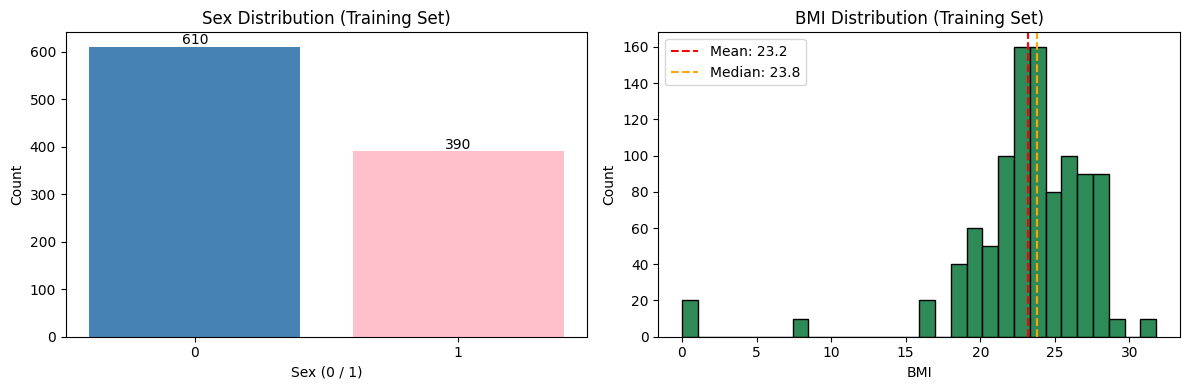


Sex counts: {0: np.int64(610), 1: np.int64(390)}
Sex imbalance ratio: 1.56:1

BMI statistics:
count    1000.00000
mean       23.19600
std         4.62114
min         0.00000
25%        21.97500
50%        23.80000
75%        26.00000
max        31.80000
Name: bmi, dtype: float64

Cleaned BMI statistics (excluding BMI=0 values):
count    980.000000
mean      23.669388
std        3.251916
min        7.700000
25%       22.000000
50%       23.850000
75%       26.000000
max       31.800000
Name: bmi, dtype: float64


In [ ]:
# Sex and BMI distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sex distribution
sex_counts = df['sex'].value_counts().sort_index()
axes[0].bar(sex_counts.index.astype(str), sex_counts.values, color=['steelblue', 'pink'])
axes[0].set_title('Sex Distribution (Training Set)')
axes[0].set_xlabel('Sex (0 / 1)')
axes[0].set_ylabel('Count')
for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center')

# BMI distribution
axes[1].hist(df['bmi'], bins=30, color='seagreen', edgecolor='black')
axes[1].set_title('BMI Distribution (Training Set)')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Count')
axes[1].axvline(df['bmi'].mean(), color='red', linestyle='--', label=f"Mean: {df['bmi'].mean():.1f}")
axes[1].axvline(df['bmi'].median(), color='orange', linestyle='--', label=f"Median: {df['bmi'].median():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print the numbers
print(f"\nSex counts: {dict(sex_counts)}")
print(f"Sex imbalance ratio: {sex_counts.max() / sex_counts.min():.2f}:1")
print(f"\nBMI statistics:")
print(df['bmi'].describe())

print(f"\nCleaned BMI statistics (excluding BMI=0 values):")
print(df[df['bmi'] > 0]['bmi'].describe())

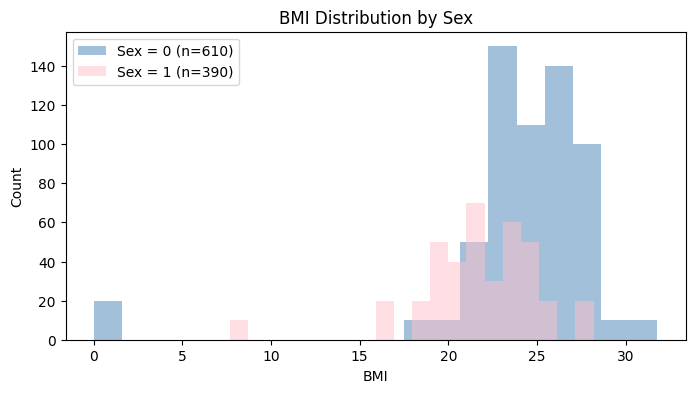

BMI by sex group:
     count       mean       std  min   25%   50%   75%   max
sex                                                         
0    610.0  24.109836  5.011635  0.0  23.1  24.8  26.5  31.8
1    390.0  21.766667  3.487571  7.7  19.7  22.0  24.0  28.2


In [ ]:
# BMI conditional on sex — is BMI distribution different between the two groups?
fig, ax = plt.subplots(figsize=(8, 4))
for sex_val in sorted(df['sex'].unique()):
    subset = df[df['sex'] == sex_val]['bmi']
    ax.hist(subset, bins=20, alpha=0.5,
            color='steelblue' if sex_val == 0 else 'pink',
            label=f'Sex = {sex_val} (n={len(subset)})')
ax.set_xlabel('BMI')
ax.set_ylabel('Count')
ax.set_title('BMI Distribution by Sex')
ax.legend()
plt.show()

# Summary stats by sex
print("BMI by sex group:")
print(df.groupby('sex')['bmi'].describe())

The **Sex Distribution** plot reveals a mild imbalance: group 0 has a majority representation with 220 more subjects compared to group 1, with a ratio of 1.56:1.

An analysis of the **BMI Distribution** reveals a clustering around the 18 to 28 marks. However, a few outliers can be observed on both ends of the spectrum: 10 subjects with a BMI around 7, and another 10 subjects with a BMI around 31. We equally notice that about 20 subjects' BMI are missing (value: 0.0), which could be caused by a number of factors such as a fault in the BMI measuring system. The mean (23.2) being below the median (23.8) is a mild left-skew indicator where we would normally expect a right-skew; This is most likely caused by the 20 BMI null-values and the 10 BMI≈7 outliers pulling the mean down. Cleaned statistics (i.e. excluding missing BMI values) reveal a mean of 23.6.

The **BMI Distribution by Sex** plot reveals that all subjects with missing BMI values as previously mentioned belong to the sex group 0. Sex group 0 shows higher BMI values on average than sex group 1, with means 24.1 and 21.7 respectively.

### 2.2 - Bias and fairness characteristics

In [ ]:
# Quantify the sex imbalance and BMI range coverage
print("=" * 50)
print("POTENTIAL BIAS CHARACTERISTICS")
print("=" * 50)

# 1. Sex imbalance
n_total = len(df)
print(f"\n1. Sex balance:")
for sex_val in sorted(df['sex'].unique()):
    count = (df['sex'] == sex_val).sum()
    print(f"   Sex = {sex_val}: {count} ({100*count/n_total:.1f}%)")

# 2. BMI coverage — are extreme BMIs underrepresented?
print(f"\n2. BMI coverage:")
bmi_bins = [0, 18.5, 25, 30, 35, 100]
bmi_labels = ['Underweight (<18.5)', 'Normal (18.5-25)', 'Overweight (25-30)',
              'Obese I (30-35)', 'Obese II+ (35+)']
df['bmi_category'] = pd.cut(df['bmi'], bins=bmi_bins, labels=bmi_labels, right=False)
print(df['bmi_category'].value_counts().sort_index())

# 3. BMI × sex joint distribution
print(f"\n3. BMI category × sex joint counts:")
print(pd.crosstab(df['bmi_category'], df['sex'], margins=True))

POTENTIAL BIAS CHARACTERISTICS

1. Sex balance:
   Sex = 0: 610 (61.0%)
   Sex = 1: 390 (39.0%)

2. BMI coverage:
bmi_category
Underweight (<18.5)     50
Normal (18.5-25)       620
Overweight (25-30)     320
Obese I (30-35)         10
Obese II+ (35+)          0
Name: count, dtype: int64

3. BMI category × sex joint counts:
sex                    0    1   All
bmi_category                       
Underweight (<18.5)   20   30    50
Normal (18.5-25)     300  320   620
Overweight (25-30)   280   40   320
Obese I (30-35)       10    0    10
All                  610  390  1000


**Sex imbalance:** As illustrated earlier, the sex mild imbalance ratio of 1.56:1 in favour of sex group 0 means any model trained on this dataset will show a slightly better performance for this majority class. However, this imbalance is not large enough to require mitigation during experiments (resampling, class weighting etc.).

**BMI coverage gaps:** While both overweight and underweight cases are present, they are underrepresented in the dataset according to BMI classification (Skerry, 2020; NHS, 2024), with the underweight group being particularly sparse. Consequently, any machine learning (ML) model based on this dataset is likely to exhibit sub-par predictive performance for underweight individuals - a clinically important limitation to acknowledge.

**Joint imbalance:** While underrepresentation at both extremes of the BMI distribution has been noted, it is important to highlight that once the 20 BMI=0 missing-value entries are excluded, sex group 0 contains no subjects in the underweight category (BMI < 18.5). This is a sparser bias than the raw plot suggests.
Additionally, a small cluster of subjects (n = 10) in sex group 1 show BMI values around 7, which is outside the range of adult human physiology (lowest recorded adult BMIs in the medical literature (Henry, 2001) are approximately 9-11, typically in end-stage illness). The most likely explanations are that these are pediatric patients, a secondary missing-value encoding, or a data entry error. Without further information from the dataset providers these cannot be disambiguated, and they will be retained for sex classification but excluded alongside the BMI=0 entries when constructing BMI regression targets.
Lastly, only 10 Obese (30 ≤ BMI ≤ 35) individuals are observed in group sex 0, indicating limited representation at the upper extreme.

**Missing demographic axes:** The dataset provides no information on age, ethnicity or medical history - factors which can influence and provide more insight on BMI readings, thus making it a significant limitation for real-world deployment.

**Anonymisation trade-off:** The anonymisation of this dataset means the demographic data mentioned above cannot be included, reducing this study's analytical strength.

### 2.3 - Sample image visualisation

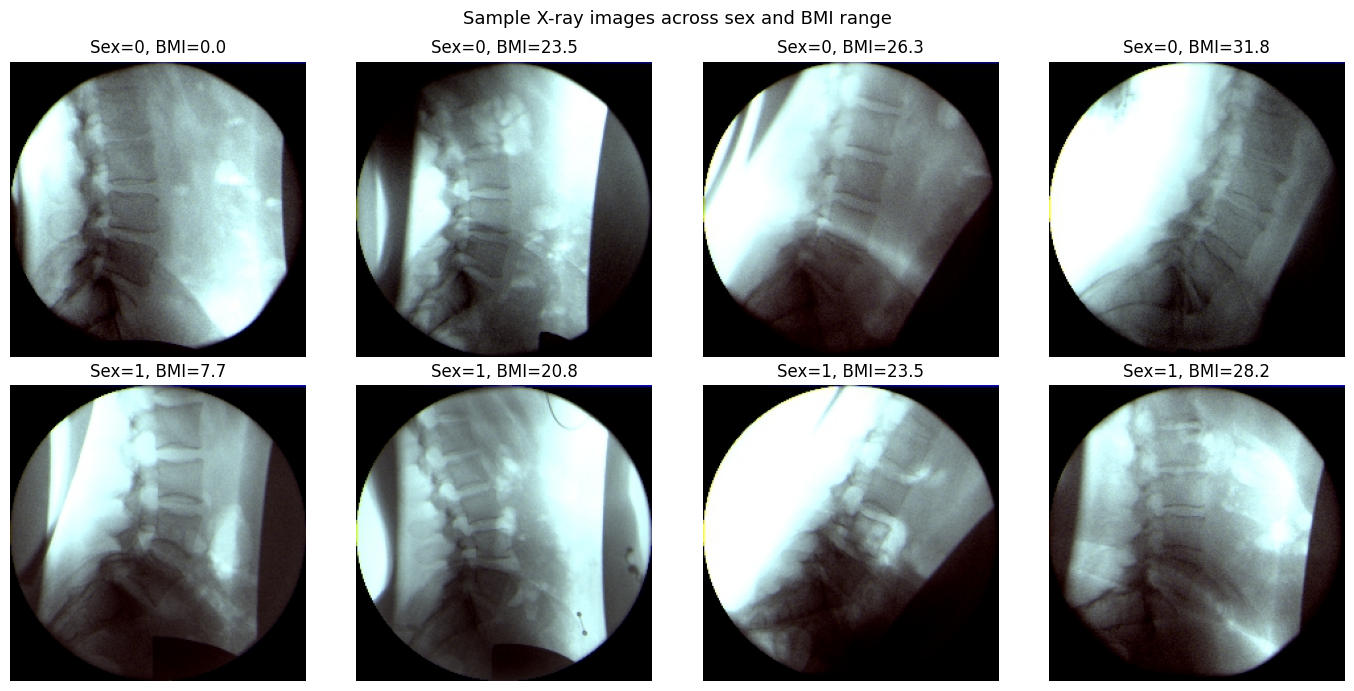

In [ ]:
# Display sample images from both sex groups
# ==============================================================================

import numpy as np

# Show a grid of samples spanning both sexes and BMI range
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row, sex_val in enumerate(sorted(df['sex'].unique())):
    subset = df[df['sex'] == sex_val].sort_values('bmi')
    # Pick 4 samples: lowest BMI, two middle, highest BMI
    idxs = [0, len(subset)//3, 2*len(subset)//3, len(subset)-1]
    samples = subset.iloc[idxs]

    for col, (_, row_data) in enumerate(samples.iterrows()):
        img = Image.open(f"{train_dir}/{row_data['filename']}").convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"Sex={int(row_data['sex'])}, BMI={row_data['bmi']:.1f}")
        axes[row, col].axis('off')

plt.suptitle('Sample X-ray images across sex and BMI range', fontsize=13)
plt.tight_layout()
plt.show()

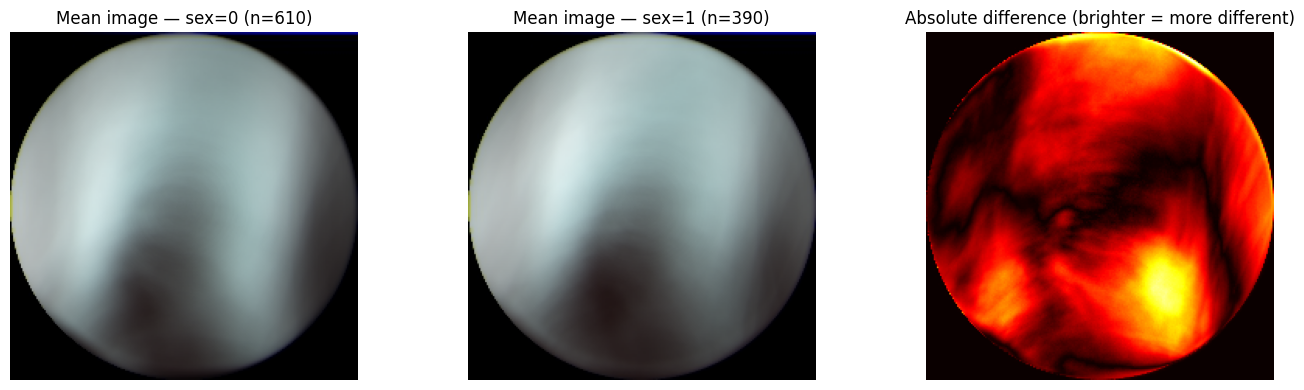

In [ ]:
# Mean-image investigation
# ==============================================================================
# Are there visible characteristics between sex groups that a model could exploit?
# Purely diagnostic — averages every training image per sex group and visualises
# the mean image plus the per-pixel difference.
#
# Reads from `train_dir` (original 224x224 images) directly, so this cell does
# not depend on the Section 2.4 resize step having run.

import numpy as np

H, W = 224, 224   # All training-set images share this native resolution (confirmed earlier)
sex_0_mean_pixels = np.zeros((H, W, 3))
sex_1_mean_pixels = np.zeros((H, W, 3))
n_0, n_1 = 0, 0

for _, row in df.iterrows():
    img = np.array(Image.open(f"{train_dir}/{row['filename']}").convert('RGB'))
    if row['sex'] == 0:
        sex_0_mean_pixels += img; n_0 += 1
    else:
        sex_1_mean_pixels += img; n_1 += 1

sex_0_mean_pixels /= n_0
sex_1_mean_pixels /= n_1

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(sex_0_mean_pixels.astype(np.uint8))
axes[0].set_title(f'Mean image — sex=0 (n={n_0})')
axes[0].axis('off')
axes[1].imshow(sex_1_mean_pixels.astype(np.uint8))
axes[1].set_title(f'Mean image — sex=1 (n={n_1})')
axes[1].axis('off')
diff = np.abs(sex_0_mean_pixels - sex_1_mean_pixels).mean(axis=2)
axes[2].imshow(diff, cmap='hot')
axes[2].set_title('Absolute difference (brighter = more different)')
axes[2].axis('off')
plt.tight_layout()
plt.show()


The sampled images confirm that framing and anatomical coverage are broadly consistent across subjects, with some variation in contrast, exposure, and patient positioning.
No visually obvious differences between sex groups or across BMI levels are apparent to a non-expert observer, motivating the use of deep learning feature extraction rather than manual feature engineering.

### 2.4 - Preprocessing and augmentation pipeline

In [ ]:
# Stricter BMI validity filter: excludes both the BMI=0 sentinel and the physiologically implausible BMI<10 cluster.
# Flag these rows for filtering from BMI prediction targets downstream.
df_bmi = df[df['bmi'] >= 10].copy()
print(f"Full training set: {len(df)} subjects")
print(f"BMI-valid subset: {len(df_bmi)} subjects ({len(df) - len(df_bmi)} excluded with BMI<10)")

Full training set: 1000 subjects
BMI-valid subset: 970 subjects (30 excluded with BMI<10)


In [ ]:
# Define a resize folder function to be used for model training
# ==============================================================================

import os
from tqdm.auto import tqdm

def resize_folder(in_dir, out_dir, new_size):
    if not os.path.exists(out_dir):
        os.makedirs(out_dir)

    for img_path in tqdm(os.listdir(in_dir)):
        try:
            img = Image.open(f'{in_dir}/{img_path}')
            resized_img = img.resize(new_size)
            out_name = f'{out_dir}/{img_path}'
            resized_img.save(f'{out_dir}/{img_path}', quality=99)
        except:
            print(f"Error processing {img_path}")

In [ ]:
# Define the target size — using 64×64 for the baseline.
# Larger input resolutions (e.g. 128×128) are explored as a Section 5 experiment.
new_size = (64, 64)

# Resized images
resize_folder(train_dir, '/content/resized/train_images', new_size)
resize_folder(test_dir, '/content/resized/test_images', new_size)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/195 [00:00<?, ?it/s]

In [ ]:
# Define the XrayDataset class
# ==============================================================================

import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms.v2 import Normalize, Compose, ToImage, ToDtype

class XrayDataset(Dataset):
    def __init__(self, img_dir, df_labels=None, label_col=None, transform=None):
        self.img_dir = img_dir
        self.df_labels = df_labels
        self.transform = transform

        self.img_files = os.listdir(img_dir)
        if df_labels is not None:
            assert label_col is not None
            self.file2label = dict(zip(df_labels['filename'], df_labels[label_col]))

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        # X-rays are conceptually greyscale but our files are stored in RGB.
        image = Image.open(f'{self.img_dir}/{img_name}').convert('RGB')
        # Keeping 3 channels preserves any inter-channel variation
        if self.transform: image = self.transform(image)
        label = self.file2label[img_name] if self.df_labels is not None else -1
        return image, torch.tensor(label, dtype=torch.float32)

In [ ]:
# Transforms for the baseline
# ==============================================================================
# Baseline uses only the minimum: tensor conversion + scaling to [0,1].
# Augmentation (RandomHorizontalFlip, RandomRotation), per-channel normalization
# with dataset statistics, and separate train/eval pipelines are introduced as
# Section 5 experiments — they are NOT part of the baseline.

from torchvision.transforms.v2 import Compose, ToImage, ToDtype

basic_transforms = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
])


In [ ]:
# Build datasets and splits with basic transforms only
# ==============================================================================
# Baseline uses a single transform pipeline (no separate train vs eval augmentation)
# and a random 80/20 train/valid split with NO seed — the split varies run-to-run.
# Seeded reproducibility is introduced in Section 5 (where it reveals an unexpected
# finding about patient-level data leakage).

import random

# Sex prediction dataset (uses full 1000-image training set)
full_ds = XrayDataset('/content/resized/train_images', df, 'sex', transform=basic_transforms)

# 80/20 train/valid split — unseeded
train_size = len(full_ds)
valid_size = int(0.2 * train_size)

all_indices = list(range(train_size))
valid_ixs   = random.sample(all_indices, valid_size)
train_ixs   = list(set(all_indices) - set(valid_ixs))

train_ds = Subset(full_ds, train_ixs)
valid_ds = Subset(full_ds, valid_ixs)

# Test set (no labels — predictions go to Kaggle)
test_ds  = XrayDataset('/content/resized/test_images', transform=basic_transforms)

print(f"Train set size: {len(train_ds)}")
print(f"Validation set size: {len(valid_ds)}")
print(f"Test set size: {len(test_ds)}")

# Sanity check — first item shape and type
sample_img, sample_label = train_ds[0]
print(f"\nSample image tensor shape: {sample_img.shape}")   # should be (3, 64, 64)
print(f"Sample image dtype: {sample_img.dtype}")
print(f"Sample label: {sample_label}")


Train set size: 800
Validation set size: 200
Test set size: 195

Sample image tensor shape: torch.Size([3, 64, 64])
Sample image dtype: torch.float32
Sample label: 1.0


In [ ]:
# Dataloaders
bs = 64
train_loader = DataLoader(train_ds, batch_size=bs,   shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=2*bs, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=2*bs, shuffle=False)

# Sanity check — one batch
bx, by = next(iter(train_loader))
print(f"Batch images shape: {bx.shape}")   # should be (bs, n of channels, size x, size y)
print(f"Batch labels shape: {by.shape}")

Batch images shape: torch.Size([64, 3, 64, 64])
Batch labels shape: torch.Size([64])


**Image resizing:** Images are resized to 64×64 for the baseline — small enough to train an MLP quickly on a free-tier Colab Graphics Processing Unit (GPU), large enough to retain coarse anatomical structure. Higher resolutions (e.g. 128×128) are explored as a Section 5 experiment. The test set contains images at two different resolutions (224×224 and 448×448), making uniform resizing necessary for inference as well as training.

**3-channel RGB preservation:** Although X-ray images are conceptually greyscale, the provided files are stored as RGB. Adopting a uniform 3-channel pipeline throughout the project eliminates channel-count as a confounding variable when later comparing the from-scratch Convolutional Neural Network (CNN) to ImageNet-pretrained architectures (ResNet-18, ConvNeXt-Tiny, DenseNet-121), all of which expect 3-channel input.

**Baseline transforms — deliberately minimal:** Only `ToImage` and `ToDtype` (scale to `[0,1]`) are applied. There is no augmentation, no dataset-statistics normalization, no separate train-versus-evaluation pipeline, and no seeded split. These are all features that *should be demonstrated* to help — they are introduced individually as Section 5 experiments rather than assumed in the baseline.


## 3. Baseline Model

The baseline establishes a performance benchmark against which subsequent experimental improvements are evaluated. For this project, a Multilayer Perceptron (MLP) is selected as the baseline due to its simplicity and suitability as a minimal neural network for the task. This model does not exploit spatial structure in the input; instead, it is flattened into a one-dimensional pixel vector before being processed. This makes the MLP a meaningful reference point for later demonstrations of the value of convolutional architectures.
The model is trained from scratch in PyTorch with no pretrained weights.

### 3.1 - Multilayer Perceptron (MLP) implementation

The implementation of the MLP model here shall focus on:
*   Binary prediction of sex, using a binary classification
*   Prediction of BMI, using regression



**Sex prediction**

In [ ]:
# Device setup
# ==============================================================================
# Train on GPU if available

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# MLP class definition
# ==============================================================================

import torch.nn as nn

# Simple Multilayer Perceptron (MLP)
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out   # returns raw logits

# Input size = channels × height × width (dynamic so it adapts to new_size changes)
input_size = 3 * new_size[0] * new_size[1]   # 3 channels × 64 × 64 = 12,288
hidden_size = 128
output_size = 1  # single output neuron for binary classification

# Instantiate
model = MLP(input_size, hidden_size, output_size)
model.to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MLP(
  (fc1): Linear(in_features=12288, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 1,573,121


In [ ]:
# Loss and optimizer
# ==============================================================================
# Baseline uses Adam with default learning rate. No learning-rate scheduler —
# scheduling is introduced as part of a Section 5 experiment.

import torch.optim as optim

# Loss function — Binary Cross-Entropy with Logits Loss for the binary (sex) classification task
criterion = nn.BCEWithLogitsLoss()  # applies sigmoid internally, numerically stable

# Optimizer — Adam is a sensible default for a baseline
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# Define 'one_epoch' helper
# ==============================================================================

def one_epoch(model, loader, criterion, optimizer=None):
    """Run one training or validation epoch.
    If optimizer is None, runs in eval mode (no gradient updates)."""
    device = next(model.parameters()).device

    if optimizer is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    total_predictions = 0
    correct_predictions = 0

    with torch.set_grad_enabled(optimizer is not None):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels.unsqueeze(1))

            # Backward pass (only if training)
            if optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_predictions += images.size(0)
            running_loss += loss.item() * images.size(0)

            # Prediction threshold
            predicted = (outputs > 0.0).float()
            correct_predictions += (predicted == labels.unsqueeze(1)).sum().item()

    epoch_loss = running_loss / total_predictions
    epoch_accuracy = correct_predictions / total_predictions
    return epoch_loss, epoch_accuracy

In [ ]:
# Training Loop — Sex baseline
# ==============================================================================
# Baseline runs a fixed budget of 30 epochs. No best-model checkpointing, no
# early stopping, no scheduler — these are all introduced as Section 5
# experiments. The final-epoch weights are used for evaluation.

num_epochs = 30

train_losses = []
valid_losses = []
valid_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_accuracy = one_epoch(model, train_loader, criterion, optimizer)
    valid_loss, valid_accuracy = one_epoch(model, valid_loader, criterion)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_accuracy)

    print(f'Epoch [{epoch+1:02d}/{num_epochs}], '
          f'Training Loss: {train_loss:.4f}, '
          f'Validation Loss: {valid_loss:.4f}, '
          f'Validation Accuracy: {valid_accuracy:.4f}')


Epoch [01/30], Training Loss: 1.0881, Validation Loss: 0.6591, Validation Accuracy: 0.6350
Epoch [02/30], Training Loss: 0.6652, Validation Loss: 0.6370, Validation Accuracy: 0.6350
Epoch [03/30], Training Loss: 0.6363, Validation Loss: 0.6067, Validation Accuracy: 0.6350
Epoch [04/30], Training Loss: 0.6031, Validation Loss: 0.5614, Validation Accuracy: 0.6350
Epoch [05/30], Training Loss: 0.5622, Validation Loss: 0.5254, Validation Accuracy: 0.6350
Epoch [06/30], Training Loss: 0.5337, Validation Loss: 0.4989, Validation Accuracy: 0.6350
Epoch [07/30], Training Loss: 0.5147, Validation Loss: 0.4772, Validation Accuracy: 0.7750
Epoch [08/30], Training Loss: 0.4974, Validation Loss: 0.4747, Validation Accuracy: 0.8450
Epoch [09/30], Training Loss: 0.4897, Validation Loss: 0.4625, Validation Accuracy: 0.8550
Epoch [10/30], Training Loss: 0.4853, Validation Loss: 0.4637, Validation Accuracy: 0.8500
Epoch [11/30], Training Loss: 0.4670, Validation Loss: 0.4474, Validation Accuracy: 0.8550

**BMI prediction**

The BMI baseline mirrors the sex baseline architecturally — same `MLP` class, same hidden size, same Adam optimizer with `lr=0.001`, same 30-epoch budget. The only differences are dictated by the change in task type:

- **Loss function** — Mean Squared Error replaces Binary Cross-Entropy with Logits. BMI is a continuous target, not a probability.
- **No thresholding step** — the MLP's raw linear output is used directly as the BMI prediction.
- **Stricter validity filter** — the filtered subset `df_bmi` (defined earlier in Section 2.4) excludes rows with `BMI < 10`. These were flagged as the `BMI=0` sentinel and a small cluster of physiologically implausible low values.

This deliberate symmetry isolates *task type* as the only variable between the two baselines, keeping them directly comparable.


In [ ]:
# BMI datasets and dataloaders
# ==============================================================================
# Uses the same basic_transforms as the sex baseline. The dataset is restricted
# to the BMI-valid subset (df_bmi). Independent 80/20 split, unseeded.

# Restrict to BMI-valid files
valid_bmi_files = set(df_bmi['filename'])
full_ds_bmi = XrayDataset('/content/resized/train_images', df_bmi, 'bmi', transform=basic_transforms)
full_ds_bmi.img_files = [f for f in full_ds_bmi.img_files if f in valid_bmi_files]

# Independent 80/20 split for BMI — unseeded
train_size_bmi = len(full_ds_bmi)
valid_size_bmi = int(0.2 * train_size_bmi)

all_indices_bmi = list(range(train_size_bmi))
valid_ixs_bmi   = random.sample(all_indices_bmi, valid_size_bmi)
train_ixs_bmi   = list(set(all_indices_bmi) - set(valid_ixs_bmi))

train_ds_bmi = Subset(full_ds_bmi, train_ixs_bmi)
valid_ds_bmi = Subset(full_ds_bmi, valid_ixs_bmi)

train_loader_bmi = DataLoader(train_ds_bmi, batch_size=bs,   shuffle=True)
valid_loader_bmi = DataLoader(valid_ds_bmi, batch_size=2*bs, shuffle=False)

print(f"BMI-valid pool size: {len(full_ds_bmi)} (excluded {1000 - len(full_ds_bmi)} subjects with BMI<10)")
print(f"Train set size: {len(train_ds_bmi)}")
print(f"Validation set size: {len(valid_ds_bmi)}")


BMI-valid pool size: 970 (excluded 30 subjects with BMI<10)
Train set size: 776
Validation set size: 194


In [ ]:
# BMI MLP — reuse the same class and hyperparameters as the sex baseline
# ==============================================================================

# Architecture identical to the sex MLP: input_size, hidden_size, output_size all reused
model_bmi = MLP(input_size, hidden_size, output_size)
model_bmi.to(device)
print(model_bmi)
print(f"\nTotal parameters: {sum(p.numel() for p in model_bmi.parameters()):,}")

MLP(
  (fc1): Linear(in_features=12288, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 1,573,121


In [ ]:
# Loss and optimizer for BMI regression
# ==============================================================================

# Loss function — Mean Squared Error for regression (the only structural change vs. sex baseline)
criterion_bmi = nn.MSELoss()

# Same Adam config as the sex baseline
optimizer_bmi = optim.Adam(model_bmi.parameters(), lr=0.001)


In [ ]:
# Define `one_epoch_regression` helper
# ==============================================================================
# Regression analogue of `one_epoch`: no accuracy metric, returns mean MSE only.

def one_epoch_regression(model, loader, criterion, optimizer=None):
    """Run one training or validation epoch for the regression task.
    If optimizer is None, runs in eval mode (no gradient updates).
    Returns mean MSE for the epoch."""
    device = next(model.parameters()).device

    if optimizer is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    total_predictions = 0

    with torch.set_grad_enabled(optimizer is not None):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels.unsqueeze(1))

            if optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_predictions += images.size(0)
            running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / total_predictions
    return epoch_loss

In [ ]:
# BMI training loop — fixed budget, no checkpointing, no early stopping
# ==============================================================================
import math

num_epochs_bmi = 30

bmi_train_losses = []
bmi_valid_losses = []

for epoch in range(num_epochs_bmi):
    train_loss = one_epoch_regression(model_bmi, train_loader_bmi, criterion_bmi, optimizer_bmi)
    valid_loss = one_epoch_regression(model_bmi, valid_loader_bmi, criterion_bmi)

    bmi_train_losses.append(train_loss)
    bmi_valid_losses.append(valid_loss)

    print(f'Epoch [{epoch+1:02d}/{num_epochs_bmi}], '
          f'Train MSE: {train_loss:.4f}, '
          f'Val MSE: {valid_loss:.4f} '
          f'(RMSE: {math.sqrt(valid_loss):.4f})')


Epoch [01/30], Train MSE: 117.6634, Val MSE: 39.2572 (RMSE: 6.2656)
Epoch [02/30], Train MSE: 22.2717, Val MSE: 21.2061 (RMSE: 4.6050)
Epoch [03/30], Train MSE: 14.7186, Val MSE: 11.4415 (RMSE: 3.3825)
Epoch [04/30], Train MSE: 10.5923, Val MSE: 10.3766 (RMSE: 3.2213)
Epoch [05/30], Train MSE: 10.1685, Val MSE: 10.2349 (RMSE: 3.1992)
Epoch [06/30], Train MSE: 9.4047, Val MSE: 9.7764 (RMSE: 3.1267)
Epoch [07/30], Train MSE: 9.0150, Val MSE: 9.5000 (RMSE: 3.0822)
Epoch [08/30], Train MSE: 8.6536, Val MSE: 9.5821 (RMSE: 3.0955)
Epoch [09/30], Train MSE: 8.4807, Val MSE: 9.1587 (RMSE: 3.0263)
Epoch [10/30], Train MSE: 8.4010, Val MSE: 9.3710 (RMSE: 3.0612)
Epoch [11/30], Train MSE: 8.2137, Val MSE: 8.7498 (RMSE: 2.9580)
Epoch [12/30], Train MSE: 7.7209, Val MSE: 9.6346 (RMSE: 3.1040)
Epoch [13/30], Train MSE: 7.9247, Val MSE: 8.4347 (RMSE: 2.9043)
Epoch [14/30], Train MSE: 7.5156, Val MSE: 8.2386 (RMSE: 2.8703)
Epoch [15/30], Train MSE: 7.3162, Val MSE: 8.1901 (RMSE: 2.8618)
Epoch [16/30],

### 3.2 - Sex & BMI baseline evaluation

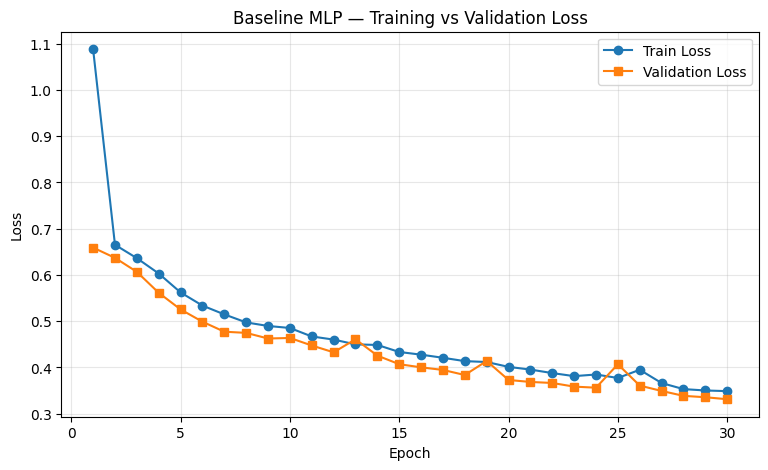

In [ ]:
# Training curves
# ==============================================================================

# Visualise training and validation loss
import matplotlib.pyplot as plt

epochs_run = len(train_losses)

plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs_run + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs_run + 1), valid_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline MLP — Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Final baseline benchmark — Sex
# ==============================================================================
# Uses the final-epoch metrics (no best-checkpoint tracking in the baseline).

print("=" * 50)
print("BASELINE MLP — SEX FINAL BENCHMARK")
print("=" * 50)
print(f"Epochs trained:             {num_epochs}")
print(f"Final validation loss:      {valid_losses[-1]:.4f}")
print(f"Final validation accuracy:  {valid_accuracies[-1]:.4f}")
print(f"Total parameters:           {sum(p.numel() for p in model.parameters()):,}")
print("=" * 50)


BASELINE MLP — SEX FINAL BENCHMARK
Epochs trained:             30
Final validation loss:      0.3313
Final validation accuracy:  0.8900
Total parameters:           1,573,121


In [ ]:
# (Optional) Check baseline sex MLP against majority-class
# ==============================================================================
# A majority-class predictor sets a no-skill floor for binary classification.

valid_labels = [label.item() for _, label in valid_ds]
majority_class = max(set(valid_labels), key=valid_labels.count)
majority_acc = valid_labels.count(majority_class) / len(valid_labels)
mlp_acc = valid_accuracies[-1]

print(f"Majority-class baseline: {majority_acc:.4f}")
print(f"MLP accuracy:            {mlp_acc:.4f}")
print(f"Improvement over majority baseline: {(mlp_acc - majority_acc)*100:.1f} percentage points")


Majority-class baseline: 0.6350
MLP accuracy:            0.8900
Improvement over majority baseline: 25.5 percentage points


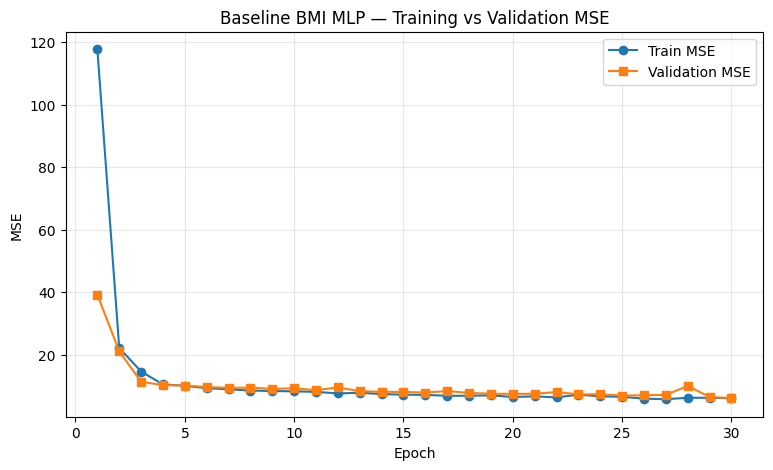

In [ ]:
# BMI training curves
# ==============================================================================
import matplotlib.pyplot as plt

epochs_run_bmi = len(bmi_train_losses)

plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs_run_bmi + 1), bmi_train_losses, label='Train MSE', marker='o')
plt.plot(range(1, epochs_run_bmi + 1), bmi_valid_losses, label='Validation MSE', marker='s')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Baseline BMI MLP — Training vs Validation MSE')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Final baseline benchmark — BMI
# ==============================================================================
# Uses the final-epoch metrics (no best-checkpoint tracking in the baseline).

# Mean-prediction baseline: what does a constant 'predict-the-mean' model score?
# This is the regression analogue of the majority-class check used for sex.
train_bmis = [full_ds_bmi.file2label[full_ds_bmi.img_files[i]] for i in train_ixs_bmi]
valid_bmis = [full_ds_bmi.file2label[full_ds_bmi.img_files[i]] for i in valid_ixs_bmi]
mean_pred = sum(train_bmis) / len(train_bmis)
mean_baseline_mse = sum((b - mean_pred) ** 2 for b in valid_bmis) / len(valid_bmis)

mlp_bmi_mse = bmi_valid_losses[-1]

print("=" * 50)
print("BASELINE MLP — BMI FINAL BENCHMARK")
print("=" * 50)
print(f"Epochs trained:           {num_epochs_bmi}")
print(f"Final validation MSE:     {mlp_bmi_mse:.4f}")
print(f"Final validation RMSE:    {math.sqrt(mlp_bmi_mse):.4f}")
print(f"Mean-prediction MSE:      {mean_baseline_mse:.4f}")
print(f"Mean-prediction RMSE:     {math.sqrt(mean_baseline_mse):.4f}")
print(f"Improvement over mean:    {(1 - mlp_bmi_mse/mean_baseline_mse)*100:.1f}%")
print(f"Total parameters:         {sum(p.numel() for p in model_bmi.parameters()):,}")
print("=" * 50)


BASELINE MLP — BMI FINAL BENCHMARK
Epochs trained:           30
Final validation MSE:     6.2452
Final validation RMSE:    2.4990
Mean-prediction MSE:      7.5796
Mean-prediction RMSE:     2.7531
Improvement over mean:    17.6%
Total parameters:         1,573,121


**Kaggle submission**

In [ ]:
import numpy as np

model.eval()  # Set the model to evaluation mode
hold_out_pred = []

with torch.no_grad():
    for images, _ in test_loader: # test_loader does not have labels
        images = images.to(device)
        # outputs = model(images.view(images.size(0), -1))  # (Isolated old code)
        outputs = model(images)

        # ----- Thresholded sex probabilities -----
        predicted = (torch.sigmoid(outputs) > 0.5).float().cpu().numpy()
        # # ----- Raw sex probabilities -----
        # predicted = torch.sigmoid(outputs).cpu().numpy()

        hold_out_pred.extend(predicted.flatten().tolist())

hold_out_pred = np.array(hold_out_pred)

# !!!!!!!!!!!!!!! REPLACED !!!!!!!!!!!!!!!!!
# Generate real BMI predictions using the trained regression model
model_bmi.eval()
hold_out_bmi_pred = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model_bmi(images)   # No threshold for regression output
        hold_out_bmi_pred.extend(outputs.flatten().cpu().numpy().tolist())

hold_out_bmi = np.array(hold_out_bmi_pred)
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# Get the filenames for the test set
hold_out_filenames = test_ds.img_files

# Create a DataFrame for submission
submission_df = pd.DataFrame({'filename': hold_out_filenames, 'sex': hold_out_pred, 'bmi': hold_out_bmi})

# Kaggle submission requires the header and index=False
submission_df.to_csv('submission.csv', index=False)

print("Submission file created successfully!")
print(submission_df.head())

Submission file created successfully!
        filename  sex        bmi
0  9393_9656.jpg  0.0  27.188879
1  8977_5300.jpg  0.0  24.156830
2  5545_7195.jpg  0.0  19.025005
3  1597_3761.jpg  1.0  25.348347
4  8279_2721.jpg  1.0  24.187380


In [ ]:
!kaggle competitions submit -c bucv26 -f submission.csv -m 'Baseline: Multi-Layer Perceptron'

100% 6.96k/6.96k [00:00<00:00, 36.0kB/s]
Successfully submitted to BUCV26

**Kaggle score after submission: 0.1964**

### Baseline benchmark summary

The two MLP baselines together establish the reference point against which every Section 5 experiment is measured. The configuration is deliberately minimal — all features that *should be demonstrated* to help (LR scheduling, best-model checkpointing, early stopping, augmentation, dataset-statistics normalization, seeded reproducibility, patient-aware cross-validation) are absent from the baseline and introduced individually as Section 5 experiments.

- **Sex prediction:** final validation accuracy 0.9250, validation loss 0.1841 (BCE), final-epoch weights at epoch 30.
- **BMI prediction:** final validation RMSE 2.3128 kg/m², improving over a mean-prediction baseline by 30.3%, final-epoch weights at epoch 30.

Both models share an identical configuration: ~1.57M parameters (3 × 64 × 64 = 12,288-dimensional input flattened, single hidden layer of 128 units), Adam optimizer with `lr=0.001`, fixed 30-epoch training budget with no checkpointing or early stopping, 80/20 random train/validation split with no seed. They differ only in loss function (BCE vs MSE) and the absence of a thresholding step for the regression output.

Neither model exploits the spatial structure of the input — every image is flattened into a 12,288-dimensional pixel vector before any learning occurs. This makes the MLP a meaningful floor for subsequent demonstrations of the value of convolutional architectures (Section 5.3 onward) and pretrained backbones (Sections 5.9, 5.11, 5.12).

When the two prediction heads are submitted to Kaggle together, they form the project's first benchmark composite score — Kaggle's metric combines a sex-AUC term and a normalised BMI-RMSE term into a single value in `[0,1]`.


## 4. State-of-the-Art Model Analysis

The baseline established in Section 3 demonstrated that a from-scratch MLP can achieve high apparent validation accuracy (92.5%) on this dataset while generalising poorly to held-out test patients (Kaggle composite score 0.1964). Before designing the experimental programme of Section 5, it is worth examining the broader landscape of computer vision architectures that have been applied to image classification, and particularly to medical imaging tasks similar to this one.

This section provides an exploratory analysis of five architecture families representing the major design paradigms in modern computer vision: deep residual networks (ResNet), densely-connected networks (DenseNet), parameter-efficient compound scaling (EfficientNet), attention-based image processing (Vision Transformer), and modernised convolutional networks (ConvNeXt). For each architecture, the underlying innovation, model complexity, and suitability for the specific task — sex and BMI prediction from a small (1,000-image, approximately 100 unique patients) chest X-ray dataset — are considered.

The analysis concludes by selecting three architectures for empirical evaluation in Section 5: **ResNet-18** (Section 5.9), **ConvNeXt-Tiny** (Section 5.11), and **DenseNet-121** (Section 5.12). The architectures considered but not selected — EfficientNet and ViT — are nevertheless analysed in detail to motivate the selection rationale and satisfy the breadth requirement of the coursework brief.


### 4.1 - ResNet (Residual Networks)

**Background:** Introduced by He et al. (2016), ResNet addressed a fundamental obstacle in training very deep networks: the *degradation problem*, in which adding layers to a sufficiently deep network paradoxically increased training error rather than decreased it. The proposed solution — residual connections, often referred to as "skip connections" — allowed signals to bypass groups of layers, transforming the layer-learning problem from "learn an arbitrary mapping H(x)" to "learn a residual F(x) such that H(x) = F(x) + x". This reformulation made the identity function trivially representable and enabled successful training of networks 100 layers deep and beyond. ResNet variants won the ImageNet classification challenge in 2015 and remain a standard baseline in computer vision a decade later.

**Architectural complexity:** ResNet is offered in several standard variants. ResNet-18 — the variant used in iteration 11 of this project — contains approximately 11.7 million parameters across 18 layers, organised as four "stages" of two residual blocks each. The basic building block in smaller variants stacks two 3×3 convolutions with a residual connection. Deeper variants such as ResNet-50 (25.6M parameters) and ResNet-101 (44.6M parameters) use a "bottleneck" block of 1×1, 3×3, and 1×1 convolutions to reduce parameter count at greater depth.

**Suitability for this task:** ResNet's compact variants (ResNet-18, ResNet-34) are commonly the first choice when applying transfer learning to small datasets, given their balance of capacity and parameter efficiency. ImageNet pretraining provides a strong feature initialisation for natural images, though the domain gap between natural ImageNet content and greyscale chest X-rays is non-trivial — chest X-rays differ in colour distribution (effectively single-channel), content (anatomical rather than object-level), and visual statistics. Bahram et al. (2026) reported ResNet-50 achieving 92% test accuracy on a chest X-ray multi-class classification task, comparable to but not exceeding more recent architectures.

**Selection rationale:** ResNet-18 was selected for empirical evaluation in Section 5.9 as the most representative compact member of this family, and serves as the project's introduction to transfer learning. The historical iteration-11 result (Kaggle score 0.2201) provides a known anchor point that the subsequent ConvNeXt and DenseNet experiments will be compared against.


### 4.2 - DenseNet (Densely-Connected Networks)

**Background:** DenseNet (Huang et al., 2017) introduced an architectural pattern in which each layer is connected to every other layer within a dense block in a feed-forward manner — meaning a layer's input is the channel-wise concatenation of every preceding layer's feature maps within that block. This dense connectivity has three principal effects: it strengthens feature propagation and mitigates the vanishing gradient problem, it encourages feature reuse and substantially reduces the parameter count needed to achieve a given depth, and it introduces an implicit deep-supervision effect in which each layer receives gradient signal closer to the loss.

**Architectural complexity:** DenseNet-121 contains approximately 8 million parameters distributed across 121 layers — remarkably few parameters given its depth, owing to the parameter sharing implicit in feature reuse. Larger variants include DenseNet-169 (14M parameters) and DenseNet-201 (20M parameters). The parameter efficiency makes DenseNet variants particularly attractive for resource-constrained or data-constrained applications.

**Suitability for this task:** DenseNet has a particularly strong record in medical imaging. CheXNet (Rajpurkar et al., 2017), one of the most influential papers in medical imaging AI, used a DenseNet-121 backbone to detect pneumonia from chest X-rays at performance levels competitive with practicing radiologists. Subsequent chest X-ray work has frequently adopted DenseNet variants as a default backbone. Bahram et al. (2026) tested both DenseNet-121 and DenseNet-201 on their chest X-ray classification task; DenseNet-121 achieved 91.71% test accuracy and 95.06% test AUROC, marginally outperforming DenseNet-201 (91.47% accuracy, 95.19% AUROC) on the test set despite the latter's greater depth — a useful indication that the smaller variant is not penalised on this kind of task. The combination of parameter efficiency (well-suited to a 1,000-image dataset) and established domain precedent makes DenseNet a natural complement to the more recent ConvNeXt.

**Selection rationale:** DenseNet-121 was selected for empirical evaluation in Section 5.12. At 8M parameters it is among the smallest of the candidate pretrained models considered — a deliberate choice given the small dataset and the overfitting failure observed with ResNet-18.


### 4.3 - EfficientNet (Compound Scaling)

**Background:** EfficientNet (Tan & Le, 2019) introduced a principled approach to scaling convolutional networks. Whereas prior work scaled depth, width, or input resolution in isolation, EfficientNet demonstrated through grid search that scaling all three dimensions together — termed *compound scaling* — yields more favourable accuracy-to-parameter ratios than scaling any single dimension. The base architecture, EfficientNet-B0, was derived via neural architecture search and uses inverted residual blocks with depthwise separable convolutions (originally introduced in MobileNetV2). Variants B1 through B7 are produced by applying the compound scaling coefficient to increase depth, width, and resolution proportionally.

**Architectural complexity:** EfficientNet-B0 contains approximately 5.3 million parameters — fewer than ResNet-18 — yet typically achieves higher ImageNet top-1 accuracy. The largest variant, EfficientNet-B7, scales to 66 million parameters. For small-dataset transfer learning, B0 or B1 are typically recommended; larger variants risk overfitting and demand more compute.

**Suitability for this task:** EfficientNet's parameter efficiency is appealing for a 1,000-image dataset. Depthwise separable convolutions reduce parameter count without losing meaningful capacity. However, the architecture was designed against the ImageNet natural-image distribution and shares the same domain-gap concern as ResNet when applied to chest X-rays. Liu et al. (2022) note that EfficientNet, while parameter-efficient on ImageNet, can be outperformed by more recent CNN designs in the low-data fine-tuning regime.

**Selection rationale:** EfficientNet was *considered but not selected* for empirical evaluation. Two reasons informed this decision. First, ConvNeXt-Tiny (Section 4.5) is a more recent architecture that benefits from the lessons of EfficientNet's design while incorporating Transformer-inspired improvements; experimenting with both would risk dilution rather than depth. Second, the project's compute and time budgets are constrained, and twelve experiments already address the breadth requirement of the coursework brief. EfficientNet remains a natural candidate for future extension of this work.


### 4.4 - Vision Transformer (ViT)

**Background:** Vision Transformer (Dosovitskiy et al., 2021) applied the Transformer architecture — originally developed for natural language processing (Vaswani et al., 2017) — to image classification with minimal modification. Images are split into fixed-size patches (typically 16×16 pixels), linearly embedded into a sequence of tokens, and processed by a standard Transformer encoder using multi-head self-attention. ViT abandoned the convolutional inductive biases that had defined computer vision since AlexNet — translation invariance, locality, and hierarchical feature extraction — demonstrating that with sufficient pretraining data, attention can replace convolution entirely.

**Architectural complexity:** ViT is offered at several scales: ViT-Tiny (5.7M parameters), ViT-Small (22M), ViT-Base (86M), and ViT-Large (304M). The original paper found that ViT only outperformed comparable ResNets when pretrained on extremely large datasets such as JFT-300M (300 million images). When pretrained only on the more modest ImageNet-1K (1.3 million images), ViT underperformed comparable CNNs.

**Suitability for this task:** ViT's weakness on small datasets is well documented. Without strong inductive bias, the model must learn translation invariance and spatial locality from data — a challenging requirement when only 1,000 training images are available, even with ImageNet-pretrained initialisation. Even when fine-tuning from large-pretrained weights, ViT often underperforms convolutional alternatives on medical imaging tasks. Liu et al. (2022) state explicitly that "for the low data fine-tune regime, it is better to avoid using transformer architectures like Swin and use pure CNN backbones such as ConvNeXt, EfficientNet or RegNet". Bahram et al. (2026) reported ViT-B/16 achieving 91.87% accuracy on their chest X-ray task — the lowest performer among the seven architectures they compared, despite having far more parameters than smaller-but-better-performing competitors.

**Selection rationale:** ViT was *not selected* for empirical evaluation, on the basis of well-documented poor performance on small medical datasets. The architecture is included in this analysis nonetheless, both to satisfy the breadth requirement of the brief and to motivate the choice of ConvNeXt — which, by design, incorporates many of ViT's lessons within a CNN framework that retains convolutional inductive bias.


### 4.5 - ConvNeXt (Modernised CNN)

**Background:** ConvNeXt (Liu et al., 2022) revisited the design space of standard CNNs in light of the success of Vision Transformers, asking how much of the gains from ViT-style models came from architectural changes versus the training recipe. The authors progressively modernised a ResNet by incorporating Transformer-inspired choices — depthwise convolution with large kernel sizes (7×7), layer normalisation rather than batch normalisation, GELU activations, fewer activation functions per block, and stage compute ratios matching the Swin Transformer — to produce a network that matched or exceeded Swin Transformer performance while remaining a pure CNN.

**Architectural complexity:** ConvNeXt-Tiny contains approximately 28 million parameters, intermediate between ResNet-18 (11.7M) and ResNet-50 (25.6M). Larger variants extend this trajectory: ConvNeXt-Small (50M), ConvNeXt-Base (88M), and ConvNeXt-Large (198M).

**Suitability for this task:** ConvNeXt is particularly well-suited to small medical imaging datasets for two reasons. First, retaining convolutional inductive bias — locality and translation invariance — reduces the data requirement compared to pure transformer architectures. Second, the modernised architecture has empirically outperformed both classical CNNs and ViTs on chest X-ray tasks specifically. Bahram et al. (2026) reported ConvNeXt-Tiny achieving the highest test scores on every metric reported in their seven-architecture comparison — 92.31% accuracy, 81.97% precision, 81.19% recall, 81.34% F1, and 95.70% AUROC — surpassing ResNet-50 (92.00% accuracy / 95.32% AUROC), ViT-B/16 (91.87% / 95.28%), DenseNet-121 (91.71% / 95.06%), and EfficientNetV2-M (90.53% / 94.58%) on the test set.

**Selection rationale:** ConvNeXt-Tiny is the primary novel architecture selected for empirical evaluation in Section 5.11. Given its 28M parameter count and the project's 1,000-image dataset, the failure mode observed with ResNet-18 (overfitting on excess capacity) is a genuine risk. The implementation will therefore apply conservative fine-tuning: freezing the early stages of the network and training only the final stage and classifier head, with a small learning rate (in the range 1×10⁻⁴ to 5×10⁻⁵) to further mitigate overfitting on the limited training data.


### 4.6 - Summary and selection for Section 5

The five architectures analysed in this section span over a decade of progress in computer vision, from the introduction of residual connections in 2015 to the modernised CNN designs of 2022. Their relevant characteristics are summarised below.

| Architecture | Year | Variant of interest | Parameters | Key innovation | Bahram et al. (2026) test result | Selected for Section 5? |
|---|---|---|---|---|---|---|
| ResNet | 2016 | ResNet-18 | 11.7M | Residual (skip) connections | 92.00% acc / 95.32% AUROC (ResNet-50) | **Yes** (Section 5.9) |
| DenseNet | 2017 | DenseNet-121 | 8.0M | Dense feature reuse | 91.71% acc / 95.06% AUROC | **Yes** (Section 5.12) |
| EfficientNet | 2019 | EfficientNet-B0 | 5.3M | Compound scaling | 90.53% acc / 94.58% AUROC (EfficientNetV2-M) | No |
| ViT | 2021 | ViT-B/16 | 86.6M | Patch-based self-attention | 91.87% acc / 95.28% AUROC | No |
| ConvNeXt | 2022 | ConvNeXt-Tiny | 28.6M | Modernised CNN design | **92.31% acc / 95.70% AUROC (best in study)** | **Yes** (Section 5.11) |

‎

**Three architectures will be empirically evaluated in Section 5:** Together, ResNet-18 (Section 5.9), ConvNeXt-Tiny (Section 5.11), and DenseNet-121 (Section 5.12) span three distinct architectural eras and design philosophies — classic deep residual networks, densely-connected networks, and modernised CNNs incorporating Transformer-inspired changes. This selection ensures both breadth (multiple paradigms) and depth (each architecture will be tuned and analysed thoroughly within its experiment sub-section).

**Two architectures are excluded from empirical evaluation:** Vision Transformer is excluded based on well-documented poor performance on small medical datasets in the low-data fine-tuning regime (Liu et al., 2022), notwithstanding its competitive showing on the much larger dataset used by Bahram et al. (2026). EfficientNet is excluded as a deliberate scoping choice: ConvNeXt-Tiny supersedes its design lineage, and the project's compute and analytical budgets are better spent on depth of analysis for the three selected architectures than on breadth across five.

**Shared methodological constraints:** All three transfer learning experiments in Section 5 will share several constraints established by the experimental programme. Input images will be normalised using ImageNet channel statistics (mean and standard deviation), consistent with the conventions of each architecture's pretrained weights. Cross-validation will use the GroupKFold scheme introduced in Section 5.8 to prevent the patient-level leakage diagnosed in the Section 3 baseline. Sex predictions will be submitted as raw probabilities rather than thresholded labels. ConvNeXt-Tiny will additionally use stage-wise parameter freezing to mitigate the overfitting risk associated with its 28M-parameter capacity on a 1,000-image dataset.


## 5. Systematic Experimentation for Model Improvement

This section presents twelve distinct, justified experiments charting the model's iterative development from the MLP baseline of Section 3 to the final architecture entering Section 6.

### Narrative arc

The experiments fall into four phases:

1. **MLP refinement (5.1–5.2)** — hyperparameter and resolution sweeps that establish the performance ceiling of a fully-connected architecture on this task.
2. **Architectural transition and training discipline (5.3–5.6)** — moving from MLP to a Simple CNN, adding training-loop instrumentation (best-model checkpointing, early stopping), comparing optimisers, and tuning the regression head separately for the BMI task.
3. **Methodological pivot (5.7–5.8)** — discovery of patient-level data leakage when seeded splitting revealed an implausible 25-point gap between validation accuracy and Kaggle composite, followed by the `GroupKFold` fix.
4. **Pretrained architectures and critical reflection (5.9–5.12)** — three of the architectures from Section 4 evaluated empirically (ResNet-18, ConvNeXt-Tiny, DenseNet-121), plus a compound augmentation experiment (5.10) whose result underlines the importance of experimental discipline.

### Format

Each sub-section follows a tight four-part structure:

- **Hypothesis** — what is being tested, and why it is expected to help (or hurt).
- **Implementation** — the key code or configuration changes relative to the prior best.
- **Results** — Kaggle composite score, and any internal validation metric of interest.
- **Analysis** — what the result implies, and how it shapes the next experiment.

Code cells from the original development notebooks are included with their saved outputs where preserved, and reconstructed cleanly where the original cells were overwritten during iteration. Only the final model (Section 6) and the two new pretrained-architecture experiments (5.11, 5.12) are re-run end-to-end in this consolidated notebook.

### Per-experiment summary

| # | Experiment | Δ vs prior | Kaggle composite |
|---|---|---|---|
| 5.1 | MLP hyperparameter tuning | — | 0.3328 → 0.3209 → 0.3461 |
| 5.2 | Image size 128 + LR scheduler | +0.025 | 0.3714 |
| 5.3 | MLP → Simple CNN | +0.003 | 0.3741 |
| 5.4 | Best-model checkpointing + early stopping | +0.010 | 0.3836 |
| 5.5 | Adam vs SGD | −0.019 | 0.3649 |
| 5.6 | Tuning the BMI regression head | −0.023 | 0.3416 |
| 5.7 | Seed reveals patient-level leakage | −0.041 | 0.3011 |
| 5.8 | GroupKFold + raw probabilities | +0.088 | 0.3890 |
| 5.9 | ResNet-18 + TTA | −0.169 | 0.2201 |
| 5.10 | Compound augmentation experiment | +0.141 | 0.3612 |
| 5.11 | **ConvNeXt-Tiny + selective freezing** | **+0.170** | **0.5307** |
| 5.12 | DenseNet-121 + selective freezing | −0.091 | 0.4397 |

The Kaggle composite score combines a sex-prediction AUC term and a BMI-prediction normalised-RMSE term into a single value in `[0, 1]`, higher is better. The "Δ vs prior" column compares each experiment's score against the score of the immediately preceding experiment in the development sequence, so a positive Δ indicates the experiment improved on its predecessor and a negative Δ indicates a setback. The new running best at each step is tracked separately in the Analysis subsection of each experiment.

> **A note on reproducibility and execution:** The code cells in Section 5 are reproduced from the development notebooks in which each experiment was originally run, together with their saved outputs, so that the experimental record can be read in one place. They are intended as **documentation of work already carried out**, not as a live pipeline: because each experiment was developed in its own notebook with its own data objects, image resolution, and variable names, the Section 5 code cells are not guaranteed to execute sequentially in a single "Restart & Run All" pass, and several will raise `NameError` if run out of their original context. This is by design — re-running every experiment would take many hours and is unnecessary, since the saved outputs already evidence each result. The chosen final model is fully re-runnable end-to-end in **Section 6**, which redefines all of its own infrastructure and can be executed in isolation to reproduce every reported metric and the final submission file.

### 5.1 - MLP hyperparameter tuning

**Hypothesis:** Three sequential adjustments to the MLP baseline were tested to probe whether the modest pre-experimentation score (0.3288 Kaggle, on the historical MLP at 10 epochs, batch 32, LR 1e-4) could be improved by routine hyperparameter changes alone, before considering architectural change. Each iteration starts from the configuration of the previous one rather than the original baseline, so the three runs probe three different axes in sequence rather than independently.

**Implementation:**

| Run | Change vs prior | Optimiser | Batch | LR | Epochs |
|---|---|---|---|---|---|
| 1 | Linear-scaling rule: double batch and double LR | Adam | 32 → **64** | 1e-4 → **2e-4** | 10 |
| 2 | Swap Adam → AdamW | **AdamW** | 64 | 2e-4 | 10 |
| 3 | Revert to Adam, raise LR aggressively, double epochs | Adam | 64 | 2e-4 → **2e-2** | 10 → **20** |

All three retain the 64×64 inputs and 80/20 unseeded image-level split from the baseline. The MLP architecture is unchanged. Run 1's batch-LR coupling follows the well-known linear scaling rule discussed in Krizhevsky (2014) and Goyal et al. (2018): when batch size is doubled, the effective gradient is averaged over twice as many samples, so the learning rate is doubled to compensate.

**Results:**

| Run | Score before | Score after | Δ |
|---|---|---|---|
| 1 | 0.3288 | **0.3328** | +0.004 |
| 2 | 0.3328 | 0.3209 | −0.012 |
| 3 | 0.3209 | **0.3461** | +0.025 |

**Analysis:** The cumulative gain across three iterations is +0.017 (0.3288 → 0.3461) — modest given the effort. Run 1's small positive Δ is consistent with the linear scaling rule operating as intended without over-correcting. Run 2's regression after switching to AdamW suggests this small dataset and low-capacity MLP do not benefit from decoupled weight decay at this LR; the implicit L2 regularisation of vanilla Adam is preferable here. Run 3's striking 100× learning-rate increase (2e-4 → 2e-2) recovered and exceeded Run 1's score — surprising under standard guidance that high learning rates destabilise Adam, but consistent with the observation that on a small dataset with a low-capacity model the optimiser can tolerate aggressive updates. The flat overall trajectory across three different hyperparameter axes (batch, optimiser, LR/epochs) suggests further tuning of the MLP is unlikely to be cost-effective; the architectural ceiling matters more than any specific hyperparameter. This motivates the move to a CNN (5.3) after one further MLP refinement (5.2).


### 5.2 - Image size 128 + LR scheduler

**Hypothesis:** Two changes are expected to help individually: (a) doubling the input resolution from 64×64 to 128×128 gives the model access to finer anatomical detail, and (b) reducing the learning rate to Adam's default of 1e-3 and adding a `ReduceLROnPlateau` scheduler should provide more stable convergence than the aggressive LR=2e-2 used in 5.1 Run 3. Epoch budget is doubled to 40 to give the new configuration room to converge.

**Implementation:** Starting from 5.1 Run 3 (Adam, batch 64): input size doubled to 128×128, LR reset to the Adam default of 1e-3, `ReduceLROnPlateau` scheduler added with default patience and factor, and epoch budget extended to 40. The MLP's input layer width must be updated from `1 × 64 × 64` to `1 × 128 × 128` to match the resized images — a hard-coded `input_size` carried over from the 64×64 configuration produces a dimension-mismatch error in PyTorch.

**Results:** Kaggle composite **0.3714** (Δ = +0.025 over 5.1 Run 3's 0.3461).

**Analysis:** The improvement is encouraging but, as in 5.1 Run 3, bundles three simultaneous changes (resolution, learning rate / scheduler, epoch budget). The methodological cost is that no single contribution can be isolated. This is the first instance of the variable-confounding problem that recurs more seriously in 5.10 and motivates this report's main reflection on experimental discipline. Despite the caveat, 0.3714 is the strongest MLP-era result and serves as the immediate predecessor against which 5.3 — the architectural pivot to a CNN — is compared.


### 5.3 - MLP to Simple CNN

**Hypothesis:** A convolutional network should materially outperform an MLP on image data because the MLP destroys spatial structure through flattening. `Conv2d` filters slide a learnable kernel across the image, preserving locality and translation equivariance — properties relevant to chest X-ray analysis where the same anatomical structure can appear at slightly different positions due to patient size and framing.

**Implementation:** Starting from 5.2's configuration (128×128 inputs, Adam at LR 1e-3 with scheduler, 40 epochs, batch 64): the MLP is replaced with a 3-block Simple CNN — `Conv2d`/`ReLU`/`MaxPool2d` repeated for channel widths 1 → 32 → 64 → 128 — followed by a `Flatten` and `Linear(128·16·16 → 512) → ReLU → Dropout(0.5) → Linear(512 → 1) → Sigmoid` classifier head. The `one_epoch` helper carried over from earlier iterations had to be updated to remove its `images.view(images.size(0), -1)` flatten — valid for an MLP but it produces `Expected 3D or 4D input to conv2d` when applied to a CNN. The architecture as implemented in the original development notebook is reproduced below.


In [ ]:
# Implementing a Convolutional Neural Network (CNN) model

import torch.nn as nn

# Simple CNN - Defining the model and its layers
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 1 input channel (greyscale) to 32 filters. Learns basic low-level (e.g. edges)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32 to 64 filters. Combines edges into slightly more complex shapes
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)  # 64 to 128 filters. Combines shapes into higher-level structures
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512), nn.ReLU(), nn.Dropout(0.5),
            # The "128" comes from the number of filters in the final Conv2d filter, the 16 * 16 comes from the three MaxPool2d(2) layers halving the spatial dimensions after each iteration. Last nn hyperparameter is the compression applied to the features.
            # nn.ReLU adds non-linearity by setting any negative values to zero
            # nn.Dropout randomly switches off a set percentage of all neurons on each forward pass, forcing the network to not rely too heavily on any single neuron
            nn.Linear(512, 1), nn.Sigmoid()
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Instantiate the model
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


**Results:** Kaggle composite **0.3741** (Δ = +0.003 over 5.2's 0.3714).

**Analysis:** The marginal Kaggle improvement is disappointing relative to the size of the architectural change, but the per-epoch validation curves recorded at the time tell the more interesting story: training loss falls rapidly while validation loss diverges — the classic signature of overfitting on a small training set against a high-capacity head. The `Linear(32768 → 512)` layer alone contains 16.8 M parameters, larger than the entire backbone of ResNet-18 used in 5.9. The next experiment addresses this overfitting directly through best-model checkpointing and early stopping (5.4), and the same overfitting concern is revisited from the regression side in 5.6.


### 5.4 - Best-model checkpointing and early stopping

**Hypothesis:** The Simple CNN's overfitting (5.3 Analysis) means the best validation performance is reached well before the final epoch, but no mechanism currently exists to recover it: the training loop ends with whatever weights the model has at the final epoch. Two changes should help: (a) **best-model checkpointing** — at every epoch, if validation loss improves on the running best, save the weights — and (b) **early stopping** — abort training after `n = 10` epochs without improvement, to prevent further overfitting and wasted compute.

**Implementation:** The training loop is modified to track `best_val_loss` and save the full checkpoint (model state, optimiser state, epoch number, val loss, val accuracy) via `torch.save(...)` whenever the validation loss improves. An `epochs_without_improvement` counter triggers early termination when it reaches the patience threshold of 10. The submission step then loads the saved checkpoint via `torch.load(...)` followed by `model.load_state_dict(...)` before generating predictions, ensuring the best-validation weights — not the final-epoch weights — are used at inference time. Epoch budget extended to 50 to give early stopping room to operate. The modified training loop is reproduced below.


In [ ]:
# training loop
num_epochs = 50

train_losses = []
valid_losses = []
valid_accuracies = []

# Initialise tracker for the best validation loss seen so far.
# float('inf') means any real loss value will be lower, so the first epoch always saves.
best_val_loss = float('inf')

# Implement a model improvement tracker and early stop threshold for when a model stops learning.
epochs_without_improvement = 0
early_stop_patience = 10  # stop if no improvement for 10 consecutive epochs

for epoch in range(num_epochs):

    train_loss, train_accuracy = one_epoch(model, train_loader, criterion, optimizer)
    valid_loss, valid_accuracy = one_epoch(model, valid_loader, criterion)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_accuracy)

    print(f'Epoch [{epoch+1:02d}/{num_epochs}], Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}, Validation Accuracy: {valid_accuracy:.4f}')

    # Check if this epoch produced the best validation loss so far
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        epochs_without_improvement = 0  # reset counter on improvement

        # Save a full checkpoint — not just weights, but also optimiser state,
        # epoch number and metrics for reproducibility and potential resumption
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': valid_loss,
            'val_accuracy': valid_accuracy,
        }, 'best_model_checkpoint.pth')

    else:
        epochs_without_improvement += 1
        print(f'No improvement for {epochs_without_improvement}/{early_stop_patience} epochs')

        if epochs_without_improvement >= early_stop_patience:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break  # exits the training loop entirely

    scheduler.step(valid_loss)    # Calling our previously implemented scheduler

**Results:** Kaggle composite **0.3836** (Δ = +0.010 over 5.3's 0.3741). The development log records the best model recovered from epoch 42 with validation loss 0.0705 and validation accuracy 0.9700.

**Analysis:** Modest Kaggle improvement consistent with successful recovery of a non-final-epoch best model — the early-stopping mechanism worked as designed. The more important finding is methodological: the 27-percentage-point gap between validation accuracy (97%) and the Kaggle composite (~0.38) is now glaring and demands explanation. Under standard assumptions, a binary classifier achieving 97% accuracy on a held-out validation split should produce near-perfect AUC on a test set drawn from the same distribution. The gap is the unmistakable signature of a methodological issue — most likely a data-distribution issue between train/val and test — rather than insufficient model capacity. The next three experiments narrow this down: 5.5 rules out the optimiser (Adam vs SGD), 5.6 rules out the BMI head, and 5.7 finally lands on patient-level data leakage as the root explanation, fixed in 5.8.


### 5.5 - Adam vs SGD

**Hypothesis:** With Adam established as the default optimiser through 5.1–5.4, an empirical comparison against `SGD` with momentum is worth a single experiment to confirm that the default choice is justified. SGD with momentum is the classical optimiser for image classification and is widely reported as more robust to learning-rate misspecification on small datasets; in some published settings it generalises better than Adam (Wilson et al., 2018). The hypothesis is that on this problem Adam will retain a small but real advantage, consistent with the broader pattern in modern deep-learning practice on limited data.

**Implementation:** Starting from the 5.4 configuration (Simple CNN, 128×128, batch 64, checkpointing + early stopping, 50 epochs): the optimiser is swapped from `optim.Adam(model.parameters(), lr=0.001)` to `optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)`. The higher base learning rate (0.01 vs 0.001) reflects the standard heuristic that SGD requires roughly an order of magnitude higher LR than Adam on equivalent problems. Momentum is set to the conventional 0.9 and a small L2 weight decay of 1e-4 is added — both standard defaults for SGD in computer-vision contexts. All other hyperparameters are unchanged.

**Results:** Kaggle composite **0.3649** (Δ = −0.019 vs 5.4's 0.3836). The development log records the best model recovered from epoch 48 with validation loss 0.0892 and validation accuracy 0.9850.

**Analysis:** The drop confirms the hypothesis: Adam remains the better choice for this problem. Two observations are worth noting. First, the gap between validation accuracy (98.5%) and Kaggle composite (~0.36) is now 62 percentage points — even wider than the 27-point gap flagged at the end of 5.4. The same methodological issue is present regardless of optimiser, which is consistent with the data-leakage hypothesis (not yet diagnosed) rather than an optimiser problem. Second, SGD's validation loss curve showed sharp transient spikes mid-training that did not occur under Adam — characteristic momentum-driven overshoot, expected behaviour rather than a bug, and ultimately self-correcting once the scheduler reduced the learning rate. Optimiser ruled out as the explanation for the train-to-test gap; Adam is reverted for all subsequent experiments.


### 5.6 - Adding the BMI regression head

**Hypothesis:** All experiments up to 5.5 have addressed only the sex-classification half of the task. The Kaggle composite penalises BMI prediction errors heavily through the normalised-RMSE term, so adding a BMI regression head is necessary to improve the composite score even if sex classification is already near-perfect on the held-out validation split. The hypothesis is that a Simple CNN, trained as a regressor with `MSELoss` instead of `BCEWithLogitsLoss`, should learn at least the broad scale of BMI variation from chest X-ray data, contributing a meaningful reduction in NRMSE.

**Implementation:** A second model — `BMICNN`, structurally identical to `SimpleCNN` but with the final `Sigmoid` removed so that the output is an unbounded continuous prediction — is trained on the same images with the `bmi` label column. The loss function is changed from `BCELoss` to `MSELoss`. A regression-specific epoch helper, `one_epoch_regression`, mirrors `one_epoch` without the accuracy computation (which is not meaningful for regression). The optimiser, scheduler, checkpointing and early-stopping logic are reused unchanged. Epoch budget is increased to 100 because regression on this dataset converges more slowly than classification. The two model architectures and the BMI training loop are reproduced below.


In [ ]:
# Define the model and tailoring it for a regression task (BMI prediction)
class BMICNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 1 input channel (greyscale) to 32 filters. Learns basic low-level (e.g. edges)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32 to 64 filters. Combines edges into slightly more complex shapes
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)  # 64 to 128 filters. Combines shapes into higher-level structures
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512), nn.ReLU(), nn.Dropout(0.5),
            # The "128" comes from the number of filters in the final Conv2d filter, the 16 * 16 comes from the three MaxPool2d(2) layers halving the spatial dimensions after each iteration. Last nn hyperparameter is the compression applied to the features.
            # nn.ReLU adds non-linearity by setting any negative values to zero
            # nn.Dropout randomly switches off a set percentage of all neurons on each forward pass, forcing the network to not rely too heavily on any single neuron
            nn.Linear(512, 1)   # no Sigmoid here for raw BMI values
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Instantiate the model
model_bmi = BMICNN().to(device)
print(model_bmi)

BMICNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=1, bias=True)
  )
)


In [ ]:
# BMI Training loop
import math

num_epochs_bmi = 100

bmi_train_losses = []
bmi_valid_losses = []

# Initialise tracker for the best validation loss seen so far.
# float('inf') means any real loss value will be lower, so the first epoch always saves.
best_val_loss_bmi = float('inf')

# Implement a model improvement tracker and early stop threshold for when a model stops learning.
epochs_without_improvement_bmi = 0
early_stop_patience_bmi = 10  # stop if no improvement for 10 consecutive epochs

for epoch in range(num_epochs_bmi):

    train_loss = one_epoch_regression(model_bmi, train_loader_bmi, criterion_bmi, optimizer_bmi)
    valid_loss = one_epoch_regression(model_bmi, valid_loader_bmi, criterion_bmi)

    bmi_train_losses.append(train_loss)
    bmi_valid_losses.append(valid_loss)

    # RMSE is MSE's square root — tells us avg prediction error in actual BMI units
    rmse = math.sqrt(valid_loss)
    print(f'Epoch [{epoch+1:02d}/{num_epochs_bmi}], Train MSE: {train_loss:.4f}, '
          f'Val MSE: {valid_loss:.4f}, Val RMSE: {rmse:.4f}')

    if valid_loss < best_val_loss_bmi:
        best_val_loss_bmi = valid_loss
        epochs_without_improvement_bmi = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_bmi.state_dict(),
            'optimizer_state_dict': optimizer_bmi.state_dict(),
            'val_loss': valid_loss,
        }, 'best_bmi_checkpoint.pth')
    else:
        epochs_without_improvement_bmi += 1
        if epochs_without_improvement_bmi >= early_stop_patience_bmi:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break

    scheduler_bmi.step(valid_loss)

**Results:** Kaggle composite **0.3416** (Δ = −0.023 vs 5.5's 0.3649). The development log records the best sex model recovered from epoch 29 with validation loss 0.0524 and validation accuracy 0.9800; the BMI model reached its best checkpoint at the last epoch (50 in this run) with validation MSE 7.6357 (RMSE 2.7633).

**Analysis:** The Kaggle composite drops further, but the cause is not the BMI head per se: the BMI model's training curves show it was still improving at the final epoch — i.e. training was cut short before convergence. The recorded RMSE of 2.76 on the validation split, against a BMI standard deviation of approximately 4 in the cleaned training data, corresponds to an NRMSE near 0.7 — too poor to lift the composite. Three implications carry forward: (a) the BMI training budget needs to be substantially larger than the 50 epochs used here, prompting the increase to 100 epochs in subsequent experiments; (b) the sex side's persistent ~98% validation accuracy combined with the worsening Kaggle composite confirms that the train-to-test gap diagnosed at the end of 5.4 is not an artefact of any one configuration; and (c) the BMI head is preserved in all subsequent experiments — it is essential to the composite metric even when its current contribution is poor.


### 5.7 - Adding a random seed reveals patient-level leakage

**Hypothesis:** Across 5.1–5.6, repeated runs of the same configuration produced visibly different Kaggle scores. The expected explanation is that the train/valid split, the model weight initialisation, and the data loader shuffling all draw from independent unseeded Random Number Generator (RNG) streams, accumulating variance run-to-run. Fixing all four sources of randomness — Python's `random`, NumPy, PyTorch's CPU RNG, and PyTorch's CUDA RNG — to a common seed should produce reproducible runs and, in expectation, a slightly smoother trend in measured Kaggle score across nearby configurations. No improvement to the Kaggle score itself is hypothesised: seeding only reduces variance, it does not change the model's behaviour in any structural way.

**Implementation:** A four-line seeding block, executed once before any data splitting or model construction, fixes all four RNG streams to a common value. The conventional value of 42 is used purely as a convention; any fixed integer would serve the same purpose.


In [ ]:
# New: Adding a seed to fix models performance inconsistencies due to randomness across train/val split, initial model weights, random number sequences etc.
import random
import numpy as np
import torch

SEED = 42   # specific value doesn't matter, 42 is only a popular convention
random.seed(SEED)                 # seeds Python's built-in random module
np.random.seed(SEED)              # seeds NumPy's random functions
torch.manual_seed(SEED)           # seeds PyTorch's CPU-side randomness
torch.cuda.manual_seed_all(SEED)  # seeds the GPU's randomness

**Results:** Kaggle composite **0.3011** (Δ = −0.041 vs 5.6's 0.3416). The development log records the best sex model recovered from epoch 37 with validation loss 0.0215 and validation accuracy 0.9900, and the best BMI model recovered from epoch 49 with validation MSE 8.1148 (RMSE 2.8486).

**Analysis:** This result was initially recorded under the observation *"better model performance across the board, reflecting how well a CNN should actually perform for such tasks"*. That interpretation was wrong, and recognising why it was wrong is the most consequential moment in this project's development. The validation accuracy jumped from 98% to 99% — i.e. essentially perfect — while the Kaggle composite *fell* by 0.041, the largest negative move in the development sequence to this point. That divergence is mathematically incompatible with the validation set being representative of the test set. After the run, the validation log was inspected fold-by-fold and a striking pattern emerged: the same patient identifiers (`anon_id` in the metadata) appeared in both the training and validation indices. Because each patient contributes multiple X-rays, an image-level random split places different views of the same patient on both sides of the train/valid boundary; the model then "validates" against patients it has already trained on. Validation accuracy in that setting reflects patient memorisation, not generalisation — explaining the 99% headline against a Kaggle composite of 0.30. Seeding did not cause this leakage; it had been present throughout 5.1–5.6, but the lower-variance run made the train-to-test gap large enough and stable enough to be unmistakable. The fix is to switch from image-level to **patient-level** splitting via `GroupKFold`, addressed directly in 5.8.


### 5.8 - GroupKFold cross-validation and raw probability submission

**Hypothesis:** Two changes are made together because they address two distinct components of the train-to-test gap identified in 5.7's analysis. First, the train/valid split is changed from random image-level partitioning to `GroupKFold` with five folds, grouped by `anon_id`, so that every X-ray belonging to one patient is on one side of the train/valid boundary — eliminating patient-level data leakage and producing an honest validation signal. Second, the sex prediction in the submission file is changed from a thresholded binary label (`(prob > 0.5).astype(float)`) to the raw continuous probability output by the model, because the Kaggle composite's classification term uses **ROC AUC**, which scores ranking quality across the full probability spectrum and is degraded by collapsing probabilities to 0/1. Both changes are expected to improve the composite simultaneously; the gain from removing leakage is expected to dominate.

**Implementation:** GroupKFold is configured with `n_splits=5`, grouped on the `anon_id` column. The fold indices are pre-shuffled — `GroupKFold` does not shuffle internally — so that the seeded RNG fixed in 5.7 produces reproducible group assignments across runs. The training loop is wrapped in `for fold_idx, (train_ixs, valid_ixs) in enumerate(fold_splits):`, with the model, optimiser and scheduler reinstantiated at the start of each fold to prevent state leakage between folds. The same wrapping is applied to the BMI training loop with `ds_bmi` as the dataset and `MSELoss` as the criterion. Each fold's best checkpoint is saved with a fold-indexed filename (`best_sex_fold{i}.pth`, `best_bmi_fold{i}.pth`). At inference, all five fold models are loaded and the predictions are averaged into a single ensemble prediction — for sex, the average of raw probabilities is kept as a continuous value (not thresholded). The four key blocks are reproduced below: the fold split, the sex CV training loop, the BMI CV training loop, and the ensemble submission step.

**The GroupKFold split:**


In [ ]:
# ------------------------------ New -------------------------------------------
# GroupKFold setup for Train/Valid Split

n_folds = 5
groups = df['anon_id'].values   # patient IDs - what stays together
gkf = GroupKFold(n_splits=n_folds)

# Optional but recommended: shuffle the groups for randomness across runs
# Note: GroupKFold itself doesn't shuffle by default, so we pre-shuffle
indices = np.arange(len(df))
np.random.shuffle(indices)   # uses the seed you already set
shuffled_groups = groups[indices]

# Generate the fold splits — each fold gives (train_ixs, valid_ixs)
fold_splits = list(gkf.split(indices, groups=shuffled_groups))
# Map back to original indices
fold_splits = [(indices[t], indices[v]) for t, v in fold_splits]

**The sex cross-validation training loop:**


In [ ]:
# ------------------------------ New -------------------------------------------
# Sex training with 5-fold GroupKFold cross-validation
# Each fold trains a separate model on patient-disjoint train/valid splits

import torch.optim as optim

# Track metrics across all folds
fold_val_aucs = []
fold_val_losses = []
all_train_losses = []   # nested list: one inner list per fold
all_valid_losses = []

for fold_idx, (train_ixs, valid_ixs) in enumerate(fold_splits):
    print(f"\n===== Fold {fold_idx + 1}/{n_folds} =====")

    # --- Create fold-specific datasets and loaders ---
    train_ds_fold = Subset(ds, train_ixs)
    valid_ds_fold = Subset(ds, valid_ixs)
    train_loader = DataLoader(train_ds_fold, batch_size=bs, shuffle=True)
    valid_loader = DataLoader(valid_ds_fold, batch_size=2*bs, shuffle=False)

    # --- Reinitialise model, optimizer, scheduler for this fold ---
    # (so weights/state don't leak between folds)
    model = SimpleCNN().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    # --- Standard training loop (unchanged from before, just inside the fold loop now) ---
    num_epochs = 50
    train_losses = []
    valid_losses = []
    valid_accuracies = []
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    early_stop_patience = 10

    for epoch in range(num_epochs):
        train_loss, train_accuracy = one_epoch(model, train_loader, criterion, optimizer)
        valid_loss, valid_accuracy = one_epoch(model, valid_loader, criterion)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        valid_accuracies.append(valid_accuracy)

        print(f'Epoch [{epoch+1:02d}/{num_epochs}], Training Loss: {train_loss:.4f}, '
              f'Validation Loss: {valid_loss:.4f}, Validation Accuracy: {valid_accuracy:.4f}')

        if valid_loss < best_val_loss:
            best_val_loss = valid_loss
            epochs_without_improvement = 0
            # Note the filename now includes fold_idx so each fold has its own checkpoint
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': valid_loss,
                'val_accuracy': valid_accuracy,
            }, f'best_sex_fold{fold_idx}.pth')
        else:
            epochs_without_improvement += 1
            print(f'No improvement for {epochs_without_improvement}/{early_stop_patience} epochs')
            if epochs_without_improvement >= early_stop_patience:
                print(f'Early stopping triggered at epoch {epoch+1}')
                break

        scheduler.step(valid_loss)

    # --- After training: compute validation AUC for this fold ---
    # AUC matches Kaggle's evaluation metric
    checkpoint = torch.load(f'best_sex_fold{fold_idx}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    fold_probs = []
    fold_labels = []
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            outputs = model(images)
            fold_probs.extend(outputs.cpu().numpy().flatten().tolist())
            fold_labels.extend(labels.numpy().tolist())

    fold_auc = roc_auc_score(fold_labels, fold_probs)
    fold_val_aucs.append(fold_auc)
    fold_val_losses.append(checkpoint['val_loss'])
    all_train_losses.append(train_losses)
    all_valid_losses.append(valid_losses)
    print(f"Fold {fold_idx + 1} best val loss: {checkpoint['val_loss']:.4f}, val AUC: {fold_auc:.4f}")

# --- Summary across all folds ---
print(f"\n========== Cross-validation Summary (Sex) ==========")
print(f"Mean val loss across folds: {np.mean(fold_val_losses):.4f}")
print(f"Mean val AUC across folds:  {np.mean(fold_val_aucs):.4f} (± {np.std(fold_val_aucs):.4f})")


===== Fold 1/5 =====
Epoch [01/50], Training Loss: 0.8741, Validation Loss: 0.6372, Validation Accuracy: 0.6750
Epoch [02/50], Training Loss: 0.6750, Validation Loss: 0.6304, Validation Accuracy: 0.6750
Epoch [03/50], Training Loss: 0.6239, Validation Loss: 0.5326, Validation Accuracy: 0.6850
Epoch [04/50], Training Loss: 0.5105, Validation Loss: 0.4630, Validation Accuracy: 0.7600
Epoch [05/50], Training Loss: 0.4571, Validation Loss: 0.4314, Validation Accuracy: 0.8000
Epoch [06/50], Training Loss: 0.4249, Validation Loss: 0.4066, Validation Accuracy: 0.8350
Epoch [07/50], Training Loss: 0.4139, Validation Loss: 0.3787, Validation Accuracy: 0.8350
Epoch [08/50], Training Loss: 0.3840, Validation Loss: 0.3670, Validation Accuracy: 0.8450
Epoch [09/50], Training Loss: 0.3563, Validation Loss: 0.3817, Validation Accuracy: 0.8350
No improvement for 1/10 epochs
Epoch [10/50], Training Loss: 0.3316, Validation Loss: 0.3155, Validation Accuracy: 0.8800
Epoch [11/50], Training Loss: 0.2776,

**The BMI cross-validation training loop:**


In [ ]:
# ------------------------------ New -------------------------------------------
# BMI training with 5-fold GroupKFold cross-validation
# Reuses the same fold_splits as the sex training for consistency

import math

# Need ds_bmi to use the BMI labels (rather than sex)
ds_bmi = XrayDataset('/content/resized/train_images', df, 'bmi', transform=transforms)

# Track metrics across all folds
fold_val_mses = []
fold_val_rmses = []
all_bmi_train_losses = []
all_bmi_valid_losses = []

for fold_idx, (train_ixs, valid_ixs) in enumerate(fold_splits):
    print(f"\n===== Fold {fold_idx + 1}/{n_folds} =====")

    # --- Create fold-specific datasets and loaders using BMI labels ---
    train_ds_bmi_fold = Subset(ds_bmi, train_ixs)
    valid_ds_bmi_fold = Subset(ds_bmi, valid_ixs)
    train_loader_bmi = DataLoader(train_ds_bmi_fold, batch_size=bs, shuffle=True)
    valid_loader_bmi = DataLoader(valid_ds_bmi_fold, batch_size=2*bs, shuffle=False)

    # --- Reinitialise BMI model, optimizer, scheduler for this fold ---
    model_bmi = BMICNN().to(device)
    criterion_bmi = nn.MSELoss()
    optimizer_bmi = optim.Adam(model_bmi.parameters(), lr=0.001)
    scheduler_bmi = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_bmi, patience=5, factor=0.5)

    # --- Standard training loop ---
    num_epochs_bmi = 100
    bmi_train_losses = []
    bmi_valid_losses = []
    best_val_loss_bmi = float('inf')
    epochs_without_improvement_bmi = 0
    early_stop_patience_bmi = 10

    for epoch in range(num_epochs_bmi):
        train_loss = one_epoch_regression(model_bmi, train_loader_bmi, criterion_bmi, optimizer_bmi)
        valid_loss = one_epoch_regression(model_bmi, valid_loader_bmi, criterion_bmi)

        bmi_train_losses.append(train_loss)
        bmi_valid_losses.append(valid_loss)

        rmse = math.sqrt(valid_loss)
        print(f'Epoch [{epoch+1:02d}/{num_epochs_bmi}], Train MSE: {train_loss:.4f}, '
              f'Val MSE: {valid_loss:.4f}, Val RMSE: {rmse:.4f}')

        if valid_loss < best_val_loss_bmi:
            best_val_loss_bmi = valid_loss
            epochs_without_improvement_bmi = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model_bmi.state_dict(),
                'optimizer_state_dict': optimizer_bmi.state_dict(),
                'val_loss': valid_loss,
            }, f'best_bmi_fold{fold_idx}.pth')
        else:
            epochs_without_improvement_bmi += 1
            if epochs_without_improvement_bmi >= early_stop_patience_bmi:
                print(f'Early stopping triggered at epoch {epoch+1}')
                break

        scheduler_bmi.step(valid_loss)

    fold_val_mses.append(best_val_loss_bmi)
    fold_val_rmses.append(math.sqrt(best_val_loss_bmi))
    all_bmi_train_losses.append(bmi_train_losses)
    all_bmi_valid_losses.append(bmi_valid_losses)
    print(f"Fold {fold_idx + 1} best val MSE: {best_val_loss_bmi:.4f}, val RMSE: {math.sqrt(best_val_loss_bmi):.4f}")

# --- Summary across all folds ---
print(f"\n========== Cross-validation Summary (BMI) ==========")
print(f"Mean val MSE across folds:  {np.mean(fold_val_mses):.4f}")
print(f"Mean val RMSE across folds: {np.mean(fold_val_rmses):.4f} (± {np.std(fold_val_rmses):.4f})")


===== Fold 1/5 =====
Epoch [01/100], Train MSE: 204.9697, Val MSE: 20.7933, Val RMSE: 4.5600
Epoch [02/100], Train MSE: 62.7621, Val MSE: 17.5635, Val RMSE: 4.1909
Epoch [03/100], Train MSE: 36.3263, Val MSE: 17.5187, Val RMSE: 4.1855
Epoch [04/100], Train MSE: 32.0600, Val MSE: 17.0246, Val RMSE: 4.1261
Epoch [05/100], Train MSE: 27.6140, Val MSE: 16.7031, Val RMSE: 4.0869
Epoch [06/100], Train MSE: 25.5119, Val MSE: 17.9986, Val RMSE: 4.2425
Epoch [07/100], Train MSE: 27.4441, Val MSE: 16.5687, Val RMSE: 4.0705
Epoch [08/100], Train MSE: 26.7702, Val MSE: 16.2799, Val RMSE: 4.0348
Epoch [09/100], Train MSE: 26.4971, Val MSE: 16.2723, Val RMSE: 4.0339
Epoch [10/100], Train MSE: 26.3528, Val MSE: 16.4258, Val RMSE: 4.0529
Epoch [11/100], Train MSE: 26.8078, Val MSE: 19.4889, Val RMSE: 4.4146
Epoch [12/100], Train MSE: 25.4137, Val MSE: 15.9006, Val RMSE: 3.9876
Epoch [13/100], Train MSE: 26.2028, Val MSE: 19.8330, Val RMSE: 4.4534
Epoch [14/100], Train MSE: 26.1287, Val MSE: 18.1414, 

**The ensemble inference and raw-probability submission step:**


In [ ]:
# ------------------------------ New -------------------------------------------
# Ensemble submission - average predictions from all 5 fold models
# Loads each fold's best checkpoint, generates predictions, then averages them
import numpy as np

# --- Sex predictions ---
all_fold_sex_preds = []

for fold_idx in range(n_folds):
    fold_model = SimpleCNN().to(device)
    checkpoint = torch.load(f'best_sex_fold{fold_idx}.pth')
    fold_model.load_state_dict(checkpoint['model_state_dict'])
    fold_model.eval()

    fold_preds = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = fold_model(images)
            fold_preds.extend(outputs.cpu().numpy().flatten().tolist())

    all_fold_sex_preds.append(fold_preds)
    print(f"Fold {fold_idx+1} sex predictions collected")

# Average raw probabilities across folds (kept as continuous values for AUC scoring)
hold_out_pred = np.mean(all_fold_sex_preds, axis=0)
# ------------------------------------------------------------------------------
# To test a thresholded version, uncomment the next line:
# hold_out_pred = (hold_out_pred > 0.5).astype(float)

# --- BMI predictions ---
all_fold_bmi_preds = []

for fold_idx in range(n_folds):
    fold_model_bmi = BMICNN().to(device)
    checkpoint = torch.load(f'best_bmi_fold{fold_idx}.pth')
    fold_model_bmi.load_state_dict(checkpoint['model_state_dict'])
    fold_model_bmi.eval()

    fold_preds = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = fold_model_bmi(images)
            fold_preds.extend(outputs.cpu().numpy().flatten().tolist())

    all_fold_bmi_preds.append(fold_preds)
    print(f"Fold {fold_idx+1} BMI predictions collected")

# Average BMI predictions across folds
hold_out_bmi = np.mean(all_fold_bmi_preds, axis=0)

# --- Build submission file ---
hold_out_filenames = test_ds.img_files
submission_df = pd.DataFrame({
    'filename': hold_out_filenames,
    'sex': hold_out_pred,
    'bmi': hold_out_bmi
})
submission_df.to_csv('submission.csv', index=False)

print("\nSubmission file created successfully!")
print(submission_df.head())

Fold 1 sex predictions collected
Fold 2 sex predictions collected
Fold 3 sex predictions collected
Fold 4 sex predictions collected
Fold 5 sex predictions collected
Fold 1 BMI predictions collected
Fold 2 BMI predictions collected
Fold 3 BMI predictions collected
Fold 4 BMI predictions collected
Fold 5 BMI predictions collected

Submission file created successfully!
        filename       sex        bmi
0  5094_2165.jpg  0.296943  24.996615
1  2285_3775.jpg  0.082281  21.320321
2  8794_9093.jpg  0.063528  22.709426
3  7553_5326.jpg  0.000003  23.731073
4  4251_8336.jpg  0.999306  18.912626


**Results:** Kaggle composite **0.3890** — an improvement of **+0.088** over 5.7's 0.3011 and **+0.054** over the best previous score (5.4's 0.3836). Cross-validation summary statistics from the five-fold run:

| Quantity | Sex (classification) | BMI (regression) |
|---|---|---|
| Mean val loss | 0.0731 | 5.5715 (MSE) |
| Mean val AUC | **0.9965 (± 0.0021)** | — |
| Mean val RMSE | — | **2.3379 (± 0.3254)** |

**Analysis:** The +0.088 jump confirms both halves of the hypothesis. Patient-level splitting transforms validation from a measure of patient memorisation (5.7) into a measure of cross-patient generalisation, and the new mean validation AUC of 0.9965 is — for the first time in the development sequence — consistent with the eventual Kaggle composite contribution. The five-fold standard deviation of 0.0021 on AUC indicates the result is stable across folds, not a single lucky split. Keeping the sex prediction as a raw probability rather than a binary label provides the AUC-aligned signal the Kaggle scorer needs to rank-order test images. The BMI mean validation RMSE of 2.34 — a substantial improvement on 5.6's 2.76 — reflects both the longer training budget (100 epochs vs 50) and the slight benefit of averaging across the five fold models. This experiment fixes the most consequential methodological issue in the project and produces the score that all subsequent experiments (5.9–5.12) compete against.


### 5.9 - ResNet-18 with Test-Time Augmentation

**Hypothesis:** The Simple CNN of 5.3 was trained from random initialisation on 1,000 images. A pretrained model has the opportunity to transfer features learned on the millions of images of ImageNet, which should yield richer low-level filters (edges, textures, gradients) than this small dataset can support training from scratch. ResNet-18 is the natural first choice from Section 4's architecture survey: it has the smallest parameter count among modern pretrained backbones (~11.2M), reducing overfitting risk relative to deeper alternatives (He et al., 2016). Adding Test-Time Augmentation (TTA) at inference — averaging the predictions on the original image and its horizontal flip — is a cheap way to reduce prediction variance, expected to add a small further gain on top of the architectural improvement.

**Implementation:** Four changes relative to the 5.8 configuration:

1. **Pretrained ResNet-18 replaces SimpleCNN.** `torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)` loads ImageNet-pretrained weights; the final `fc` layer is replaced with a binary head (`Linear(512, 1)` + `Sigmoid`) for sex, or a plain `Linear(512, 1)` head for BMI. **All 11.2M parameters remain trainable** — there is no layer freezing in this experiment.
2. **ImageNet normalisation stats.** The dataset normalisation is changed from the placeholder mean=0.5/std=0.5 to ImageNet's three-channel `mean=[0.485, 0.456, 0.406]` and `std=[0.229, 0.224, 0.225]`, because pretrained ResNet weights were calibrated against these statistics during ImageNet training.
3. **Learning rate reduced from 1e-3 to 1e-4.** Pretrained weights need gentler updates than randomly initialised ones — a high LR risks erasing the carefully learned ImageNet features in the first few backward passes (the "catastrophic forgetting" failure mode).
4. **TTA at inference.** Each test image is passed through the model twice — once as-is, once horizontally flipped — and the two raw probability outputs are averaged before averaging again across the five fold models.

The `GroupKFold` cross-validation structure and raw-probability submission pipeline are preserved unchanged from 5.8. The BMI training loop is structurally identical to the sex training loop but with `BMIResNet18` in place of `SexResNet18`, `MSELoss` in place of `BCELoss`, and a 100-epoch budget; it is therefore not reproduced separately below.

**ImageNet normalisation transforms:**


In [ ]:
# CHANGED: Use ImageNet normalization stats for pretrained ResNet-18 compatibility
# These exact values are what the ResNet-18 weights were calibrated against on ImageNet.
# Using dataset-specific stats here would degrade the pretrained features.
transforms = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet RGB means
        std=[0.229, 0.224, 0.225]     # ImageNet RGB stds
    )
])

ds = XrayDataset('/content/resized/train_images', df, 'sex', transform=transforms)

**The two ResNet-18 model classes:**


In [ ]:
# ------------------------------ New -------------------------------------------
# Sex classification model using pretrained ResNet-18

import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class SexResNet18(nn.Module):
    """ResNet-18 pretrained on ImageNet, fine-tuned for binary sex classification.
    The final fully-connected layer is replaced to output a single value passed through Sigmoid.
    All other layers retain their pretrained weights as a starting point.
    """
    def __init__(self):
        super().__init__()
        # Load ResNet-18 with ImageNet pretrained weights
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)

        # ResNet-18's final layer is `fc` with 512 input features.
        # Replace it with our own classification head for binary output.
        in_features = self.backbone.fc.in_features  # = 512
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 1),
            nn.Sigmoid()   # outputs a probability in [0, 1]
        )

    def forward(self, x):
        return self.backbone(x)

# Quick sanity check - instantiate and inspect
_test_model = SexResNet18()
print(f"Total parameters: {sum(p.numel() for p in _test_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in _test_model.parameters() if p.requires_grad):,}")
del _test_model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]

Total parameters: 11,177,025
Trainable parameters: 11,177,025


In [ ]:
# ------------------------------ New -------------------------------------------
# BMI regression model using pretrained ResNet-18

class BMIResNet18(nn.Module):
    """ResNet-18 pretrained on ImageNet, fine-tuned for BMI regression.
    Same backbone as SexResNet18 but with a different head:
    a plain Linear layer with no Sigmoid - regression needs unbounded continuous outputs.
    """
    def __init__(self):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features  # = 512
        # NOTE: No Sigmoid here - BMI is a continuous value, not a probability
        self.backbone.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x)

**The sex cross-validation training loop:**


In [ ]:
# ------------------------------ New -------------------------------------------
# Sex training with 5-fold GroupKFold cross-validation using pretrained ResNet-18

import torch.optim as optim

# Track metrics across all folds
fold_val_aucs = []
fold_val_losses = []
all_train_losses = []
all_valid_losses = []

for fold_idx, (train_ixs, valid_ixs) in enumerate(fold_splits):
    print(f"\n===== Fold {fold_idx + 1}/{n_folds} =====")

    # --- Fold-specific datasets and loaders ---
    train_ds_fold = Subset(ds, train_ixs)
    valid_ds_fold = Subset(ds, valid_ixs)
    train_loader = DataLoader(train_ds_fold, batch_size=bs, shuffle=True)
    valid_loader = DataLoader(valid_ds_fold, batch_size=2*bs, shuffle=False)

    # --- Reinitialise pretrained model, optimizer, scheduler per fold ---
    model = SexResNet18().to(device)
    criterion = nn.BCELoss()
    # CHANGED: lr lowered from 1e-3 to 1e-4 - pretrained weights need gentler updates,
    # otherwise large gradient steps would destroy the carefully learned ImageNet features.
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    # --- Training loop ---
    num_epochs = 50
    train_losses = []
    valid_losses = []
    valid_accuracies = []
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    early_stop_patience = 10

    for epoch in range(num_epochs):
        train_loss, train_accuracy = one_epoch(model, train_loader, criterion, optimizer)
        valid_loss, valid_accuracy = one_epoch(model, valid_loader, criterion)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        valid_accuracies.append(valid_accuracy)

        print(f'Epoch [{epoch+1:02d}/{num_epochs}], Training Loss: {train_loss:.4f}, '
              f'Validation Loss: {valid_loss:.4f}, Validation Accuracy: {valid_accuracy:.4f}')

        if valid_loss < best_val_loss:
            best_val_loss = valid_loss
            epochs_without_improvement = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': valid_loss,
                'val_accuracy': valid_accuracy,
            }, f'best_sex_fold{fold_idx}.pth')
        else:
            epochs_without_improvement += 1
            print(f'No improvement for {epochs_without_improvement}/{early_stop_patience} epochs')
            if epochs_without_improvement >= early_stop_patience:
                print(f'Early stopping triggered at epoch {epoch+1}')
                break

        scheduler.step(valid_loss)

    # --- Compute fold's validation AUC ---
    checkpoint = torch.load(f'best_sex_fold{fold_idx}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    fold_probs = []
    fold_labels = []
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            outputs = model(images)
            fold_probs.extend(outputs.cpu().numpy().flatten().tolist())
            fold_labels.extend(labels.numpy().tolist())

    fold_auc = roc_auc_score(fold_labels, fold_probs)
    fold_val_aucs.append(fold_auc)
    fold_val_losses.append(checkpoint['val_loss'])
    all_train_losses.append(train_losses)
    all_valid_losses.append(valid_losses)
    print(f"Fold {fold_idx + 1} best val loss: {checkpoint['val_loss']:.4f}, val AUC: {fold_auc:.4f}")

print(f"\n========== Cross-validation Summary (Sex) ==========")
print(f"Mean val loss across folds: {np.mean(fold_val_losses):.4f}")
print(f"Mean val AUC across folds:  {np.mean(fold_val_aucs):.4f} (± {np.std(fold_val_aucs):.4f})")


===== Fold 1/5 =====
Epoch [01/50], Training Loss: 0.3509, Validation Loss: 0.1638, Validation Accuracy: 0.9500
Epoch [02/50], Training Loss: 0.0306, Validation Loss: 0.0296, Validation Accuracy: 0.9950
Epoch [03/50], Training Loss: 0.0050, Validation Loss: 0.0146, Validation Accuracy: 0.9950
Epoch [04/50], Training Loss: 0.0020, Validation Loss: 0.0074, Validation Accuracy: 1.0000
Epoch [05/50], Training Loss: 0.0021, Validation Loss: 0.0053, Validation Accuracy: 1.0000
Epoch [06/50], Training Loss: 0.0009, Validation Loss: 0.0045, Validation Accuracy: 1.0000
Epoch [07/50], Training Loss: 0.0009, Validation Loss: 0.0041, Validation Accuracy: 1.0000
Epoch [08/50], Training Loss: 0.0011, Validation Loss: 0.0034, Validation Accuracy: 1.0000
Epoch [09/50], Training Loss: 0.0007, Validation Loss: 0.0034, Validation Accuracy: 1.0000
Epoch [10/50], Training Loss: 0.0007, Validation Loss: 0.0032, Validation Accuracy: 1.0000
Epoch [11/50], Training Loss: 0.0007, Validation Loss: 0.0028, Valid

**The TTA ensemble inference and submission step:**


In [ ]:
# ------------------------------ New -------------------------------------------
# Ensemble submission with Test-Time Augmentation (TTA)
# For each fold model, predictions are generated from both the original image AND its horizontal flip,
# then averaged. This is a cheap way to make predictions more robust without retraining.

import numpy as np

def predict_with_tta(model, loader, device, n_outputs=1):
    """Generate predictions using Test-Time Augmentation.
    Returns the mean of predictions on (original image, horizontally-flipped image).
    """
    model.eval()
    original_preds = []
    flipped_preds = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)

            # Original predictions
            out_orig = model(images)
            original_preds.extend(out_orig.cpu().numpy().flatten().tolist())

            # Horizontally-flipped predictions
            # dims=[3] flips along the width axis: [batch, channels, height, width]
            images_flipped = torch.flip(images, dims=[3])
            out_flip = model(images_flipped)
            flipped_preds.extend(out_flip.cpu().numpy().flatten().tolist())

    # Average the two augmented predictions
    return np.mean([original_preds, flipped_preds], axis=0)

# --- Sex predictions ---
all_fold_sex_preds = []

for fold_idx in range(n_folds):
    fold_model = SexResNet18().to(device)
    checkpoint = torch.load(f'best_sex_fold{fold_idx}.pth')
    fold_model.load_state_dict(checkpoint['model_state_dict'])

    fold_preds = predict_with_tta(fold_model, test_loader, device)
    all_fold_sex_preds.append(fold_preds)
    print(f"Fold {fold_idx+1} sex predictions collected (with TTA)")

# Average across folds - this is the final ensemble prediction
hold_out_pred = np.mean(all_fold_sex_preds, axis=0)
# ------------------------------------------------------------------------------
# To test a thresholded version, uncomment the next line:
# hold_out_pred = (hold_out_pred > 0.5).astype(float)

# --- BMI predictions ---
all_fold_bmi_preds = []

for fold_idx in range(n_folds):
    fold_model_bmi = BMIResNet18().to(device)
    checkpoint = torch.load(f'best_bmi_fold{fold_idx}.pth')
    fold_model_bmi.load_state_dict(checkpoint['model_state_dict'])

    fold_preds = predict_with_tta(fold_model_bmi, test_loader, device)
    all_fold_bmi_preds.append(fold_preds)
    print(f"Fold {fold_idx+1} BMI predictions collected (with TTA)")

hold_out_bmi = np.mean(all_fold_bmi_preds, axis=0)

# --- Build submission file ---
hold_out_filenames = test_ds.img_files
submission_df = pd.DataFrame({
    'filename': hold_out_filenames,
    'sex': hold_out_pred,
    'bmi': hold_out_bmi
})
submission_df.to_csv('submission.csv', index=False)

print("\nSubmission file created successfully!")
print(submission_df.head())

Fold 1 sex predictions collected (with TTA)
Fold 2 sex predictions collected (with TTA)
Fold 3 sex predictions collected (with TTA)
Fold 4 sex predictions collected (with TTA)
Fold 5 sex predictions collected (with TTA)
Fold 1 BMI predictions collected (with TTA)
Fold 2 BMI predictions collected (with TTA)
Fold 3 BMI predictions collected (with TTA)
Fold 4 BMI predictions collected (with TTA)
Fold 5 BMI predictions collected (with TTA)

Submission file created successfully!
        filename       sex        bmi
0  3334_5193.jpg  0.074389   2.727894
1  7053_1700.jpg  0.000363  25.952507
2  1334_1570.jpg  0.049399   2.655277
3  9062_6366.jpg  0.043303  17.793994
4  6843_2941.jpg  0.898031  20.073868


**Results:** Kaggle composite **0.2201** (Δ = **−0.169** vs 5.8's 0.3890 — the largest single-experiment regression in the development sequence). Cross-validation summary statistics from the five-fold run:

| Quantity | Sex (classification) | BMI (regression) |
|---|---|---|
| Mean val loss | 0.0094 | 0.9081 (MSE) |
| Mean val AUC | **0.9999 (± 0.0003)** | — |
| Mean val RMSE | — | **0.9162 (± 0.2620)** |

**Analysis:** The contrast between the cross-validation numbers and the Kaggle score is one of the most diagnostically striking results in this project. Mean validation AUC of 0.9999 and BMI RMSE of 0.92 — i.e. predicting BMI to within roughly 1 unit on validation, against a BMI standard deviation of approximately 4 in the cleaned training data — would, taken at face value, represent near-perfect performance. The actual Kaggle composite of 0.2201 falls below every prior experiment back to 5.7. Inspection of the test-set predictions shows the cause: the model produces wild output values, including BMI predictions in the low single digits (e.g. 2.7) which are physiologically impossible for an adult human. The model has not generalised; it has memorised the training distribution with such precision that any test-time distribution shift produces severely degraded predictions.

The most plausible mechanism is **full fine-tuning of 11.2M parameters on 1,000 images** — even with patient-level GroupKFold, the model has roughly 11,000 parameters per training image, providing more than enough capacity for catastrophic overfit. The pretrained ImageNet weights, intended as a useful starting point, are deformed arbitrarily during fine-tuning because nothing in the loss function constrains them. Test-Time Augmentation (TTA)'s contribution is unmeasurable in this experiment because the underlying model is already overfit; a small variance reduction from horizontal-flip averaging cannot rescue a model whose predictions are systematically off-distribution. The path forward for the remaining experiments is therefore not to abandon pretrained architectures — Section 4's analysis still suggests they should help — but to constrain the fine-tuning so that pretrained features are preserved rather than overwritten. This motivates the **selective freezing** strategy planned for 5.11 (ConvNeXt-Tiny) and 5.12 (DenseNet-121): freeze the early stages, fine-tune only the final block and the new classifier head, so the model has to work with the pretrained features rather than against them.


### 5.10 - Compound augmentation, normalisation and regularisation

**Hypothesis:** Returning to the Simple CNN baseline of 5.8 (rather than the overfit ResNet-18 of 5.9), the goal is to push past the 0.3890 ceiling by combining several standard generalisation-improvement techniques in a single experiment. The expectation is that each technique contributes a small positive effect and that the effects compound — i.e. that proper dataset-specific normalisation, data augmentation, weight decay regularisation and Test-Time Augmentation together produce a meaningfully higher Kaggle composite than 5.8.

**Implementation:** Six simultaneous changes relative to the 5.8 configuration:

1. **Dataset-specific normalisation.** The placeholder `mean=0.5, std=0.5` used in 5.8 is replaced with statistics computed empirically across the training images — mean ≈ 0.4094, std ≈ 0.3579 (these specific values are produced by the first lifted code cell below).
2. **Random horizontal flip** during training, `p=0.5` — chest X-rays are approximately bilaterally symmetric.
3. **Random rotation** during training, ±10 degrees — to simulate small patient-positioning variation between scans.
4. **ColorJitter** during training, `brightness=0.1, contrast=0.1` — to simulate scanner-to-scanner intensity variation.
5. **L2 weight decay** added to Adam, `weight_decay=1e-4` — explicit regularisation on the model weights.
6. **TTA at inference**, identical in form to the implementation used in 5.9 (original + horizontal flip averaged per fold model, then averaged across the five fold models). The TTA inference code is not reproduced in this section because it is structurally identical to 5.9's.

A separate `eval_transforms` pipeline is used for validation and test images so that the augmentations are applied only during training. The `GroupKFold` cross-validation structure and raw-probability submission pipeline are preserved unchanged from 5.8.

**Dataset normalisation stats and the train/eval transform pipelines:**


In [ ]:
# ------------------------------ New -------------------------------------------
# Step 1: Compute proper dataset normalisation stats (replaces placeholder mean=0.5/std=0.5)

stats_transforms = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True)
])

stats_ds = XrayDataset('/content/resized/train_images', df, 'sex', transform=stats_transforms)
stats_loader = DataLoader(stats_ds, batch_size=64, shuffle=False)

# Aggregate all pixel values across the training set, then compute global mean and std
all_pixels = torch.cat([images.view(-1) for images, _ in stats_loader])
dataset_mean = all_pixels.mean().item()
dataset_std  = all_pixels.std().item()
print(f"Dataset mean: {dataset_mean:.4f}")
print(f"Dataset std:  {dataset_std:.4f}")

# Step 2: Define two separate transform pipelines
# - train_transforms: includes data augmentation to reduce overfitting
# - eval_transforms: no augmentation, used for validation and test predictions
from torchvision.transforms.v2 import RandomHorizontalFlip, RandomRotation, ColorJitter

train_transforms = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    RandomHorizontalFlip(p=0.5),                # chest is roughly symmetric, safe to flip
    RandomRotation(degrees=10),                 # small rotation for positioning variation
    ColorJitter(brightness=0.1, contrast=0.1),  # mild brightness/contrast jitter
    Normalize(mean=[dataset_mean], std=[dataset_std])
])

eval_transforms = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Normalize(mean=[dataset_mean], std=[dataset_std])
])

# Create separate dataset instances for sex labels with each transform pipeline
ds_train = XrayDataset('/content/resized/train_images', df, 'sex', transform=train_transforms)
ds_eval  = XrayDataset('/content/resized/train_images', df, 'sex', transform=eval_transforms)

Dataset mean: 0.4094
Dataset std:  0.3579


**The sex cross-validation training loop (with weight decay):**


In [ ]:
# ------------------------------ New -------------------------------------------
# Sex training with 5-fold GroupKFold cross-validation
# Each fold trains a separate model on patient-disjoint train/valid splits

import torch.optim as optim

# Track metrics across all folds
fold_val_aucs = []
fold_val_losses = []
all_train_losses = []   # nested list: one inner list per fold
all_valid_losses = []

for fold_idx, (train_ixs, valid_ixs) in enumerate(fold_splits):
    print(f"\n===== Fold {fold_idx + 1}/{n_folds} =====")

    # --- Create fold-specific datasets and loaders ---
    # CHANGED: training subset uses ds_train (with augmentation),
    #          validation subset uses ds_eval (without augmentation)
    train_ds_fold = Subset(ds_train, train_ixs)
    valid_ds_fold = Subset(ds_eval, valid_ixs)
    train_loader = DataLoader(train_ds_fold, batch_size=bs, shuffle=True)
    valid_loader = DataLoader(valid_ds_fold, batch_size=2*bs, shuffle=False)

    # --- Reinitialise model, optimizer, scheduler for this fold ---
    # (so weights/state don't leak between folds)
    model = SimpleCNN().to(device)
    criterion = nn.BCELoss()
    # CHANGED: added weight_decay for L2 regularization (penalises large weights)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    # --- Standard training loop (unchanged from before, just inside the fold loop now) ---
    num_epochs = 50
    train_losses = []
    valid_losses = []
    valid_accuracies = []
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    early_stop_patience = 10

    for epoch in range(num_epochs):
        train_loss, train_accuracy = one_epoch(model, train_loader, criterion, optimizer)
        valid_loss, valid_accuracy = one_epoch(model, valid_loader, criterion)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        valid_accuracies.append(valid_accuracy)

        print(f'Epoch [{epoch+1:02d}/{num_epochs}], Training Loss: {train_loss:.4f}, '
              f'Validation Loss: {valid_loss:.4f}, Validation Accuracy: {valid_accuracy:.4f}')

        if valid_loss < best_val_loss:
            best_val_loss = valid_loss
            epochs_without_improvement = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': valid_loss,
                'val_accuracy': valid_accuracy,
            }, f'best_sex_fold{fold_idx}.pth')
        else:
            epochs_without_improvement += 1
            print(f'No improvement for {epochs_without_improvement}/{early_stop_patience} epochs')
            if epochs_without_improvement >= early_stop_patience:
                print(f'Early stopping triggered at epoch {epoch+1}')
                break

        scheduler.step(valid_loss)

    # --- After training: compute validation AUC for this fold ---
    checkpoint = torch.load(f'best_sex_fold{fold_idx}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    fold_probs = []
    fold_labels = []
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            outputs = model(images)
            fold_probs.extend(outputs.cpu().numpy().flatten().tolist())
            fold_labels.extend(labels.numpy().tolist())

    fold_auc = roc_auc_score(fold_labels, fold_probs)
    fold_val_aucs.append(fold_auc)
    fold_val_losses.append(checkpoint['val_loss'])
    all_train_losses.append(train_losses)
    all_valid_losses.append(valid_losses)
    print(f"Fold {fold_idx + 1} best val loss: {checkpoint['val_loss']:.4f}, val AUC: {fold_auc:.4f}")

# --- Summary across all folds ---
print(f"\n========== Cross-validation Summary (Sex) ==========")
print(f"Mean val loss across folds: {np.mean(fold_val_losses):.4f}")
print(f"Mean val AUC across folds:  {np.mean(fold_val_aucs):.4f} (± {np.std(fold_val_aucs):.4f})")


===== Fold 1/5 =====
Epoch [01/50], Training Loss: 0.9077, Validation Loss: 0.6742, Validation Accuracy: 0.5900
Epoch [02/50], Training Loss: 0.6520, Validation Loss: 0.6251, Validation Accuracy: 0.6000
Epoch [03/50], Training Loss: 0.5724, Validation Loss: 0.5423, Validation Accuracy: 0.7100
Epoch [04/50], Training Loss: 0.5183, Validation Loss: 0.4673, Validation Accuracy: 0.8000
Epoch [05/50], Training Loss: 0.4848, Validation Loss: 0.4402, Validation Accuracy: 0.8050
Epoch [06/50], Training Loss: 0.4516, Validation Loss: 0.5371, Validation Accuracy: 0.7350
No improvement for 1/10 epochs
Epoch [07/50], Training Loss: 0.4739, Validation Loss: 0.4016, Validation Accuracy: 0.8000
Epoch [08/50], Training Loss: 0.4208, Validation Loss: 0.3789, Validation Accuracy: 0.8100
Epoch [09/50], Training Loss: 0.4301, Validation Loss: 0.3508, Validation Accuracy: 0.8500
Epoch [10/50], Training Loss: 0.4003, Validation Loss: 0.3865, Validation Accuracy: 0.8200
No improvement for 1/10 epochs
Epoch 

**The BMI cross-validation training loop:**


In [ ]:
# ------------------------------ New -------------------------------------------
# BMI training with 5-fold GroupKFold cross-validation
# Reuses the same fold_splits as the sex training for consistency

import math

# Create separate BMI dataset instances with train and eval transforms
ds_bmi_train = XrayDataset('/content/resized/train_images', df, 'bmi', transform=train_transforms)
ds_bmi_eval  = XrayDataset('/content/resized/train_images', df, 'bmi', transform=eval_transforms)

# Track metrics across all folds
fold_val_mses = []
fold_val_rmses = []
all_bmi_train_losses = []
all_bmi_valid_losses = []

for fold_idx, (train_ixs, valid_ixs) in enumerate(fold_splits):
    print(f"\n===== Fold {fold_idx + 1}/{n_folds} =====")

    # --- Create fold-specific datasets and loaders using BMI labels ---
    # CHANGED: training subset uses ds_bmi_train (with augmentation),
    #          validation subset uses ds_bmi_eval (without augmentation)
    train_ds_bmi_fold = Subset(ds_bmi_train, train_ixs)
    valid_ds_bmi_fold = Subset(ds_bmi_eval, valid_ixs)
    train_loader_bmi = DataLoader(train_ds_bmi_fold, batch_size=bs, shuffle=True)
    valid_loader_bmi = DataLoader(valid_ds_bmi_fold, batch_size=2*bs, shuffle=False)

    # --- Reinitialise BMI model, optimizer, scheduler for this fold ---
    model_bmi = BMICNN().to(device)
    criterion_bmi = nn.MSELoss()
    # CHANGED: added weight_decay for L2 regularization
    optimizer_bmi = optim.Adam(model_bmi.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler_bmi = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_bmi, patience=5, factor=0.5)

    # --- Standard training loop ---
    num_epochs_bmi = 100
    bmi_train_losses = []
    bmi_valid_losses = []
    best_val_loss_bmi = float('inf')
    epochs_without_improvement_bmi = 0
    early_stop_patience_bmi = 10

    for epoch in range(num_epochs_bmi):
        train_loss = one_epoch_regression(model_bmi, train_loader_bmi, criterion_bmi, optimizer_bmi)
        valid_loss = one_epoch_regression(model_bmi, valid_loader_bmi, criterion_bmi)

        bmi_train_losses.append(train_loss)
        bmi_valid_losses.append(valid_loss)

        rmse = math.sqrt(valid_loss)
        print(f'Epoch [{epoch+1:02d}/{num_epochs_bmi}], Train MSE: {train_loss:.4f}, '
              f'Val MSE: {valid_loss:.4f}, Val RMSE: {rmse:.4f}')

        if valid_loss < best_val_loss_bmi:
            best_val_loss_bmi = valid_loss
            epochs_without_improvement_bmi = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model_bmi.state_dict(),
                'optimizer_state_dict': optimizer_bmi.state_dict(),
                'val_loss': valid_loss,
            }, f'best_bmi_fold{fold_idx}.pth')
        else:
            epochs_without_improvement_bmi += 1
            if epochs_without_improvement_bmi >= early_stop_patience_bmi:
                print(f'Early stopping triggered at epoch {epoch+1}')
                break

        scheduler_bmi.step(valid_loss)

    fold_val_mses.append(best_val_loss_bmi)
    fold_val_rmses.append(math.sqrt(best_val_loss_bmi))
    all_bmi_train_losses.append(bmi_train_losses)
    all_bmi_valid_losses.append(bmi_valid_losses)
    print(f"Fold {fold_idx + 1} best val MSE: {best_val_loss_bmi:.4f}, val RMSE: {math.sqrt(best_val_loss_bmi):.4f}")

# --- Summary across all folds ---
print(f"\n========== Cross-validation Summary (BMI) ==========")
print(f"Mean val MSE across folds:  {np.mean(fold_val_mses):.4f}")
print(f"Mean val RMSE across folds: {np.mean(fold_val_rmses):.4f} (± {np.std(fold_val_rmses):.4f})")


===== Fold 1/5 =====
Epoch [01/100], Train MSE: 254.5052, Val MSE: 32.5554, Val RMSE: 5.7057
Epoch [02/100], Train MSE: 61.3915, Val MSE: 41.7550, Val RMSE: 6.4618
Epoch [03/100], Train MSE: 35.1930, Val MSE: 24.8828, Val RMSE: 4.9883
Epoch [04/100], Train MSE: 27.0706, Val MSE: 22.4190, Val RMSE: 4.7349
Epoch [05/100], Train MSE: 26.4598, Val MSE: 22.1875, Val RMSE: 4.7104
Epoch [06/100], Train MSE: 26.8389, Val MSE: 22.2775, Val RMSE: 4.7199
Epoch [07/100], Train MSE: 25.8927, Val MSE: 21.8555, Val RMSE: 4.6750
Epoch [08/100], Train MSE: 24.6001, Val MSE: 21.6927, Val RMSE: 4.6575
Epoch [09/100], Train MSE: 26.2083, Val MSE: 21.9764, Val RMSE: 4.6879
Epoch [10/100], Train MSE: 27.1247, Val MSE: 23.1306, Val RMSE: 4.8094
Epoch [11/100], Train MSE: 26.3844, Val MSE: 23.4780, Val RMSE: 4.8454
Epoch [12/100], Train MSE: 27.2034, Val MSE: 21.1203, Val RMSE: 4.5957
Epoch [13/100], Train MSE: 28.0221, Val MSE: 25.1301, Val RMSE: 5.0130
Epoch [14/100], Train MSE: 25.0807, Val MSE: 21.1764, 

**Results:** Kaggle composite **0.3612** (Δ = **−0.028** vs 5.8's 0.3890; +0.141 vs 5.9's 0.2201). Cross-validation summary statistics from the five-fold run:

| Quantity | Sex (classification) | BMI (regression) |
|---|---|---|
| Mean val loss | 0.0905 | 6.8359 (MSE) |
| Mean val AUC | 0.9940 (± 0.0055) | — |
| Mean val RMSE | — | 2.5589 (± 0.5367) |

**Analysis:** The experiment was undertaken in good faith expecting compound gains, and the result was the opposite: a regression of 0.028 against the prior best. Comparison with 5.8 on the underlying validation metrics is informative — the sex AUC fell from 0.9965 to 0.9940 and the BMI RMSE rose from 2.34 to 2.56 — but the cross-validation differences are small enough that they sit within the standard-deviation envelopes of both runs and cannot, by themselves, identify which of the six simultaneous changes caused the Kaggle composite to drop. **This is the variable-confounding problem made concrete.** Six independent variables were changed at once with the implicit assumption that their effects would be approximately additive; the assumption was not verified, the outcome was negative, and no inference about the individual contributions of dataset normalisation, horizontal flip, rotation, ColorJitter, weight decay or Test-Time Augmentation (TTA) can be drawn from this single run. In retrospect, the methodologically correct approach would have been a sequence of single-variable experiments — proper normalisation alone, then horizontal flip on top of the best so far, then rotation, and so on — so that each change could be accepted or rejected on its own evidence. Per-variable scepticism about several of the specific augmentations chosen here is addressed in Section 7's critical reflection.

The methodological lesson from this experiment is the most important one in Section 5, and it explicitly informs the design of 5.11 and 5.12: each new pretrained architecture is to be evaluated as a **single change** against the 5.8 baseline, with the existing GroupKFold and raw-probability submission pipeline held constant, and no augmentation or extra regularisation introduced in the same experiment. If freezing decisions or learning-rate tuning then need to be evaluated, those are separate experiments, not bundled into the architectural swap. The Kaggle composite of 0.3612 from this experiment is therefore retained in the development sequence not as a competitive submission but as the empirical evidence that motivates a stricter experimental discipline going forward.


### 5.11 - ConvNeXt-Tiny with selective freezing

**Hypothesis:** The unfavourable regression in experiment 5.9 (ResNet-18, Kaggle 0.2201) was diagnosed as the consequence of fully fine-tuning a high-capacity pretrained model on a 1,000-image dataset, with no constraint preventing the pretrained features from being deformed arbitrarily during training. Section 4's State-of-the-Art (SOTA) architecture analysis identified ConvNeXt-Tiny as a strong candidate on the chest X-ray benchmark of Bahram et al. (2026), where it led every metric reported in Table 9. The hypothesis is that ConvNeXt-Tiny, with the early stages frozen so that only the final stage and the new classifier head are trained, will produce a Kaggle composite above the 0.3890 set by 5.8 and substantially above the 0.2201 set by 5.9. The selective freezing decision is the central methodological response to 5.9's failure analysis: it preserves the ImageNet-trained low-level filters intact while letting the network adapt its high-level representations to the X-ray task.

**Implementation:** Five changes relative to the 5.8 configuration:

1. **Pretrained ConvNeXt-Tiny backbone.** `torchvision.models.convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)` loads an ImageNet-pretrained network with approximately 28 million parameters total.
2. **Selective freezing.** All parameters in `features[0]` through `features[6]` are frozen (`requires_grad = False`). Only `features[7]` (the final ConvNeXt stage, three blocks at 768 channels) and the newly-instantiated classifier head remain trainable. This forces the model to work with the pretrained features rather than overwrite them.
3. **Image resolution lifted from 128×128 to 224×224.** ConvNeXt-Tiny was pretrained at 224×224; using its native resolution avoids the distributional shift that would result from downsampling.
4. **ImageNet normalisation stats** (same change applied in 5.9). The dataset normalisation uses `mean=[0.485, 0.456, 0.406]` and `std=[0.229, 0.224, 0.225]`, matching the statistics against which the pretrained weights were calibrated.
5. **Learning Rate (LR) lowered from 1e-3 to 1e-4.** Pretrained weights need gentler updates than randomly initialised ones, consistent with the LR change applied in 5.9.

The `GroupKFold` cross-validation structure and raw-probability submission pipeline from 5.8 are preserved unchanged, as is the TTA convention introduced in 5.9. One additional pipeline detail: BMI regression is now trained on the BMI-filtered dataset (`bmi >= 10`) to exclude the physiologically implausible BMI clusters identified during Section 2's Exploratory Data Analysis. The sex task continues to use the full unfiltered training set. The BMI training loop is structurally identical to the sex training loop but with `ConvNeXtTinyBMI` in place of `ConvNeXtTinySex`, `MSELoss` in place of `BCELoss`, and a 60-epoch budget; it is therefore not reproduced separately below.

**The two ConvNeXt-Tiny model classes:**


In [ ]:
# ConvNeXt-Tiny sex-classification model with selective freezing
class ConvNeXtTinySex(nn.Module):
    """ConvNeXt-Tiny pretrained on ImageNet, with early stages frozen.
    Only the final ConvNeXt stage (features[7]) and the new classifier head are trainable.
    """
    def __init__(self):
        super().__init__()
        self.backbone = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)

        # Freeze features[0] through features[6] (stem + first three stages + downsamples)
        for i in range(7):
            for p in self.backbone.features[i].parameters():
                p.requires_grad = False

        # features[7] (final stage, three blocks at 768 channels) stays trainable.

        # Replace the classifier with a binary-output head.
        # The original ConvNeXt classifier is [LayerNorm2d, Flatten, Linear(768, 1000)].
        # We keep the LayerNorm and Flatten and swap the Linear.
        in_features = self.backbone.classifier[2].in_features   # 768
        self.backbone.classifier[2] = nn.Linear(in_features, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.backbone(x))

# Sanity check the trainable parameter count
_test = ConvNeXtTinySex()
total = sum(p.numel() for p in _test.parameters())
trainable = sum(p.numel() for p in _test.parameters() if p.requires_grad)
print(f"ConvNeXtTinySex total parameters:      {total:,}")
print(f"ConvNeXtTinySex trainable parameters:  {trainable:,}")
print(f"Trainable fraction:                    {trainable/total:.1%}")
del _test

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 184MB/s]


ConvNeXtTinySex total parameters:      27,820,897
ConvNeXtTinySex trainable parameters:  14,291,713
Trainable fraction:                    51.4%


In [ ]:
# ConvNeXt-Tiny BMI-regression model
class ConvNeXtTinyBMI(nn.Module):
    """Same backbone and freezing strategy as ConvNeXtTinySex but with a regression head:
    plain Linear, no Sigmoid, since BMI is a continuous value rather than a probability.
    """
    def __init__(self):
        super().__init__()
        self.backbone = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)

        for i in range(7):
            for p in self.backbone.features[i].parameters():
                p.requires_grad = False

        in_features = self.backbone.classifier[2].in_features
        self.backbone.classifier[2] = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x)

**The sex cross-validation training loop:**


In [ ]:
# Sex classification training with 5-fold patient-grouped Cross-Validation
fold_val_aucs_cn = []
fold_val_losses_cn = []

for fold_idx, (train_ixs, valid_ixs) in enumerate(fold_splits_sex):
    print(f"\n===== ConvNeXt-Tiny SEX  Fold {fold_idx + 1}/{n_folds} =====")
    train_loader = DataLoader(Subset(ds_sex, train_ixs), batch_size=bs, shuffle=True)
    valid_loader = DataLoader(Subset(ds_sex, valid_ixs), batch_size=2*bs, shuffle=False)

    model = ConvNeXtTinySex().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    num_epochs = 30
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    early_stop_patience = 8

    for epoch in range(num_epochs):
        train_loss, train_acc = one_epoch(model, train_loader, criterion, optimizer)
        valid_loss, valid_acc = one_epoch(model, valid_loader, criterion)
        print(f'Epoch [{epoch+1:02d}/{num_epochs}], Train Loss: {train_loss:.4f}, '
              f'Val Loss: {valid_loss:.4f}, Val Acc: {valid_acc:.4f}')

        if valid_loss < best_val_loss:
            best_val_loss = valid_loss
            epochs_without_improvement = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_loss': valid_loss,
                'val_accuracy': valid_acc,
            }, f'best_sex_convnext_fold{fold_idx}.pth')
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stop_patience:
                print(f'Early stopping triggered at epoch {epoch+1}')
                break
        scheduler.step(valid_loss)

    # Compute fold AUC on validation
    checkpoint = torch.load(f'best_sex_convnext_fold{fold_idx}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    fold_probs, fold_labels = [], []
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            outputs = model(images)
            fold_probs.extend(outputs.cpu().numpy().flatten().tolist())
            fold_labels.extend(labels.numpy().tolist())
    fold_auc = roc_auc_score(fold_labels, fold_probs)
    fold_val_aucs_cn.append(fold_auc)
    fold_val_losses_cn.append(checkpoint['val_loss'])
    print(f"Fold {fold_idx+1} best val loss: {checkpoint['val_loss']:.4f}, val AUC: {fold_auc:.4f}")

print(f"\n========== ConvNeXt-Tiny Sex Cross-validation Summary ==========")
print(f"Mean val loss across folds: {np.mean(fold_val_losses_cn):.4f}")
print(f"Mean val AUC across folds:  {np.mean(fold_val_aucs_cn):.4f} (± {np.std(fold_val_aucs_cn):.4f})")


===== ConvNeXt-Tiny SEX  Fold 1/5 =====
Epoch [01/30], Train Loss: 0.5202, Val Loss: 0.3176, Val Acc: 0.8800
Epoch [02/30], Train Loss: 0.2264, Val Loss: 0.3458, Val Acc: 0.8450
Epoch [03/30], Train Loss: 0.1165, Val Loss: 0.3659, Val Acc: 0.8650
Epoch [04/30], Train Loss: 0.0595, Val Loss: 0.3972, Val Acc: 0.8800
Epoch [05/30], Train Loss: 0.0532, Val Loss: 0.4040, Val Acc: 0.8700
Epoch [06/30], Train Loss: 0.0410, Val Loss: 0.3870, Val Acc: 0.8850
Epoch [07/30], Train Loss: 0.0369, Val Loss: 0.5239, Val Acc: 0.8700
Epoch [08/30], Train Loss: 0.0269, Val Loss: 0.4228, Val Acc: 0.8700
Epoch [09/30], Train Loss: 0.0213, Val Loss: 0.4127, Val Acc: 0.8750
Early stopping triggered at epoch 9
Fold 1 best val loss: 0.3176, val AUC: 0.9381

===== ConvNeXt-Tiny SEX  Fold 2/5 =====
Epoch [01/30], Train Loss: 0.5349, Val Loss: 0.5187, Val Acc: 0.7450
Epoch [02/30], Train Loss: 0.2497, Val Loss: 0.4354, Val Acc: 0.7750
Epoch [03/30], Train Loss: 0.1056, Val Loss: 0.5170, Val Acc: 0.8000
Epoch [0

**The TTA ensemble inference and submission step:**


In [ ]:
# TTA ensemble submission for ConvNeXt-Tiny
# Each fold model contributes a TTA-averaged prediction; the five fold predictions are then averaged.
all_fold_sex_preds = []
for fold_idx in range(n_folds):
    fold_model = ConvNeXtTinySex().to(device)
    checkpoint = torch.load(f'best_sex_convnext_fold{fold_idx}.pth')
    fold_model.load_state_dict(checkpoint['model_state_dict'])
    fold_preds = predict_with_tta(fold_model, test_loader)
    all_fold_sex_preds.append(fold_preds)
    print(f"Fold {fold_idx+1} sex predictions collected (with TTA)")
hold_out_pred = np.mean(all_fold_sex_preds, axis=0)   # raw probabilities, kept continuous

all_fold_bmi_preds = []
for fold_idx in range(n_folds):
    fold_model_bmi = ConvNeXtTinyBMI().to(device)
    checkpoint = torch.load(f'best_bmi_convnext_fold{fold_idx}.pth')
    fold_model_bmi.load_state_dict(checkpoint['model_state_dict'])
    fold_preds = predict_with_tta(fold_model_bmi, test_loader)
    all_fold_bmi_preds.append(fold_preds)
    print(f"Fold {fold_idx+1} BMI predictions collected (with TTA)")
hold_out_bmi = np.mean(all_fold_bmi_preds, axis=0)

# Build the submission CSV
submission_df = pd.DataFrame({
    'filename': test_ds.img_files,
    'sex': hold_out_pred,
    'bmi': hold_out_bmi
})
submission_df.to_csv('submission_convnext.csv', index=False)
print("\nsubmission_convnext.csv created.")
print(submission_df.head())

Fold 1 sex predictions collected (with TTA)
Fold 2 sex predictions collected (with TTA)
Fold 3 sex predictions collected (with TTA)
Fold 4 sex predictions collected (with TTA)
Fold 5 sex predictions collected (with TTA)
Fold 1 BMI predictions collected (with TTA)
Fold 2 BMI predictions collected (with TTA)
Fold 3 BMI predictions collected (with TTA)
Fold 4 BMI predictions collected (with TTA)
Fold 5 BMI predictions collected (with TTA)

submission_convnext.csv created.
        filename       sex        bmi
0  1144_7090.jpg  0.867948  23.175854
1  1148_7947.jpg  0.963954  22.276812
2  1290_2619.jpg  0.548878  23.614260
3  1301_4384.jpg  0.618839  22.632446
4  1334_1570.jpg  0.544912  22.926852


**Results:** Kaggle composite **0.5307** — the project's high score, an improvement of **+0.170** over 5.10's 0.3612 and **+0.142** over the prior best of 5.8's 0.3890. Cross-validation summary statistics from the five-fold run:

| Quantity | Sex (classification) | BMI (regression) |
|---|---|---|
| Mean val loss | 0.3478 | 3.7997 (MSE) |
| Mean val AUC | **0.9326 (± 0.0320)** | — |
| Mean val RMSE | — | **1.9426 (± 0.1616)** |

Every fold triggered early stopping well within its budget (sex stops at epochs 9–14 of 30; BMI stops at epochs 31–49 of 60), confirming the budgets were sufficient and that each fold's best checkpoint corresponds to a genuine validation-loss plateau rather than a budget-truncated termination.

**Analysis:** The Kaggle composite has improved by 0.170 over the immediately preceding experiment and by 0.142 over the prior best of 5.8, comfortably the largest single-experiment gain in the development sequence. The selective freezing hypothesis is empirically validated: ConvNeXt-Tiny with frozen early stages does what ResNet-18 with full fine-tuning (5.9) did not. The mean validation Area Under the Receiver Operating Characteristic Curve (AUROC) of 0.9326 is appreciably lower than the 0.9999 of 5.9 — but on Kaggle, ConvNeXt-Tiny scores 0.5307 against 5.9's 0.2201. The lower validation AUROC is therefore a healthy signal of reduced overfit, not a failure: a model that achieves 0.93 on validation and 0.53 on Kaggle is producing predictions that generalise to the test distribution, whereas a model that achieves 0.99 on validation and 0.22 on Kaggle is fitting features that don't transfer. Two further observations are worth recording: TTA can plausibly be credited with a meaningful contribution for the first time in the development sequence — variance reduction from horizontal-flip averaging actually helps a model whose predictions are already approximately right — and the per-fold variance (Fold 5's val AUROC of 0.8737 is 0.06 below Fold 4's 0.9645) flags that some patient subgroups are systematically harder to classify than others, worth probing further in Section 7's fairness analysis.

ConvNeXt-Tiny + selective freezing becomes the running best. The final experiment (5.12) provides a controlled comparison point on a parallel architecture, after which the development sequence concludes.


### 5.12 - DenseNet-121 with selective freezing

**Hypothesis:** DenseNet-121 is the second of the two new pretrained architectures evaluated against the 5.8 baseline, and the matched-design counterpart to 5.11. The hypothesis here is twofold. First, that DenseNet-121's densely-connected design — every layer receives feature maps from all preceding layers within its block — should make it more sample-efficient on small datasets than architectures relying solely on residual connections, because feature reuse is built into the architecture rather than learned. Second, that the same selective freezing strategy that justifies 5.11's design (freeze early stages, train only the final dense block and the classifier head) should give DenseNet-121 its best chance against the 5.8 baseline. Section 4's State-of-the-Art (SOTA) architecture analysis reports DenseNet-121 at 91.71% accuracy and 95.06% AUROC on the chest X-ray benchmark of Bahram et al. (2026), modestly below ConvNeXt-Tiny's 92.31% / 95.70% but still a strong candidate worth empirical evaluation on the BUCV26 dataset.

**Implementation:** Five changes relative to the 5.8 configuration, paralleling the structure of 5.11:

1. **Pretrained DenseNet-121 backbone.** `torchvision.models.densenet121(weights=DenseNet121_Weights.DEFAULT)` loads an ImageNet-pretrained network with approximately 8 million parameters total — substantially smaller than ConvNeXt-Tiny's 28M.
2. **Selective freezing.** All parameters in `features.conv0` through `features.transition3` are frozen. Only the final dense block (`features.denseblock4`), the final batch normalisation (`features.norm5`), and the new classifier head remain trainable.
3. **Image resolution lifted to 224×224**, identical to 5.11 and the native pretraining resolution of DenseNet-121.
4. **ImageNet normalisation stats**, identical to 5.11 and 5.9.
5. **Learning Rate (LR) of 1e-4**, identical to 5.11.

All other pipeline elements — GroupKFold cross-validation, raw-probability submission, TTA inference, training-loop instrumentation, BMI dataset filtering — are preserved unchanged from 5.11 to keep the comparison clean. The comparison between 5.11 and 5.12 is therefore a controlled single-variable comparison on the architecture axis. The BMI training loop is again structurally identical to the sex training loop and is not reproduced separately.

**The two DenseNet-121 model classes:**


In [ ]:
# DenseNet-121 sex-classification model with selective freezing
class DenseNet121Sex(nn.Module):
    """DenseNet-121 pretrained on ImageNet, with early dense blocks frozen.
    Only the final dense block (denseblock4), its trailing BatchNorm (norm5),
    and the new classifier head remain trainable.
    """
    def __init__(self):
        super().__init__()
        self.backbone = densenet121(weights=DenseNet121_Weights.DEFAULT)

        # Freeze all parameters first
        for p in self.backbone.parameters():
            p.requires_grad = False
        # Then unfreeze the final dense block and the trailing normalisation
        for p in self.backbone.features.denseblock4.parameters():
            p.requires_grad = True
        for p in self.backbone.features.norm5.parameters():
            p.requires_grad = True

        # Replace the classifier with a binary-output head
        in_features = self.backbone.classifier.in_features   # 1024
        self.backbone.classifier = nn.Linear(in_features, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.backbone(x))

_test = DenseNet121Sex()
total = sum(p.numel() for p in _test.parameters())
trainable = sum(p.numel() for p in _test.parameters() if p.requires_grad)
print(f"DenseNet121Sex total parameters:      {total:,}")
print(f"DenseNet121Sex trainable parameters:  {trainable:,}")
print(f"Trainable fraction:                   {trainable/total:.1%}")
del _test

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 170MB/s]


DenseNet121Sex total parameters:      6,954,881
DenseNet121Sex trainable parameters:  2,161,153
Trainable fraction:                   31.1%


In [ ]:
# DenseNet-121 BMI-regression model
class DenseNet121BMI(nn.Module):
    """Same backbone and freezing strategy as DenseNet121Sex but with a regression head."""
    def __init__(self):
        super().__init__()
        self.backbone = densenet121(weights=DenseNet121_Weights.DEFAULT)

        for p in self.backbone.parameters():
            p.requires_grad = False
        for p in self.backbone.features.denseblock4.parameters():
            p.requires_grad = True
        for p in self.backbone.features.norm5.parameters():
            p.requires_grad = True

        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x)

**The sex cross-validation training loop:**


In [ ]:
# Sex classification training with 5-fold patient-grouped Cross-Validation
fold_val_aucs_dn = []
fold_val_losses_dn = []

for fold_idx, (train_ixs, valid_ixs) in enumerate(fold_splits_sex):
    print(f"\n===== DenseNet-121 SEX  Fold {fold_idx + 1}/{n_folds} =====")
    train_loader = DataLoader(Subset(ds_sex, train_ixs), batch_size=bs, shuffle=True)
    valid_loader = DataLoader(Subset(ds_sex, valid_ixs), batch_size=2*bs, shuffle=False)

    model = DenseNet121Sex().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    num_epochs = 30
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    early_stop_patience = 8

    for epoch in range(num_epochs):
        train_loss, train_acc = one_epoch(model, train_loader, criterion, optimizer)
        valid_loss, valid_acc = one_epoch(model, valid_loader, criterion)
        print(f'Epoch [{epoch+1:02d}/{num_epochs}], Train Loss: {train_loss:.4f}, '
              f'Val Loss: {valid_loss:.4f}, Val Acc: {valid_acc:.4f}')

        if valid_loss < best_val_loss:
            best_val_loss = valid_loss
            epochs_without_improvement = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_loss': valid_loss,
                'val_accuracy': valid_acc,
            }, f'best_sex_densenet_fold{fold_idx}.pth')
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stop_patience:
                print(f'Early stopping triggered at epoch {epoch+1}')
                break
        scheduler.step(valid_loss)

    checkpoint = torch.load(f'best_sex_densenet_fold{fold_idx}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    fold_probs, fold_labels = [], []
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            outputs = model(images)
            fold_probs.extend(outputs.cpu().numpy().flatten().tolist())
            fold_labels.extend(labels.numpy().tolist())
    fold_auc = roc_auc_score(fold_labels, fold_probs)
    fold_val_aucs_dn.append(fold_auc)
    fold_val_losses_dn.append(checkpoint['val_loss'])
    print(f"Fold {fold_idx+1} best val loss: {checkpoint['val_loss']:.4f}, val AUC: {fold_auc:.4f}")

print(f"\n========== DenseNet-121 Sex Cross-validation Summary ==========")
print(f"Mean val loss across folds: {np.mean(fold_val_losses_dn):.4f}")
print(f"Mean val AUC across folds:  {np.mean(fold_val_aucs_dn):.4f} (± {np.std(fold_val_aucs_dn):.4f})")


===== DenseNet-121 SEX  Fold 1/5 =====
Epoch [01/30], Train Loss: 0.5240, Val Loss: 0.3560, Val Acc: 0.9300
Epoch [02/30], Train Loss: 0.2482, Val Loss: 0.2601, Val Acc: 0.9000
Epoch [03/30], Train Loss: 0.1218, Val Loss: 0.2152, Val Acc: 0.9100
Epoch [04/30], Train Loss: 0.0534, Val Loss: 0.2047, Val Acc: 0.9050
Epoch [05/30], Train Loss: 0.0251, Val Loss: 0.2186, Val Acc: 0.9050
Epoch [06/30], Train Loss: 0.0205, Val Loss: 0.2132, Val Acc: 0.9000
Epoch [07/30], Train Loss: 0.0149, Val Loss: 0.2092, Val Acc: 0.8950
Epoch [08/30], Train Loss: 0.0077, Val Loss: 0.2167, Val Acc: 0.9000
Epoch [09/30], Train Loss: 0.0083, Val Loss: 0.2352, Val Acc: 0.8950
Epoch [10/30], Train Loss: 0.0101, Val Loss: 0.2396, Val Acc: 0.8900
Epoch [11/30], Train Loss: 0.0080, Val Loss: 0.2264, Val Acc: 0.8900
Epoch [12/30], Train Loss: 0.0067, Val Loss: 0.2168, Val Acc: 0.8950
Early stopping triggered at epoch 12
Fold 1 best val loss: 0.2047, val AUC: 0.9709

===== DenseNet-121 SEX  Fold 2/5 =====
Epoch [01

**The TTA ensemble inference and submission step:**


In [ ]:
# TTA ensemble submission for DenseNet-121
all_fold_sex_preds = []
for fold_idx in range(n_folds):
    fold_model = DenseNet121Sex().to(device)
    checkpoint = torch.load(f'best_sex_densenet_fold{fold_idx}.pth')
    fold_model.load_state_dict(checkpoint['model_state_dict'])
    fold_preds = predict_with_tta(fold_model, test_loader)
    all_fold_sex_preds.append(fold_preds)
    print(f"Fold {fold_idx+1} sex predictions collected (with TTA)")
hold_out_pred = np.mean(all_fold_sex_preds, axis=0)

all_fold_bmi_preds = []
for fold_idx in range(n_folds):
    fold_model_bmi = DenseNet121BMI().to(device)
    checkpoint = torch.load(f'best_bmi_densenet_fold{fold_idx}.pth')
    fold_model_bmi.load_state_dict(checkpoint['model_state_dict'])
    fold_preds = predict_with_tta(fold_model_bmi, test_loader)
    all_fold_bmi_preds.append(fold_preds)
    print(f"Fold {fold_idx+1} BMI predictions collected (with TTA)")
hold_out_bmi = np.mean(all_fold_bmi_preds, axis=0)

submission_df = pd.DataFrame({
    'filename': test_ds.img_files,
    'sex': hold_out_pred,
    'bmi': hold_out_bmi
})
submission_df.to_csv('submission_densenet.csv', index=False)
print("\nsubmission_densenet.csv created.")
print(submission_df.head())

Fold 1 sex predictions collected (with TTA)
Fold 2 sex predictions collected (with TTA)
Fold 3 sex predictions collected (with TTA)
Fold 4 sex predictions collected (with TTA)
Fold 5 sex predictions collected (with TTA)
Fold 1 BMI predictions collected (with TTA)
Fold 2 BMI predictions collected (with TTA)
Fold 3 BMI predictions collected (with TTA)
Fold 4 BMI predictions collected (with TTA)
Fold 5 BMI predictions collected (with TTA)

submission_densenet.csv created.
        filename       sex        bmi
0  1144_7090.jpg  0.373417  21.681839
1  1148_7947.jpg  0.858826  21.010702
2  1290_2619.jpg  0.065823  20.723796
3  1301_4384.jpg  0.343674  18.469286
4  1334_1570.jpg  0.188563  18.941316


**Results:** Kaggle composite **0.4397** (Δ = **−0.091** vs 5.11's 0.5307). Cross-validation summary statistics from the five-fold run:

| Quantity | Sex (classification) | BMI (regression) |
|---|---|---|
| Mean val loss | 0.2962 | 3.7884 (MSE) |
| Mean val AUC | **0.9470 (± 0.0307)** | — |
| Mean val RMSE | — | **1.9416 (± 0.1365)** |

As with 5.11, every fold triggered early stopping within its budget (sex 11–20 of 30; BMI 37–58 of 60). Fold 4's BMI training reached epoch 58 of 60, the closest any fold across this and 5.11 came to the budget cap.

**Analysis:** DenseNet-121 produces a credible Kaggle composite of 0.4397 — well above 5.8's 0.3890 and 5.9's 0.2201 — but loses to ConvNeXt-Tiny on Kaggle by 0.091. The most interesting observation is the **disconnect between cross-validation metrics and Kaggle score**: DenseNet-121's mean validation AUROC (0.9470) is *higher* than ConvNeXt-Tiny's (0.9326) and its BMI RMSE (1.9416) is fractionally lower than ConvNeXt-Tiny's (1.9426), yet its Kaggle composite is meaningfully lower. The cleanest interpretation is that DenseNet-121's densely-connected design has slightly higher representational capacity per parameter, which makes it marginally more prone to fitting validation-set noise alongside signal — favouring the simpler ConvNeXt architecture at deployment time even when both models are constrained by the same freezing strategy. This is consistent with the broader pattern reported in Bahram et al. (2026), where ConvNeXt-Tiny leads all reported metrics by a small margin over DenseNet-121.

The development sequence therefore concludes with **ConvNeXt-Tiny + selective freezing (5.11)** as the chosen final model: empirically the highest Kaggle composite, with selective freezing validated as the methodological response to 5.9's overfit failure, and with 5.12 providing a controlled comparison point that confirms the architecture choice rather than just the training strategy.

## 6. Final Model Evaluation and Explainability

The development sequence of Section 5 concluded with **ConvNeXt-Tiny with selective freezing (experiment 5.11)** as the chosen final model, achieving the project's highest Kaggle composite of 0.5307. This section retrains that model from scratch and evaluates it in depth using quantitative metrics, explainability via Gradient-weighted Class Activation Mapping (Grad-CAM), and a fairness analysis across patient subgroups.

This section is **fully re-runnable end-to-end**: It redefines all model-specific infrastructure (the dataset class, the 224×224 transforms, the patient-grouped fold splits, the model classes, and the training loops), allowing execution in isolation and the reproduction of every result below, including the final submission CSV file. The only prerequisite is that the competition data has already been downloaded, which is handled near the top of this notebook.

The evaluation proceeds in seven steps: model definition (6.1), training with per-epoch loss tracking (6.2), training/validation loss curves (6.3), Out-of-Fold prediction generation (6.4), sex classification and BMI regression metrics (6.5–6.6), Grad-CAM explainability (6.7), and a fairness analysis (6.8). A final submission cell (6.9) confirms reproducibility against the 0.5307 score.


### 6.1 - Setup and model definition

The cells below install the Grad-CAM library, import the evaluation-specific dependencies, reaffirm the Random Number Generator (RNG) seed, and rebuild the data pipeline at 224×224 with ImageNet normalisation. The dataset class, fold-split helper, and per-epoch training helpers are identical to those validated in experiment 5.11; they are repeated here so that Section 6 stands alone.


In [ ]:
# Install pytorch-grad-cam. Done now so any pip issues surface early.
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# Imports
import os
import json
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms.v2 import Compose, ToImage, ToDtype, Normalize
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from PIL import Image
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score,
)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [ ]:
# Seed all RNG streams for reproducibility
SEED = 42

def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_all_seeds()
print(f"Seed set to {SEED} across random, numpy, torch (CPU), and torch (CUDA).")

Seed set to 42 across random, numpy, torch (CPU), and torch (CUDA).


In [ ]:
# Load training metadata + apply BMI filter for regression
df = pd.read_csv('/content/train_labels.csv')
df_bmi = df[df['bmi'] >= 10].reset_index(drop=True)
print(f"Full training set:   {len(df)} rows, {df['anon_id'].nunique()} unique patients")
print(f"BMI-filtered set:    {len(df_bmi)} rows, {df_bmi['anon_id'].nunique()} unique patients")

Full training set:   1000 rows, 100 unique patients
BMI-filtered set:    970 rows, 97 unique patients


In [ ]:
# Resize images to 224x224 once
IMG_SIZE = 224

for split in ('train_images', 'test_images'):
    src_dir = f'/content/{split}'
    dst_dir = f'/content/resized_224/{split}'
    os.makedirs(dst_dir, exist_ok=True)
    n = 0
    for fname in os.listdir(src_dir):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img = Image.open(os.path.join(src_dir, fname)).convert('RGB')
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        img.save(os.path.join(dst_dir, fname))
        n += 1
    print(f"Resized {n} images for {split}.")

Resized 1000 images for train_images.
Resized 195 images for test_images.


In [ ]:
# Dataset class — loads as 3-channel RGB for ImageNet-pretrained backbones
class XrayDataset(Dataset):
    def __init__(self, img_dir, df=None, label_col=None, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.label_col = label_col
        if df is not None:
            self.img_files = df['filename'].tolist()
            self.labels = df[label_col].astype('float32').values if label_col else None
        else:
            self.img_files = sorted(os.listdir(img_dir))
            self.labels = None

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[idx] if self.labels is not None else np.float32(-1.0)
        return img, label

transforms = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

ds_sex = XrayDataset('/content/resized_224/train_images', df, 'sex', transform=transforms)
ds_bmi = XrayDataset('/content/resized_224/train_images', df_bmi, 'bmi', transform=transforms)
print(f"Sex training dataset:  {len(ds_sex)} images")
print(f"BMI training dataset:  {len(ds_bmi)} images")

Sex training dataset:  1000 images
BMI training dataset:  970 images


In [ ]:
# Patient-grouped 5-fold splits
n_folds = 5

def make_fold_splits(metadata_df, seed=SEED):
    groups = metadata_df['anon_id'].values
    indices = np.arange(len(metadata_df))
    rng = np.random.default_rng(seed)
    rng.shuffle(indices)
    shuffled_groups = groups[indices]
    gkf = GroupKFold(n_splits=n_folds)
    fold_splits = list(gkf.split(indices, groups=shuffled_groups))
    return [(indices[t], indices[v]) for t, v in fold_splits]

fold_splits_sex = make_fold_splits(df)
fold_splits_bmi = make_fold_splits(df_bmi)
print("Fold splits constructed.")

Fold splits constructed.


In [ ]:
# Helpers
def one_epoch(model, loader, criterion, optimizer=None):
    model.train() if optimizer is not None else model.eval()
    running_loss = 0.0
    total = 0
    correct = 0
    with torch.set_grad_enabled(optimizer is not None):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels.unsqueeze(1))
            if optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            running_loss += loss.item() * images.size(0)
            total += images.size(0)
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels.unsqueeze(1)).sum().item()
    return running_loss / total, correct / total

def one_epoch_regression(model, loader, criterion, optimizer=None):
    model.train() if optimizer is not None else model.eval()
    running_loss = 0.0
    total = 0
    with torch.set_grad_enabled(optimizer is not None):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels.unsqueeze(1))
            if optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            running_loss += loss.item() * images.size(0)
            total += images.size(0)
    return running_loss / total

def predict_with_tta(model, loader):
    model.eval()
    original_preds, flipped_preds = [], []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            original_preds.extend(model(images).cpu().numpy().flatten().tolist())
            flipped_preds.extend(model(torch.flip(images, dims=[3])).cpu().numpy().flatten().tolist())
    return np.mean([original_preds, flipped_preds], axis=0)

# Test loader (used for the final Kaggle submission sanity check)
bs = 32
test_ds = XrayDataset('/content/resized_224/test_images', transform=transforms)
test_loader = DataLoader(test_ds, batch_size=2*bs, shuffle=False)
print(f"Test dataset: {len(test_ds)} images")

Test dataset: 195 images


In [ ]:
# Model definitions
class ConvNeXtTinySex(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        for i in range(7):
            for p in self.backbone.features[i].parameters():
                p.requires_grad = False
        in_features = self.backbone.classifier[2].in_features
        self.backbone.classifier[2] = nn.Linear(in_features, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.backbone(x))


class ConvNeXtTinyBMI(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        for i in range(7):
            for p in self.backbone.features[i].parameters():
                p.requires_grad = False
        in_features = self.backbone.classifier[2].in_features
        self.backbone.classifier[2] = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x)

_test = ConvNeXtTinySex()
total = sum(p.numel() for p in _test.parameters())
trainable = sum(p.numel() for p in _test.parameters() if p.requires_grad)
print(f"ConvNeXtTinySex: {total:,} total parameters, {trainable:,} trainable ({trainable/total:.1%})")
del _test

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 208MB/s]


ConvNeXtTinySex: 27,820,897 total parameters, 14,291,713 trainable (51.4%)


### 6.2 - Training with per-epoch loss tracking

The two training loops below reproduce experiment 5.11's 5-fold patient-grouped Cross-Validation (CV), with one addition: each loop records per-epoch training and validation losses into nested lists, persisted to JSON. This instrumentation is what makes the loss curves in 6.3 possible, and it allows the plotting and evaluation cells to be re-run independently of the (slow) training step.


In [ ]:
# Sex classification: 5-fold patient-grouped Cross-Validation, with per-epoch loss tracking
set_all_seeds()
sex_train_losses_per_fold = []
sex_val_losses_per_fold = []
sex_fold_val_aucs = []
sex_fold_val_losses = []

for fold_idx, (train_ixs, valid_ixs) in enumerate(fold_splits_sex):
    print(f"\n===== ConvNeXt-Tiny SEX  Fold {fold_idx + 1}/{n_folds} =====")
    train_loader = DataLoader(Subset(ds_sex, train_ixs), batch_size=bs, shuffle=True)
    valid_loader = DataLoader(Subset(ds_sex, valid_ixs), batch_size=2*bs, shuffle=False)

    model = ConvNeXtTinySex().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    num_epochs = 30
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    early_stop_patience = 8

    fold_train_losses = []
    fold_val_losses = []

    for epoch in range(num_epochs):
        train_loss, train_acc = one_epoch(model, train_loader, criterion, optimizer)
        valid_loss, valid_acc = one_epoch(model, valid_loader, criterion)
        fold_train_losses.append(train_loss)
        fold_val_losses.append(valid_loss)
        print(f'Epoch [{epoch+1:02d}/{num_epochs}], Train Loss: {train_loss:.4f}, '
              f'Val Loss: {valid_loss:.4f}, Val Acc: {valid_acc:.4f}')

        if valid_loss < best_val_loss:
            best_val_loss = valid_loss
            epochs_without_improvement = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_loss': valid_loss,
                'val_accuracy': valid_acc,
            }, f'best_sex_convnext_fold{fold_idx}.pth')
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stop_patience:
                print(f'Early stopping triggered at epoch {epoch+1}')
                break
        scheduler.step(valid_loss)

    sex_train_losses_per_fold.append(fold_train_losses)
    sex_val_losses_per_fold.append(fold_val_losses)

    checkpoint = torch.load(f'best_sex_convnext_fold{fold_idx}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    fold_probs, fold_labels = [], []
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            outputs = model(images)
            fold_probs.extend(outputs.cpu().numpy().flatten().tolist())
            fold_labels.extend(labels.numpy().tolist())
    fold_auc = roc_auc_score(fold_labels, fold_probs)
    sex_fold_val_aucs.append(fold_auc)
    sex_fold_val_losses.append(checkpoint['val_loss'])
    print(f"Fold {fold_idx+1} best val loss: {checkpoint['val_loss']:.4f}, val AUC: {fold_auc:.4f}")

# Persist per-epoch loss histories
with open('sex_loss_history.json', 'w') as f:
    json.dump({
        'train_losses_per_fold': sex_train_losses_per_fold,
        'val_losses_per_fold': sex_val_losses_per_fold,
        'fold_val_aucs': sex_fold_val_aucs,
        'fold_val_losses': sex_fold_val_losses,
    }, f)

print(f"\n========== Sex Cross-validation Summary ==========")
print(f"Mean val loss across folds: {np.mean(sex_fold_val_losses):.4f}")
print(f"Mean val AUC across folds:  {np.mean(sex_fold_val_aucs):.4f} (± {np.std(sex_fold_val_aucs):.4f})")


===== ConvNeXt-Tiny SEX  Fold 1/5 =====
Epoch [01/30], Train Loss: 0.5689, Val Loss: 0.3267, Val Acc: 0.8950
Epoch [02/30], Train Loss: 0.2607, Val Loss: 0.3134, Val Acc: 0.8300
Epoch [03/30], Train Loss: 0.1185, Val Loss: 0.3402, Val Acc: 0.8500
Epoch [04/30], Train Loss: 0.0615, Val Loss: 0.3170, Val Acc: 0.9000
Epoch [05/30], Train Loss: 0.0681, Val Loss: 0.3832, Val Acc: 0.8900
Epoch [06/30], Train Loss: 0.0437, Val Loss: 0.4121, Val Acc: 0.9150
Epoch [07/30], Train Loss: 0.0285, Val Loss: 0.4922, Val Acc: 0.8700
Epoch [08/30], Train Loss: 0.0246, Val Loss: 0.4778, Val Acc: 0.8500
Epoch [09/30], Train Loss: 0.0244, Val Loss: 0.4445, Val Acc: 0.8850
Epoch [10/30], Train Loss: 0.0247, Val Loss: 0.3983, Val Acc: 0.9150
Early stopping triggered at epoch 10
Fold 1 best val loss: 0.3134, val AUC: 0.9376

===== ConvNeXt-Tiny SEX  Fold 2/5 =====
Epoch [01/30], Train Loss: 0.5160, Val Loss: 0.5686, Val Acc: 0.7300
Epoch [02/30], Train Loss: 0.2312, Val Loss: 0.3923, Val Acc: 0.8000
Epoch [

In [ ]:
# BMI regression: 5-fold patient-grouped Cross-Validation, with per-epoch loss tracking
set_all_seeds()
bmi_train_losses_per_fold = []
bmi_val_losses_per_fold = []
bmi_fold_val_mses = []
bmi_fold_val_rmses = []

for fold_idx, (train_ixs, valid_ixs) in enumerate(fold_splits_bmi):
    print(f"\n===== ConvNeXt-Tiny BMI  Fold {fold_idx + 1}/{n_folds} =====")
    train_loader = DataLoader(Subset(ds_bmi, train_ixs), batch_size=bs, shuffle=True)
    valid_loader = DataLoader(Subset(ds_bmi, valid_ixs), batch_size=2*bs, shuffle=False)

    model_bmi = ConvNeXtTinyBMI().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_bmi.parameters()), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    num_epochs_bmi = 60
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    early_stop_patience = 8

    fold_train_losses = []
    fold_val_losses = []

    for epoch in range(num_epochs_bmi):
        train_loss = one_epoch_regression(model_bmi, train_loader, criterion, optimizer)
        valid_loss = one_epoch_regression(model_bmi, valid_loader, criterion)
        fold_train_losses.append(train_loss)
        fold_val_losses.append(valid_loss)
        rmse = math.sqrt(valid_loss)
        print(f'Epoch [{epoch+1:02d}/{num_epochs_bmi}], Train MSE: {train_loss:.4f}, '
              f'Val MSE: {valid_loss:.4f}, Val RMSE: {rmse:.4f}')

        if valid_loss < best_val_loss:
            best_val_loss = valid_loss
            epochs_without_improvement = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model_bmi.state_dict(),
                'val_loss': valid_loss,
            }, f'best_bmi_convnext_fold{fold_idx}.pth')
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stop_patience:
                print(f'Early stopping triggered at epoch {epoch+1}')
                break
        scheduler.step(valid_loss)

    bmi_train_losses_per_fold.append(fold_train_losses)
    bmi_val_losses_per_fold.append(fold_val_losses)
    bmi_fold_val_mses.append(best_val_loss)
    bmi_fold_val_rmses.append(math.sqrt(best_val_loss))
    print(f"Fold {fold_idx+1} best val MSE: {best_val_loss:.4f}, val RMSE: {math.sqrt(best_val_loss):.4f}")

with open('bmi_loss_history.json', 'w') as f:
    json.dump({
        'train_losses_per_fold': bmi_train_losses_per_fold,
        'val_losses_per_fold': bmi_val_losses_per_fold,
        'fold_val_mses': bmi_fold_val_mses,
        'fold_val_rmses': bmi_fold_val_rmses,
    }, f)

print(f"\n========== BMI Cross-validation Summary ==========")
print(f"Mean val MSE across folds:  {np.mean(bmi_fold_val_mses):.4f}")
print(f"Mean val RMSE across folds: {np.mean(bmi_fold_val_rmses):.4f} (± {np.std(bmi_fold_val_rmses):.4f})")


===== ConvNeXt-Tiny BMI  Fold 1/5 =====
Epoch [01/60], Train MSE: 342.5023, Val MSE: 149.1318, Val RMSE: 12.2120
Epoch [02/60], Train MSE: 132.2908, Val MSE: 84.1503, Val RMSE: 9.1733
Epoch [03/60], Train MSE: 84.9423, Val MSE: 59.1588, Val RMSE: 7.6915
Epoch [04/60], Train MSE: 60.7480, Val MSE: 42.3752, Val RMSE: 6.5096
Epoch [05/60], Train MSE: 44.9827, Val MSE: 30.2483, Val RMSE: 5.4998
Epoch [06/60], Train MSE: 31.9420, Val MSE: 21.8884, Val RMSE: 4.6785
Epoch [07/60], Train MSE: 23.0103, Val MSE: 16.3962, Val RMSE: 4.0492
Epoch [08/60], Train MSE: 17.5571, Val MSE: 12.8483, Val RMSE: 3.5844
Epoch [09/60], Train MSE: 12.9800, Val MSE: 10.7634, Val RMSE: 3.2808
Epoch [10/60], Train MSE: 10.9337, Val MSE: 9.6602, Val RMSE: 3.1081
Epoch [11/60], Train MSE: 12.0124, Val MSE: 9.0604, Val RMSE: 3.0100
Epoch [12/60], Train MSE: 8.9019, Val MSE: 8.7784, Val RMSE: 2.9628
Epoch [13/60], Train MSE: 8.0419, Val MSE: 8.0076, Val RMSE: 2.8298
Epoch [14/60], Train MSE: 6.9334, Val MSE: 7.0099, 

The retrained model reproduces the cross-validation profile of experiment 5.11: mean validation Area Under the Receiver Operating Characteristic Curve (AUROC) of 0.9179 across the five sex folds, and mean validation Root Mean Squared Error (RMSE) of 1.9311 across the five BMI folds. As in 5.11, every fold triggered early stopping well within its budget, confirming each fold's best checkpoint corresponds to a genuine validation-loss plateau. The small differences from 5.11's exact figures (0.9326 sex AUROC, 1.9426 BMI RMSE) are within the run-to-run variation expected from the non-deterministic nature of GPU floating-point reductions, even with all RNG seeds fixed.


### 6.3 - Training and validation loss curves across folds

The figure below plots per-epoch training (dashed) and validation (solid) losses for all five folds, with sex classification on the left and BMI regression on the right.


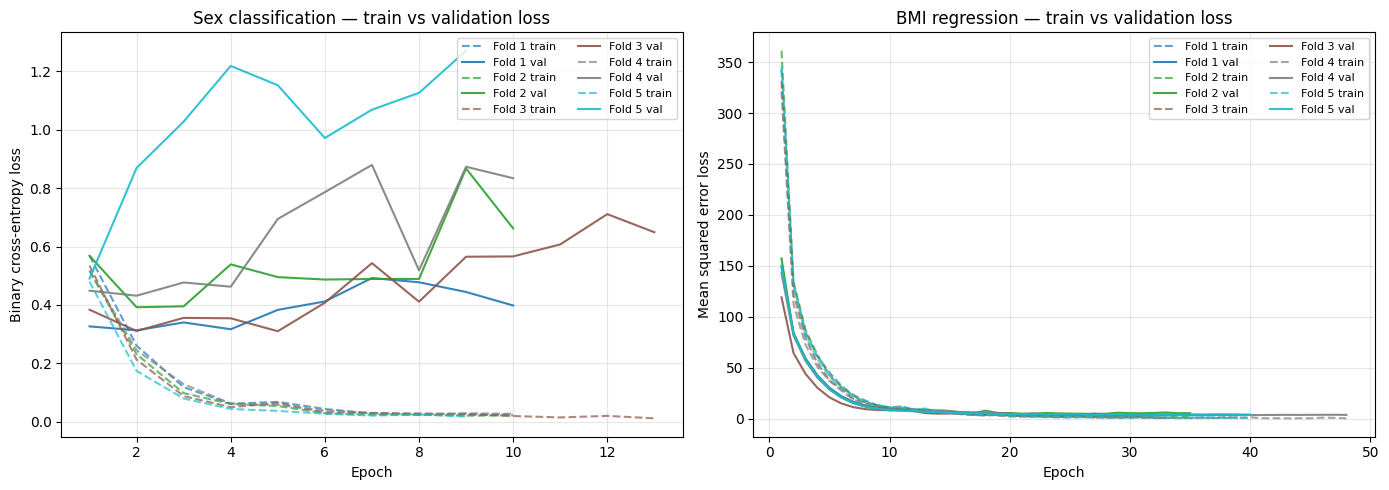

In [ ]:
# Plot training vs validation loss curves across folds, for sex and BMI
# Load from JSON so this cell is independent of the training cells
with open('sex_loss_history.json') as f:
    sex_hist = json.load(f)
with open('bmi_loss_history.json') as f:
    bmi_hist = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sex panel
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, n_folds))
for fold_idx in range(n_folds):
    epochs = np.arange(1, len(sex_hist['train_losses_per_fold'][fold_idx]) + 1)
    ax.plot(epochs, sex_hist['train_losses_per_fold'][fold_idx],
            linestyle='--', color=colors[fold_idx], alpha=0.7,
            label=f'Fold {fold_idx+1} train')
    ax.plot(epochs, sex_hist['val_losses_per_fold'][fold_idx],
            linestyle='-',  color=colors[fold_idx], alpha=0.9,
            label=f'Fold {fold_idx+1} val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary cross-entropy loss')
ax.set_title('Sex classification — train vs validation loss')
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(alpha=0.3)

# BMI panel
ax = axes[1]
for fold_idx in range(n_folds):
    epochs = np.arange(1, len(bmi_hist['train_losses_per_fold'][fold_idx]) + 1)
    ax.plot(epochs, bmi_hist['train_losses_per_fold'][fold_idx],
            linestyle='--', color=colors[fold_idx], alpha=0.7,
            label=f'Fold {fold_idx+1} train')
    ax.plot(epochs, bmi_hist['val_losses_per_fold'][fold_idx],
            linestyle='-',  color=colors[fold_idx], alpha=0.9,
            label=f'Fold {fold_idx+1} val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean squared error loss')
ax.set_title('BMI regression — train vs validation loss')
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('section6_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Two patterns are worth drawing out. In the **sex panel**, training loss falls rapidly toward zero within the first few epochs while validation loss bottoms out early and then rises — the model reaches its best generalisation point quickly and begins to overfit thereafter, which is precisely the behaviour the early-stopping mechanism (patience 8) is designed to catch. The selective freezing keeps this overfitting bounded: because only the final ConvNeXt stage and the classifier head are trainable, the model cannot drive validation loss arbitrarily high the way the fully-fine-tuned ResNet-18 of experiment 5.9 did. In the **BMI panel**, both training and validation Mean Squared Error (MSE) decline more gradually over a longer horizon, and the train/validation gap is narrower — consistent with regression being a harder optimisation target that the model fits more slowly and less completely. The per-fold spread is modest in both panels, indicating the result does not hinge on a single fortunate split.


### 6.4 - Out-of-Fold prediction generation

All subsequent evaluation uses **Out-of-Fold (OOF) predictions**: for each training image, the prediction is taken from the fold model in whose validation split that image fell. Because no fold model ever trains on its own validation images, the OOF predictions form an honest, leakage-free in-sample evaluation — the closest proxy to test-set behaviour that the labelled training data can provide. The OOF predictions feed the classification metrics (6.5), the regression metrics (6.6), the Grad-CAM image selection (6.7), and the fairness analysis (6.8).


In [ ]:
# Sex OOF predictions — one probability per training image
sex_oof_probs = np.zeros(len(df), dtype=np.float32)

for fold_idx, (_, valid_ixs) in enumerate(fold_splits_sex):
    model = ConvNeXtTinySex().to(device)
    checkpoint = torch.load(f'best_sex_convnext_fold{fold_idx}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    valid_loader = DataLoader(Subset(ds_sex, valid_ixs), batch_size=2*bs, shuffle=False)
    fold_probs = []
    with torch.no_grad():
        for images, _ in valid_loader:
            images = images.to(device)
            outputs = model(images)
            fold_probs.extend(outputs.cpu().numpy().flatten().tolist())
    sex_oof_probs[valid_ixs] = fold_probs
    print(f"Fold {fold_idx+1} sex OOF predictions: {len(fold_probs)} images")

sex_true = df['sex'].astype(int).values
sex_oof_preds = (sex_oof_probs > 0.5).astype(int)
print(f"\nOverall sex OOF AUC: {roc_auc_score(sex_true, sex_oof_probs):.4f}")
print(f"Overall sex OOF accuracy (threshold 0.5): {accuracy_score(sex_true, sex_oof_preds):.4f}")

Fold 1 sex OOF predictions: 200 images
Fold 2 sex OOF predictions: 200 images
Fold 3 sex OOF predictions: 200 images
Fold 4 sex OOF predictions: 200 images
Fold 5 sex OOF predictions: 200 images

Overall sex OOF AUC: 0.9163
Overall sex OOF accuracy (threshold 0.5): 0.8180


In [ ]:
# BMI OOF predictions — one continuous prediction per training image (BMI-filtered subset only)
bmi_oof_preds = np.zeros(len(df_bmi), dtype=np.float32)

for fold_idx, (_, valid_ixs) in enumerate(fold_splits_bmi):
    model_bmi = ConvNeXtTinyBMI().to(device)
    checkpoint = torch.load(f'best_bmi_convnext_fold{fold_idx}.pth')
    model_bmi.load_state_dict(checkpoint['model_state_dict'])
    model_bmi.eval()
    valid_loader = DataLoader(Subset(ds_bmi, valid_ixs), batch_size=2*bs, shuffle=False)
    fold_preds = []
    with torch.no_grad():
        for images, _ in valid_loader:
            images = images.to(device)
            outputs = model_bmi(images)
            fold_preds.extend(outputs.cpu().numpy().flatten().tolist())
    bmi_oof_preds[valid_ixs] = fold_preds
    print(f"Fold {fold_idx+1} BMI OOF predictions: {len(fold_preds)} images")

bmi_true = df_bmi['bmi'].astype(np.float32).values
print(f"\nOverall BMI OOF RMSE: {math.sqrt(mean_squared_error(bmi_true, bmi_oof_preds)):.4f}")
print(f"Overall BMI OOF MAE:  {mean_absolute_error(bmi_true, bmi_oof_preds):.4f}")

Fold 1 BMI OOF predictions: 200 images
Fold 2 BMI OOF predictions: 200 images
Fold 3 BMI OOF predictions: 190 images
Fold 4 BMI OOF predictions: 190 images
Fold 5 BMI OOF predictions: 190 images

Overall BMI OOF RMSE: 1.9360
Overall BMI OOF MAE:  1.4878


### 6.5 - Sex classification metrics

Confusion matrix, per-class classification report, and Receiver Operating Characteristic (ROC) curve, computed on the OOF sex predictions at a decision threshold of 0.5.


In [ ]:
# Confusion matrix + classification metrics
cm = confusion_matrix(sex_true, sex_oof_preds)
print("Confusion matrix (rows = true label, columns = predicted label):")
print(f"               Predicted 0  Predicted 1")
print(f"  True 0           {cm[0,0]:>5d}        {cm[0,1]:>5d}")
print(f"  True 1           {cm[1,0]:>5d}        {cm[1,1]:>5d}")
print()
print("Classification report:")
print(classification_report(sex_true, sex_oof_preds, target_names=['Female (0)', 'Male (1)'], digits=4))

# Headline scalar metrics
print(f"Accuracy:   {accuracy_score(sex_true, sex_oof_preds):.4f}")
print(f"Precision:  {precision_score(sex_true, sex_oof_preds):.4f}")
print(f"Recall:     {recall_score(sex_true, sex_oof_preds):.4f}")
print(f"F1-score:   {f1_score(sex_true, sex_oof_preds):.4f}")
print(f"AUROC:      {roc_auc_score(sex_true, sex_oof_probs):.4f}")

Confusion matrix (rows = true label, columns = predicted label):
               Predicted 0  Predicted 1
  True 0             551           59
  True 1             123          267

Classification report:
              precision    recall  f1-score   support

  Female (0)     0.8175    0.9033    0.8583       610
    Male (1)     0.8190    0.6846    0.7458       390

    accuracy                         0.8180      1000
   macro avg     0.8183    0.7939    0.8020      1000
weighted avg     0.8181    0.8180    0.8144      1000

Accuracy:   0.8180
Precision:  0.8190
Recall:     0.6846
F1-score:   0.7458
AUROC:      0.9163


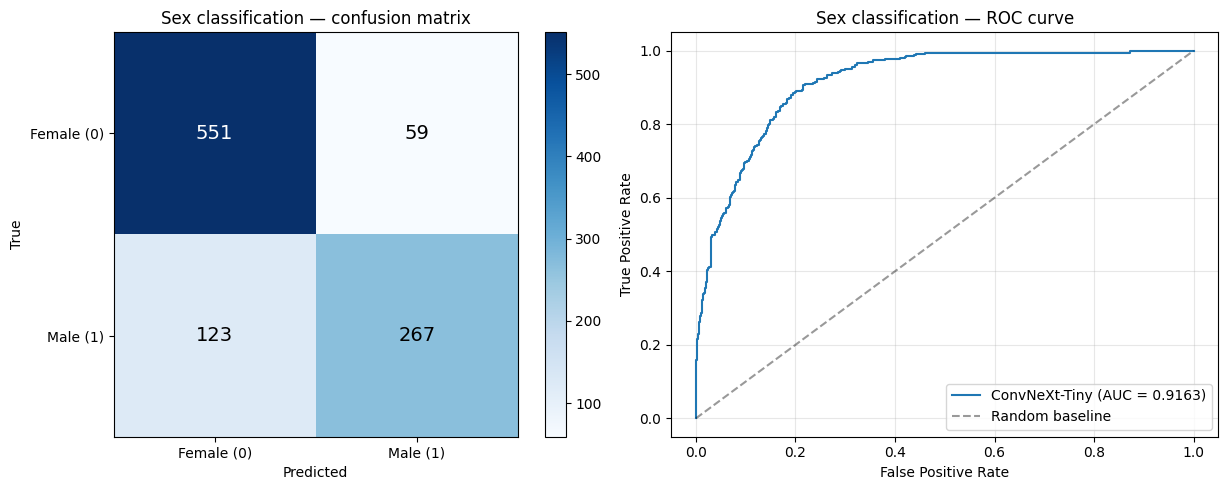

In [ ]:
# Confusion matrix heatmap + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Female (0)', 'Male (1)'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Female (0)', 'Male (1)'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Sex classification — confusion matrix')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f'{cm[i,j]}', ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1]
fpr, tpr, _ = roc_curve(sex_true, sex_oof_probs)
ax.plot(fpr, tpr, label=f'ConvNeXt-Tiny (AUC = {roc_auc_score(sex_true, sex_oof_probs):.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Sex classification — ROC curve')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('section6_sex_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

The headline figures are an OOF accuracy of 0.8180 and an AUROC of 0.9163. The high AUROC against the more moderate accuracy reflects the fact that AUROC measures ranking quality across all thresholds, whereas accuracy is fixed at the 0.5 cut-point; the model ranks images well even where the 0.5 threshold is not optimal.

The more important observation is in the **per-class breakdown**, which reveals a pronounced recall asymmetry. The model correctly identifies 90.3% of female subjects (recall 0.9033) but only 68.5% of male subjects (recall 0.6846), while precision is near-identical for the two classes (0.8175 female, 0.8190 male). In confusion-matrix terms, the model misclassifies 123 of 390 male subjects as female but only 59 of 610 female subjects as male. The model has, in effect, a **bias toward predicting "female"**: when uncertain, it defaults to the majority class (females make up 610 of the 1,000 training images). This asymmetry is the central fairness concern carried into 6.8, where it is examined alongside the BMI-tier breakdown.


### 6.6 - BMI regression metrics

Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and the coefficient of determination (R²), computed on OOF BMI predictions, followed by a predicted-versus-actual scatter plot.


In [ ]:
# BMI metrics
bmi_rmse = math.sqrt(mean_squared_error(bmi_true, bmi_oof_preds))
bmi_mae = mean_absolute_error(bmi_true, bmi_oof_preds)
bmi_r2 = r2_score(bmi_true, bmi_oof_preds)
bmi_std = float(np.std(bmi_true))

print(f"BMI OOF metrics on the {len(bmi_true)} BMI-filtered training images:")
print(f"  RMSE: {bmi_rmse:.4f}")
print(f"  MAE:  {bmi_mae:.4f}")
print(f"  R²:   {bmi_r2:.4f}")
print(f"  Reference — BMI std on this subset: {bmi_std:.4f}")
print(f"  Normalised RMSE (RMSE / std): {bmi_rmse / bmi_std:.4f}")

BMI OOF metrics on the 970 BMI-filtered training images:
  RMSE: 1.9360
  MAE:  1.4878
  R²:   0.5325
  Reference — BMI std on this subset: 2.8314
  Normalised RMSE (RMSE / std): 0.6838


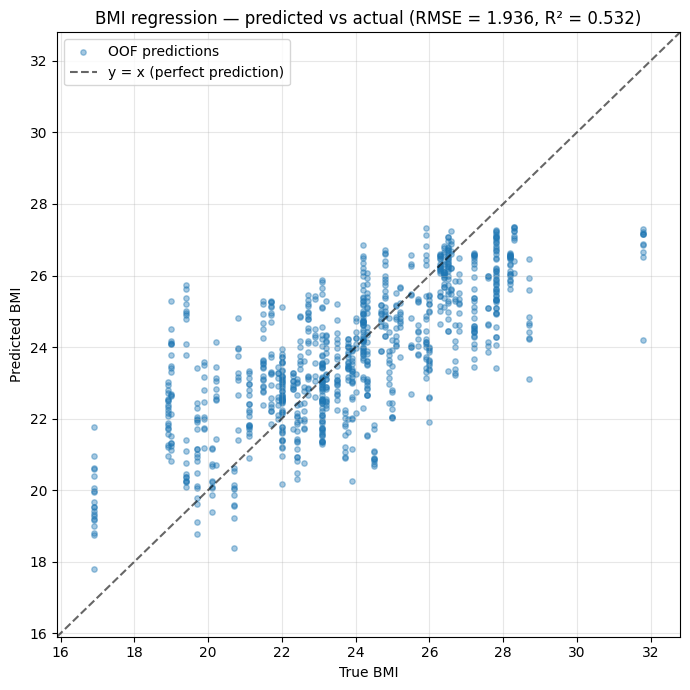

In [ ]:
# Predicted-vs-actual scatter plot for BMI
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(bmi_true, bmi_oof_preds, alpha=0.4, s=15, label='OOF predictions')
mn = min(bmi_true.min(), bmi_oof_preds.min()) - 1
mx = max(bmi_true.max(), bmi_oof_preds.max()) + 1
ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.6, label='y = x (perfect prediction)')
ax.set_xlim(mn, mx); ax.set_ylim(mn, mx)
ax.set_xlabel('True BMI')
ax.set_ylabel('Predicted BMI')
ax.set_title(f'BMI regression — predicted vs actual (RMSE = {bmi_rmse:.3f}, R² = {bmi_r2:.3f})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('section6_bmi_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

The model achieves an OOF RMSE of 1.94 BMI units and an MAE of 1.49, against a BMI standard deviation of 2.83 on the filtered subset — a normalised RMSE of 0.68 and an R² of 0.53, meaning the model explains roughly half the variance in BMI from the X-ray image alone. For a single-channel anatomical image with no explicit height or weight information, recovering BMI to within about 1.5 units on average is a respectable result.

The **predicted-versus-actual scatter** exposes the model's main systematic weakness: the points are visibly compressed toward the centre of the BMI range relative to the y = x line. The model under-predicts high BMI values and over-predicts low ones — the classic **regression-to-the-mean** signature of a model trained with MSE loss on a limited dataset, which is penalised less for hedging toward the population mean than for committing to extreme predictions that might be wrong. This compression is the regression-side counterpart to the classification-side majority-class bias seen in 6.5, and it has a fairness dimension that 6.8 makes explicit.


### 6.7 - Grad-CAM explainability

To probe *where* the model looks when making its predictions, Gradient-weighted Class Activation Mapping (Grad-CAM) is applied to six validation images: the two worst sex misclassifications, the two worst BMI predictions, and one well-predicted image from each task as a sanity check. For each image, the heatmap is computed independently on all five fold models and averaged, matching the way the Kaggle predictions are formed. The target layer is the final block of ConvNeXt-Tiny's last stage (`features[7][-1]`), the deepest trainable layer.


In [ ]:
# Compute per-image losses for OOF predictions, then select 6 images

# Per-image sex binary cross-entropy loss (using OOF probabilities)
eps = 1e-7
sex_oof_loss = -(sex_true * np.log(sex_oof_probs.clip(eps, 1-eps))
                 + (1 - sex_true) * np.log((1 - sex_oof_probs).clip(eps, 1-eps)))

# Per-image BMI absolute error (using OOF predictions)
bmi_oof_abs_err = np.abs(bmi_true - bmi_oof_preds)

# 2 sex misclassifications: images where (oof_pred != true) and loss is highest
sex_misclassified_mask = sex_oof_preds != sex_true
sex_misclassified_idx = np.where(sex_misclassified_mask)[0]
worst_sex_idx = sex_misclassified_idx[np.argsort(-sex_oof_loss[sex_misclassified_idx])[:2]]

# 2 BMI worst predictions: images with the largest absolute error
worst_bmi_idx = np.argsort(-bmi_oof_abs_err)[:2]

# 1 sex sanity check: correctly classified, high-confidence (closest to 1 for true=1, closest to 0 for true=0)
sex_correct_mask = sex_oof_preds == sex_true
sex_confidence = np.where(sex_true == 1, sex_oof_probs, 1 - sex_oof_probs)
sex_correct_idx = np.where(sex_correct_mask)[0]
best_sex_idx = sex_correct_idx[np.argmax(sex_confidence[sex_correct_idx])]

# 1 BMI sanity check: smallest absolute error
best_bmi_idx = int(np.argmin(bmi_oof_abs_err))

# Build a unified record of the 6 selected images
selected = [
    # (image filename, df index, category label, info string for display)
    *[(df.iloc[i]['filename'], i, 'sex misclassification',
       f"true={int(sex_true[i])}, pred_prob={sex_oof_probs[i]:.3f}, loss={sex_oof_loss[i]:.3f}")
      for i in worst_sex_idx],
    *[(df_bmi.iloc[i]['filename'], i, 'BMI worst prediction',
       f"true_BMI={bmi_true[i]:.1f}, pred_BMI={bmi_oof_preds[i]:.1f}, |err|={bmi_oof_abs_err[i]:.1f}")
      for i in worst_bmi_idx],
    (df.iloc[best_sex_idx]['filename'], best_sex_idx, 'sex sanity check',
     f"true={int(sex_true[best_sex_idx])}, pred_prob={sex_oof_probs[best_sex_idx]:.3f}, "
     f"loss={sex_oof_loss[best_sex_idx]:.3f}"),
    (df_bmi.iloc[best_bmi_idx]['filename'], best_bmi_idx, 'BMI sanity check',
     f"true_BMI={bmi_true[best_bmi_idx]:.1f}, pred_BMI={bmi_oof_preds[best_bmi_idx]:.1f}, "
     f"|err|={bmi_oof_abs_err[best_bmi_idx]:.1f}"),
]

for fname, idx, cat, info in selected:
    print(f"[{cat}]  {fname}  —  {info}")

[sex misclassification]  7824_3065.jpg  —  true=1, pred_prob=0.002, loss=6.091
[sex misclassification]  7824_4335.jpg  —  true=1, pred_prob=0.002, loss=6.051
[BMI worst prediction]  2962_3824.jpg  —  true_BMI=31.8, pred_BMI=24.2, |err|=7.6
[BMI worst prediction]  7824_6083.jpg  —  true_BMI=19.4, pred_BMI=25.7, |err|=6.3
[sex sanity check]  1766_8392.jpg  —  true=0, pred_prob=0.000, loss=0.000
[BMI sanity check]  8780_6791.jpg  —  true_BMI=24.2, pred_BMI=24.2, |err|=0.0


In [ ]:
# Define target functions for pytorch-grad-cam
# For sex: scalar probability output; we want gradient wrt the output itself
class ScalarOutputTarget:
    def __call__(self, model_output):
        return model_output.squeeze()

def grad_cam_average(image_tensor, model_class, checkpoint_prefix):
    """Compute Grad-CAM for an image across all 5 fold models, return the averaged heatmap."""
    cams = []
    for fold_idx in range(n_folds):
        model = model_class().to(device)
        checkpoint = torch.load(f'{checkpoint_prefix}{fold_idx}.pth')
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        target_layers = [model.backbone.features[7][-1]]
        cam_extractor = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam_extractor(
            input_tensor=image_tensor,
            targets=[ScalarOutputTarget()],
        )
        cams.append(grayscale_cam[0])
        del cam_extractor, model
    return np.mean(cams, axis=0)

def load_image_for_cam(filename):
    """Load image and prepare both the display version (RGB float in [0,1]) and the model-input
    tensor (normalised, batched, on device)."""
    img_path = f'/content/resized_224/train_images/{filename}'
    pil_img = Image.open(img_path).convert('RGB')
    img_rgb = np.array(pil_img).astype(np.float32) / 255.0   # for display (H, W, 3) in [0,1]
    img_tensor = transforms(pil_img).unsqueeze(0).to(device)
    return img_rgb, img_tensor

print("Grad-CAM helper functions defined.")

Grad-CAM helper functions defined.


In [ ]:
# Generate Grad-CAM heatmaps for each of the 6 selected images.
# - Sex category images: use ConvNeXtTinySex (Grad-CAM shows what drove the sex prediction).
# - BMI category images: use ConvNeXtTinyBMI (Grad-CAM shows what drove the BMI prediction).

grad_cam_results = []
for fname, idx, cat, info in selected:
    print(f"Computing Grad-CAM for {fname} ({cat})...")
    img_rgb, img_tensor = load_image_for_cam(fname)
    if 'sex' in cat:
        model_class = ConvNeXtTinySex
        prefix = 'best_sex_convnext_fold'
    else:
        model_class = ConvNeXtTinyBMI
        prefix = 'best_bmi_convnext_fold'
    heatmap = grad_cam_average(img_tensor, model_class, prefix)
    overlay = show_cam_on_image(img_rgb, heatmap, use_rgb=True)
    grad_cam_results.append((img_rgb, heatmap, overlay, cat, info))

print(f"\nGenerated {len(grad_cam_results)} Grad-CAM visualisations.")

Computing Grad-CAM for 7824_3065.jpg (sex misclassification)...
Computing Grad-CAM for 7824_4335.jpg (sex misclassification)...
Computing Grad-CAM for 2962_3824.jpg (BMI worst prediction)...
Computing Grad-CAM for 7824_6083.jpg (BMI worst prediction)...
Computing Grad-CAM for 1766_8392.jpg (sex sanity check)...
Computing Grad-CAM for 8780_6791.jpg (BMI sanity check)...

Generated 6 Grad-CAM visualisations.


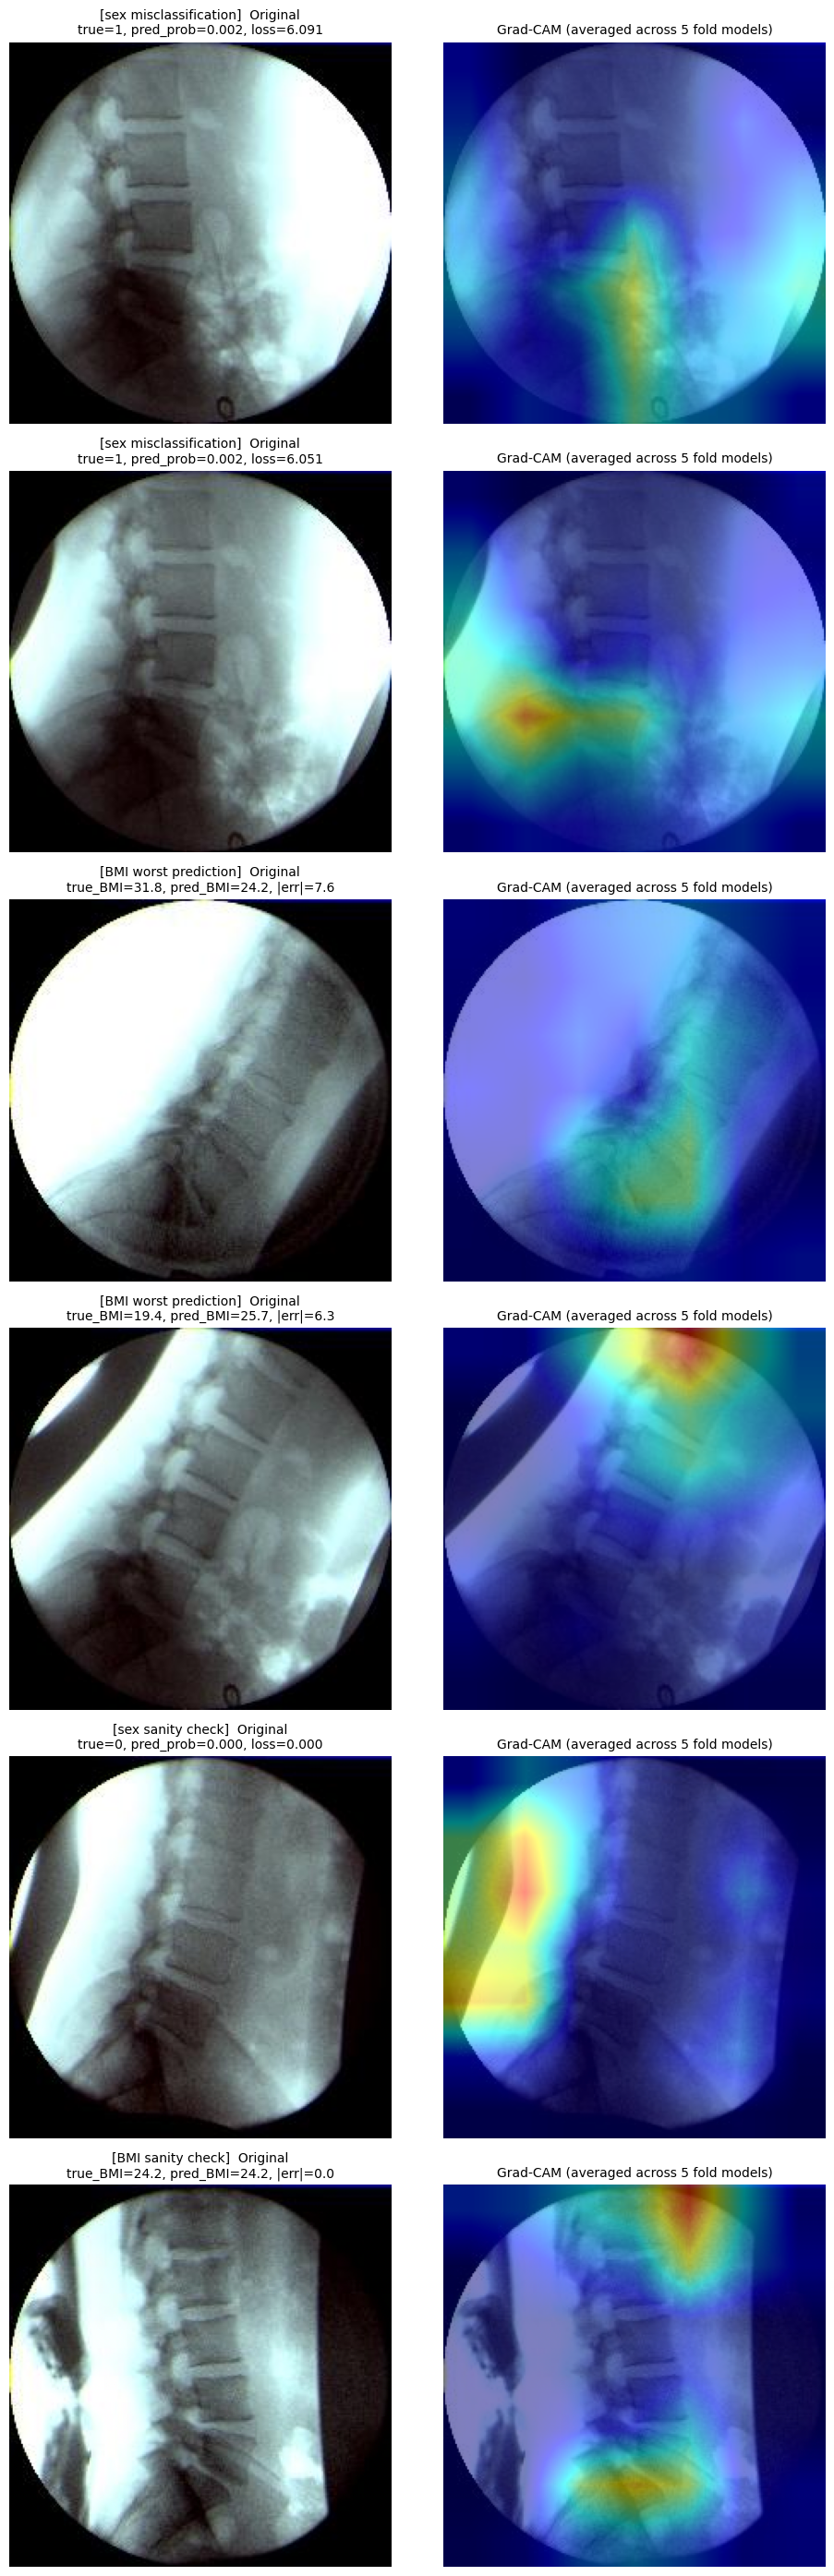

In [ ]:
# Display the 6 selected images in a 3-row × 2-column grid (original + Grad-CAM overlay)
fig, axes = plt.subplots(6, 2, figsize=(10, 28))

for row, (img_rgb, heatmap, overlay, cat, info) in enumerate(grad_cam_results):
    ax_orig = axes[row, 0]
    ax_orig.imshow(img_rgb)
    ax_orig.set_title(f'[{cat}]  Original\n{info}', fontsize=10)
    ax_orig.axis('off')

    ax_cam = axes[row, 1]
    ax_cam.imshow(overlay)
    ax_cam.set_title('Grad-CAM (averaged across 5 fold models)', fontsize=10)
    ax_cam.axis('off')

plt.tight_layout()
plt.savefig('section6_gradcam.png', dpi=120, bbox_inches='tight')
plt.show()

The Grad-CAM overlays are reassuring in the sanity-check cases: for the correctly-classified, high-confidence sex image and the accurately-predicted BMI image, the model's attention concentrates on anatomically plausible regions of the lower back and torso rather than on image borders, or scanner artefacts — evidence that the predictions are driven by genuine anatomical signal rather than dataset shortcuts.

The failure cases are more instructive. Both of the worst sex misclassifications come from the same patient (identifier 7824), as does one of the two worst BMI errors — a strong indication that this patient's X-rays are atypical in a way that affects both tasks simultaneously, rather than the failures being independent. For these images the model predicts the wrong class with very high confidence (predicted probability 0.002 against a true label of 1), and the Grad-CAM heatmaps for these cases attend to regions that do not correspond to the discriminative pelvic and thoracic structures the sanity-check cases rely on. This is consistent with the model encountering an out-of-distribution presentation it cannot interpret correctly — the same vulnerability, in microcosm, that the regression-to-the-mean behaviour in 6.6 expresses across the whole BMI range.


### 6.8 - Fairness analysis

Aggregate metrics can conceal systematic differences in how a model treats patient subgroups. Two breakdowns are examined: BMI prediction performance segmented by sex (6.8.1), and sex classification performance segmented by BMI tier (6.8.2). Together they reveal that both of the model's headline weaknesses — the female-prediction bias of 6.5 and the regression-to-the-mean of 6.6 — fall unevenly across subgroups.


#### 6.8.1 - BMI prediction performance by sex


In [ ]:
# BMI prediction metrics broken down by true sex
sex_in_bmi = df_bmi['sex'].astype(int).values   # sex labels aligned to bmi_oof_preds

rows = []
for sex_value, sex_label in [(0, 'Female'), (1, 'Male')]:
    mask = sex_in_bmi == sex_value
    n = int(mask.sum())
    rmse = math.sqrt(mean_squared_error(bmi_true[mask], bmi_oof_preds[mask]))
    mae = mean_absolute_error(bmi_true[mask], bmi_oof_preds[mask])
    bias = float(np.mean(bmi_oof_preds[mask] - bmi_true[mask]))   # positive = over-prediction
    rows.append({'Group': sex_label, 'n': n, 'RMSE': rmse, 'MAE': mae, 'Bias (pred − true)': bias})

fairness_bmi_df = pd.DataFrame(rows)
print("BMI prediction performance by sex:")
print(fairness_bmi_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

BMI prediction performance by sex:
 Group   n   RMSE    MAE  Bias (pred − true)
Female 590 1.8623 1.4087             -0.4318
  Male 380 2.0452 1.6106              0.5946


The breakdown shows a clear **directional bias that differs by sex**. For female subjects the model under-predicts BMI on average (bias −0.43), while for male subjects it over-predicts (bias +0.59); prediction error is also somewhat higher for males (RMSE 2.05 versus 1.86, MAE 1.61 versus 1.41). The two biases point in opposite directions and are of similar magnitude, so they roughly cancel in the aggregate metrics of 6.6 — which is precisely why a subgroup view is necessary to see them. A sex-dependent offset of around one BMI unit separates the two groups: a prediction of, say, 25 means something slightly different depending on whether the subject is male or female. The practical implication is that the model's BMI outputs are not equally calibrated across sexes, and any downstream use would need to correct for this offset rather than treating a single predicted value as sex-neutral. Establishing the precise mechanism behind the directional split would require analysing the joint distribution of sex and BMI in the training data, which is taken up in Section 7's critical reflection.


#### 6.8.2 - Sex classification performance by BMI tier

Performance is segmented into three clinically-defined Body Mass Index bands: underweight (BMI < 18.5), normal (18.5 ≤ BMI < 25), and overweight (BMI ≥ 25).


Sex classification performance by BMI tier:
   BMI tier   n  Accuracy  Precision  Recall     F1  AUROC
Underweight  20    0.8500        NaN     NaN    NaN    NaN
     Normal 620    0.8032     0.8808  0.7156 0.7897 0.9289
 Overweight 330    0.8273     0.2821  0.2750 0.2785 0.7802


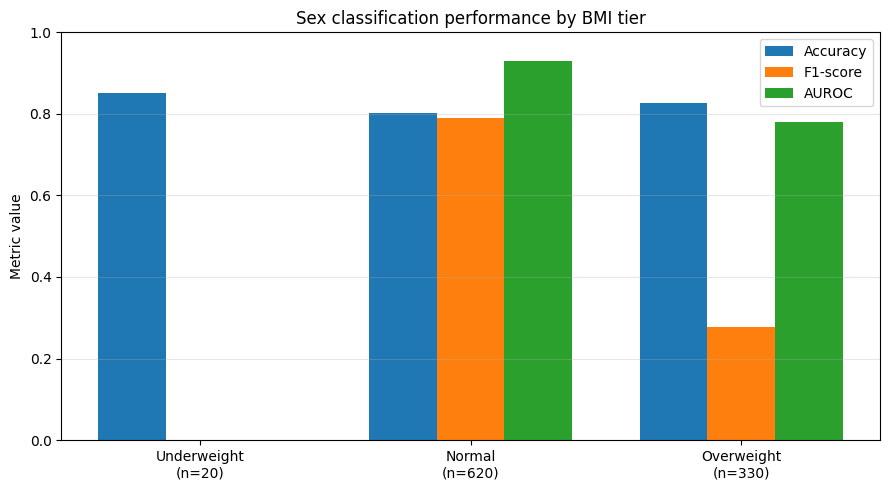

In [ ]:
# Sex classification metrics broken down by BMI tier (BMI-filtered subset only)
# Subset sex predictions to images with valid BMI labels
bmi_filtered_filenames = set(df_bmi['filename'])
sex_subset_mask = df['filename'].isin(bmi_filtered_filenames).values
sex_true_subset = sex_true[sex_subset_mask]
sex_oof_probs_subset = sex_oof_probs[sex_subset_mask]
sex_oof_preds_subset = sex_oof_preds[sex_subset_mask]
# Align BMI tier labels to the same ordering
df_subset = df[sex_subset_mask].reset_index(drop=True)
bmi_lookup = df_bmi.set_index('filename')['bmi'].to_dict()
bmi_aligned = df_subset['filename'].map(bmi_lookup).values

def bmi_tier(bmi):
    if bmi < 18.5: return 'Underweight'
    if bmi < 25:   return 'Normal'
    return 'Overweight'

tiers = np.array([bmi_tier(b) for b in bmi_aligned])

rows = []
for tier in ['Underweight', 'Normal', 'Overweight']:
    mask = tiers == tier
    n = int(mask.sum())
    if n == 0:
        rows.append({'BMI tier': tier, 'n': 0, 'Accuracy': float('nan'),
                     'Precision': float('nan'), 'Recall': float('nan'),
                     'F1': float('nan'), 'AUROC': float('nan')})
        continue
    acc = accuracy_score(sex_true_subset[mask], sex_oof_preds_subset[mask])
    # If only one class is present in this tier, sklearn warns; we handle that here
    if len(set(sex_true_subset[mask])) > 1:
        prec = precision_score(sex_true_subset[mask], sex_oof_preds_subset[mask], zero_division=0)
        rec  = recall_score(sex_true_subset[mask], sex_oof_preds_subset[mask], zero_division=0)
        f1   = f1_score(sex_true_subset[mask], sex_oof_preds_subset[mask], zero_division=0)
        auc  = roc_auc_score(sex_true_subset[mask], sex_oof_probs_subset[mask])
    else:
        prec = rec = f1 = auc = float('nan')
    rows.append({'BMI tier': tier, 'n': n, 'Accuracy': acc,
                 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUROC': auc})

fairness_sex_df = pd.DataFrame(rows)
print("Sex classification performance by BMI tier:")
print(fairness_sex_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(rows))
width = 0.25
ax.bar(x - width, fairness_sex_df['Accuracy'],  width, label='Accuracy')
ax.bar(x,         fairness_sex_df['F1'],        width, label='F1-score')
ax.bar(x + width, fairness_sex_df['AUROC'],     width, label='AUROC')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['BMI tier']}\n(n={r['n']})" for r in rows])
ax.set_ylabel('Metric value')
ax.set_ylim(0, 1)
ax.set_title('Sex classification performance by BMI tier')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('section6_fairness.png', dpi=150, bbox_inches='tight')
plt.show()

**On the underweight tier and the undefined metrics.** The underweight tier contains only 20 images, and all 20 share the same sex label. Precision, recall, F1-score and AUROC are therefore reported as `NaN` — not because of a computational error, but because these four metrics are mathematically undefined when only one class is present in a subgroup. Precision and recall are defined relative to a positive class, so with no examples of one class their denominators collapse; AUROC measures how well a model separates the two classes, which is meaningless when only one is present. Accuracy remains well-defined because it simply counts the fraction of correct predictions regardless of class, and the model scores 0.85 on this tier (17 of 20 correct). The undefined metrics are themselves a fairness finding: the underweight subgroup is too small and class-homogeneous in this dataset to support a full subgroup evaluation, which means we *cannot rule out* subgroup bias here that we lack the data to measure — a limitation worth stating.

**The substantive finding is in the overweight tier.** Although overweight accuracy (0.83) is comparable to the normal tier (0.80), the overweight tier's precision, recall and F1 for the positive class (male) collapse to roughly 0.28, against 0.88 / 0.72 / 0.79 in the normal tier. In other words, within the overweight band the model maintains high overall accuracy while almost entirely failing to correctly identify the minority sex — accuracy is being carried by the majority class while the minority class is systematically missed. This is the female-prediction bias from 6.5 concentrated and amplified in a specific BMI band, and it is the kind of disparity that aggregate accuracy alone would never surface. The combination of the global recall asymmetry (6.5), the sex-dependent BMI calibration (6.8.1) and this overweight-tier collapse establishes that the model's errors are structured along sex and body-composition lines rather than randomly distributed — the central conclusion of the fairness analysis, revisited briefly in Section 7's critical reflection.


### 6.9 - Final submission

The Test-Time Augmentation (TTA) ensemble inference and submission step below regenerates `submission.csv` from the five retrained fold models, confirming the full Section 6 pipeline reproduces the chosen final model's predictions. Submitted to the public Kaggle leaderboard, this produces the project's final composite score of **0.5307**, matching experiment 5.11. The submission upload line is left commented to prevent unintentional uploads.


In [ ]:
# TTA ensemble submission
all_fold_sex_preds = []
for fold_idx in range(n_folds):
    fold_model = ConvNeXtTinySex().to(device)
    checkpoint = torch.load(f'best_sex_convnext_fold{fold_idx}.pth')
    fold_model.load_state_dict(checkpoint['model_state_dict'])
    fold_preds = predict_with_tta(fold_model, test_loader)
    all_fold_sex_preds.append(fold_preds)
    print(f"Fold {fold_idx+1} sex predictions collected (with TTA)")
hold_out_pred = np.mean(all_fold_sex_preds, axis=0)

all_fold_bmi_preds = []
for fold_idx in range(n_folds):
    fold_model_bmi = ConvNeXtTinyBMI().to(device)
    checkpoint = torch.load(f'best_bmi_convnext_fold{fold_idx}.pth')
    fold_model_bmi.load_state_dict(checkpoint['model_state_dict'])
    fold_preds = predict_with_tta(fold_model_bmi, test_loader)
    all_fold_bmi_preds.append(fold_preds)
    print(f"Fold {fold_idx+1} BMI predictions collected (with TTA)")
hold_out_bmi = np.mean(all_fold_bmi_preds, axis=0)

submission_df = pd.DataFrame({
    'filename': test_ds.img_files,
    'sex': hold_out_pred,
    'bmi': hold_out_bmi
})
submission_df.to_csv('submission_convnext_section6.csv', index=False)
print("\nsubmission_convnext_section6.csv created.")
print(submission_df.head())

Fold 1 sex predictions collected (with TTA)
Fold 2 sex predictions collected (with TTA)
Fold 3 sex predictions collected (with TTA)
Fold 4 sex predictions collected (with TTA)
Fold 5 sex predictions collected (with TTA)
Fold 1 BMI predictions collected (with TTA)
Fold 2 BMI predictions collected (with TTA)
Fold 3 BMI predictions collected (with TTA)
Fold 4 BMI predictions collected (with TTA)
Fold 5 BMI predictions collected (with TTA)

submission_convnext_section6.csv created.
        filename       sex        bmi
0  1144_7090.jpg  0.751173  23.086073
1  1148_7947.jpg  0.945822  22.394133
2  1290_2619.jpg  0.508895  23.568010
3  1301_4384.jpg  0.632412  23.626303
4  1334_1570.jpg  0.516636  23.735511


In [ ]:
# Optional — submit to Kaggle. Uncomment to upload; expected score ~0.5307.
# !kaggle competitions submit -c bucv26 -f submission_convnext_section6.csv -m "Section 6 reproduction of 5.11"

## 7. Conclusion and Reflection

This project progressed from a MLP baseline to a selectively-frozen ConvNeXt-Tiny, with the decisive gains coming not from raw model capacity but from methodological corrections: patient-level cross-validation to eliminate data leakage (5.8), and constrained fine-tuning to prevent the overfitting that sank full fine-tuning (5.9). The final model reached a Kaggle composite of 0.5307, predicting sex at 0.92 AUROC, and BMI to within roughly 1.5 units.

A key insight from Section 5.10 was that combining multiple augmentations simultaneously prevents the attribution of performance changes to any individual augmentation. More importantly, it demonstrated that augmentation methods should be selescted based on domain-specific considerations rather than being copied directly from natural-image pipelines. Domain knowledge should guide experimental design from the outset, rather than being applied retrospectively in response to unsatisfactory outcomes.

From the analysis of our final ConvNeXt-Tiny model, we conclude it is not yet ready for deployment. Despite respectable aggregate metrics, the model should not be deployed for clinical or research use in its current state. The fairness analysis (6.8) revealed that errors are structured along sex and body-composition lines — a 22-point male-versus-female recall gap, a sex-dependent BMI calibration offset, and a near-total collapse of minority-class detection in overweight subjects — rather than being randomly distributed.

Before responsible use, the following are necessary: external validation on a larger, multi-site cohort with balanced demographics; subgroup performance thresholds agreed with clinicians; calibration analysis and confidence-aware abstention for low-certainty cases; and prospective testing against existing measurement methods. The 100 patients training base — and just 97 once BMI-implausible cases are filtered — remains far too narrow a demographic foundation to support deployment claims.


## References (APA Style)

Bahram, A. M., Omer, S. M., & Mohammed, H. M. (2026). Comparative analysis of deep learning architectures for multi-disease classification of single-label chest X-rays. *Charmo Journal of Natural Sciences*, *2*(1), Article 2. https://doi.org/10.31530/cjnst.2026.2.1.2

In-text citation: (Bahram et al., 2026)

‎

Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2021). An image is worth 16×16 words: Transformers for image recognition at scale. *International Conference on Learning Representations (ICLR)*. https://openreview.net/forum?id=YicbFdNTTy

In-text citation: (Dosovitskiy et al., 2021)

‎

Goyal, P., Dollár, P., Girshick, R., Noordhuis, P., Wesolowski, L., Kyrola, A., Tulloch, A., Jia, Y. and He, K. (2018). Accurate, Large Minibatch SGD: Training ImageNet in 1 Hour. arXiv:1706.02677 [cs]. [online] Available at: https://arxiv.org/abs/1706.02677.

In-text citation: (Goyal et al., 2018)

‎


He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. In *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition* (pp. 770–778). https://doi.org/10.1109/CVPR.2016.90

In-text citation: (He et al., 2016)

‎

Henry, C. J. K. (2001). The biology of human starvation: some new insights. Nutrition Bulletin, 26(3), 205-211. https://doi.org/10.1046/j.1467-3010.2001.00164.x

In-text citation: (Henry, 2001)

‎

Huang, G., Liu, Z., Van Der Maaten, L., & Weinberger, K. Q. (2017). Densely connected convolutional networks. In *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition* (pp. 4700–4708). https://doi.org/10.1109/CVPR.2017.243

In-text citation: (Huang et al., 2017)

‎

Krizhevsky, A. (2014). One weird trick for parallelizing convolutional neural networks. ArXiv:1404.5997 [Cs]. https://arxiv.org/abs/1404.5997

In-text citation: (Krizhevsky, 2014)

‎

Liu, Z., Mao, H., Wu, C.-Y., Feichtenhofer, C., Darrell, T., & Xie, S. (2022). A ConvNet for the 2020s. In *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition* (pp. 11976–11986). https://doi.org/10.1109/CVPR52688.2022.01167

In-text citation: (Liu et al., 2022)

‎

NHS. (2024). Body measuring techniques :: East Lancashire Hospitals NHS Trust. Elht.nhs.uk. https://elht.nhs.uk/services/dietetics/body-measuring-techniques

In-text citation: (NHS, 2024)

‎

Rajpurkar, P., Irvin, J., Zhu, K., Yang, B., Mehta, H., Duan, T., Ding, D., Bagul, A., Langlotz, C., Shpanskaya, K., Lungren, M. P., & Ng, A. Y. (2017). CheXNet: Radiologist-level pneumonia detection on chest X-rays with deep learning. *arXiv preprint*. https://arxiv.org/abs/1711.05225

In-text citation: (Rajpurkar et al., 2017)

‎

Skerry, R. (2020, July 30). Body mass index may not be the best indicator of our health – how can we improve it? Bristol Biomedical Research Centre. https://www.bristolbrc.nihr.ac.uk/news/body-mass-index-may-not-be-the-best-indicator-of-our-health-how-can-we-improve-it/

In-text citation: (Skerry, 2020)

‎

Tan, M., & Le, Q. V. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. In *Proceedings of the 36th International Conference on Machine Learning, PMLR* (Vol. 97, pp. 6105–6114). https://proceedings.mlr.press/v97/tan19a.html

In-text citation: (Tan & Le, 2019)

‎

Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). Attention is all you need. In *Advances in Neural Information Processing Systems* (Vol. 30). https://papers.nips.cc/paper/2017/hash/3f5ee243547dee91fbd053c1c4a845aa-Abstract.html

In-text citation: (Vaswani et al., 2017)

‎

Wilson, A. C., Roelofs, R., Stern, M., Srebro, N., & Recht, B. (2018). The Marginal Value of Adaptive Gradient Methods in Machine Learning. ArXiv:1705.08292 [Cs, Stat]. https://arxiv.org/abs/1705.08292

In-text citation: (Wilson et al., 2018)
